# Ebolobundi 2026 — Pipeline ML/DL Retravaill
## Transfer Learning · Few-Shot Learning · GNN Spatio-Temporel · XAI Publication-Ready
### Épidémie Ebola Bundibugyo 2026 — République Démocratique du Congo
---
**Pipeline structuré en 9 modules :**
1. `CONFIG` — Constantes & environnement
2. `DATA` — Acquisition, extraction, validation
3. `EDA` — Exploratory Analysis + tests statistiques
4. `TRANSFER` — Transfer Learning depuis épidémies passées
5. `FEATURES` — Feature engineering + scaling
6. `BASELINE` — Modèles classiques (LR, RF, XGB, LGB)
7. `DEEPL` — LSTM + Transformer (PyTorch)
8. `GNN` — Graph Neural Network spatio-temporel
9. `XAI` — SHAP + LIME publication-ready
10. `EVAL` — Métriques unifiées + dashboard figures
11. `REPORT` — Export LaTeX, JSON, rapport complet


## MODULE 0 · Configuration & Environment

In [1]:
# ── Imports ────────────────────────────────────────────────────────────
import os, sys, json, warnings, logging, tarfile, zipfile, hashlib
from pathlib import Path
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, field

import pickle, torch

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

try:
    import geopandas as gpd
    from shapely.geometry import Point
    GEO_AVAILABLE = True
except ImportError:
    GEO_AVAILABLE = False
    print("⚠️  geopandas non disponible — cartes désactivées")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.data import Data as GeoData
from torch_geometric.nn import SAGEConv, GCNConv, GATConv

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import lime
import lime.lime_tabular
from scipy import stats
from scipy.integrate import odeint

try:
    from statsmodels.tsa.stattools import adfuller, acf, pacf
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.stats.diagnostic import acorr_ljungbox
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING)

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")


C:\Users\Hp\anaconda3\envs\Torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python  : 3.12.13
PyTorch : 2.11.0+cpu
Pandas  : 3.0.1
CUDA    : False


In [2]:
# ── Configuration centralisée ──────────────────────────────────────────
@dataclass
class Config:
    # Reproduction
    SEED: int = 42

    # Chemins
    DATA_DIR:    Path = Path("donnees_ebola")
    EXTRACT_DIR: Path = Path("donnees_extraites")
    OUTPUT_DIR:  Path = Path("outputs")
    FIG_DIR:     Path = Path("outputs/figures")
    REPORT_DIR:  Path = Path("outputs/reports")

    # Source GitHub
    GITHUB_REPO:    str = "INRB-UMIE/BDBV2026-Data"
    GITHUB_API_URL: str = "https://api.github.com/repos/INRB-UMIE/BDBV2026-Data/releases"

    # Fichiers épidémio (format long : zone | date | value)
    CSV_MAP: Dict[str, str] = field(default_factory=lambda: {
        "nat_cases":     "long/insp_sitrep__national_cumulative_confirmed_cases.csv",
        "nat_deaths":    "long/insp_sitrep__national_cumulative_confirmed_deaths.csv",
        "nat_recovered": "long/insp_sitrep__national_cumulative_recovered_cases.csv",
        "nat_suspected": "long/insp_sitrep__national_cumulative_suspected_cases.csv",
        "new_cases":     "long/insp_sitrep__new_confirmed_cases.csv",
        "cum_cases":     "long/insp_sitrep__cumulative_confirmed_cases.csv",
        "cum_deaths":    "long/insp_sitrep__cumulative_confirmed_deaths.csv",
        "cum_suspected": "long/insp_sitrep__cumulative_suspected_cases.csv",
    })

    # Few-shot
    N_SHOTS:      int   = 14        # training weeks (few-shot)
    TEST_RATIO:   float = 0.30
    N_CV_FOLDS:   int   = 4
    RISK_PCTILE:  int   = 75

    # Modèles séquentiels
    SEQ_LEN:      int   = 7         # fenêtre temporelle (jours)
    FORECAST_HOR: int   = 30        # horizon de prévision
    N_BOOTSTRAP:  int   = 500

    # GNN
    GNN_HIDDEN:   int   = 64
    GNN_LAYERS:   int   = 2
    GNN_EPOCHS:   int   = 300
    GNN_LR:       float = 1e-3
    GNN_DROPOUT:  float = 0.3

    # DL training
    DL_EPOCHS:    int   = 300
    DL_LR:        float = 1e-3
    DL_PATIENCE:  int   = 30
    DL_BATCH:     int   = 16

    # Épidémies historiques pour Transfer Learning
    HISTORICAL_OUTBREAKS: Dict[str, Dict] = field(default_factory=lambda: {
        "WestAfrica_2014": {
            "peak_week": 40, "total_cases": 28616,
            "R0": 1.71, "cfr": 0.40, "duration_weeks": 104,
            "country": "Guinea/Sierra Leone/Liberia", "strain": "Zaire"
        },
        "DRC_2018_Nord_Kivu": {
            "peak_week": 26, "total_cases": 3481,
            "R0": 1.59, "cfr": 0.67, "duration_weeks": 94,
            "country": "DRC", "strain": "Zaire"
        },
        "DRC_2021_Nord_Kivu": {
            "peak_week": 8, "total_cases": 12,
            "R0": 1.20, "cfr": 0.50, "duration_weeks": 8,
            "country": "DRC", "strain": "Zaire"
        },
        "Uganda_2022": {
            "peak_week": 8, "total_cases": 164,
            "R0": 1.40, "cfr": 0.55, "duration_weeks": 16,
            "country": "Uganda", "strain": "Sudan"
        },
    })

CFG = Config()

# Création des répertoires
for d in [CFG.DATA_DIR, CFG.EXTRACT_DIR, CFG.OUTPUT_DIR, CFG.FIG_DIR, CFG.REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Seeds
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Style publication
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = ["#2C3E50","#E74C3C","#3498DB","#2ECC71","#F39C12","#9B59B6","#1ABC9C","#E67E22"]

print(f"Config initialised | Device: {DEVICE}")
print(f"   Répertoires: {[str(d) for d in [CFG.OUTPUT_DIR, CFG.FIG_DIR, CFG.REPORT_DIR]]}")


Config initialised | Device: cpu
   Répertoires: ['outputs', 'outputs\\figures', 'outputs\\reports']


## MODULE 1 · Data Acquisition & Validation

In [3]:
# ── Utilitaires de chargement ──────────────────────────────────────────
def parse_date(val) -> pd.Timestamp:
    """Parse robuste de date (multi-format)."""
    if pd.isna(val) or str(val).strip() == '':
        return pd.NaT
    s = str(val).strip().replace(']', '').replace('[', '').replace('"', '')
    for fmt in ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%Y', '%Y/%m/%d']:
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    try:
        return pd.to_datetime(s)
    except Exception:
        return pd.NaT


def normalize_long_df(df: pd.DataFrame) -> pd.DataFrame:
    """Normalise un CSV en format long (zone | date | value)."""
    df = df.copy()
    if len(df.columns) == 3:
        df.columns = ['zone', 'date', 'value']
    elif len(df.columns) == 2:
        df.columns = ['date', 'value']
        df.insert(0, 'zone', 'DRC')
    df['zone']  = df['zone'].astype(str).str.strip()
    df['date']  = df['date'].apply(parse_date)
    df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0)
    df = df.dropna(subset=['date'])
    return df.sort_values(['zone', 'date']).reset_index(drop=True)


def validate_dataframe(df: pd.DataFrame, name: str) -> Dict:
    """Retourne un rapport de qualité succinct."""
    report = {
        'name':        name,
        'rows':        len(df),
        'null_pct':    df['value'].isna().mean() * 100,
        'neg_count':   (df['value'] < 0).sum(),
        'n_zones':     df['zone'].nunique(),
        'date_min':    df['date'].min(),
        'date_max':    df['date'].max(),
        'total_cases': df['value'].sum(),
    }
    return report


In [4]:
# ── GitHub download ─────────────────────────────────────────────
def fetch_latest_release(cfg: Config) -> Optional[Dict]:
    """Récupère les métadonnées de la dernière release GitHub."""
    try:
        r = requests.get(cfg.GITHUB_API_URL, timeout=15)
        r.raise_for_status()
        builds = [rel for rel in r.json() if 'build' in rel.get('tag_name', '')]
        if not builds:
            raise ValueError("No release found 'build' trouvée")
        latest = builds[0]
        print(f"✅ Release: {latest['tag_name']}  ({latest['published_at'][:10]})")
        return latest
    except Exception as e:
        print(f"⚠️  GitHub unavailable: {e}")
        return None


def download_assets(release: Dict, cfg: Config) -> List[Path]:
    """Télécharge et extrait les assets d'une release."""
    downloaded = []
    for asset in release.get('assets', []):
        name = asset['name']
        dst  = cfg.DATA_DIR / name
        if dst.exists():
            print(f"   ↩  {name} déjà présent")
        else:
            try:
                r = requests.get(asset['browser_download_url'], timeout=60)
                r.raise_for_status()
                dst.write_bytes(r.content)
                print(f"   ✅ {name}  ({len(r.content)//1024} KB)")
            except Exception as e:
                print(f"   ❌ {name}: {e}")
                continue
        downloaded.append(dst)
        # Extraction auto
        if name.endswith('.tar.gz'):
            with tarfile.open(dst, 'r:gz') as tar:
                tar.extractall(cfg.EXTRACT_DIR)
        elif name.endswith('.zip'):
            with zipfile.ZipFile(dst, 'r') as z:
                z.extractall(cfg.DATA_DIR)
    return downloaded


def load_epidemio_data(cfg: Config) -> Dict[str, pd.DataFrame]:
    """Charge tous les CSV épidémio en format normalisé."""
    base = cfg.EXTRACT_DIR / 'build'
    data = {}
    print("\n── Loading epidemiological data ──────────────────────────")
    for key, relpath in cfg.CSV_MAP.items():
        path = base / relpath
        if not path.exists():
            print(f"   ⚠️  {key}: {relpath} introuvable")
            continue
        try:
            raw = pd.read_csv(path)
            df  = normalize_long_df(raw)
            report = validate_dataframe(df, key)
            data[key] = df
            print(f"   ✅ {key:20s}  {report['rows']:5d} rows  "
                  f"{report['n_zones']:3d} zones  nulls={report['null_pct']:.1f}%  "
                  f"negatives={report['neg_count']}")
        except Exception as e:
            print(f"   ❌ {key}: {e}")
    return data


# ── Execute ──────────────────────────────────────────────────────────
print("=" * 68)
print("DATA ACQUISITION — INRB-UMIE BDBV2026")
print("=" * 68)

release = fetch_latest_release(CFG)
if release:
    download_assets(release, CFG)

DATA = load_epidemio_data(CFG)
print(f"\n→ {len(DATA)} files loaded")


DATA ACQUISITION — INRB-UMIE BDBV2026
✅ Release: build-2026-07-27-a027813  (2026-07-27)
   ✅ build-2026-07-27-a027813.tar.gz  (5118 KB)

── Loading epidemiological data ──────────────────────────
   ✅ nat_cases                62 rows    1 zones  nulls=0.0%  negatives=0
   ✅ nat_deaths               62 rows    1 zones  nulls=0.0%  negatives=0
   ✅ nat_recovered            51 rows    1 zones  nulls=0.0%  negatives=0
   ✅ nat_suspected            61 rows    1 zones  nulls=0.0%  negatives=0
   ✅ new_cases               211 rows   37 zones  nulls=0.0%  negatives=0
   ✅ cum_cases              1863 rows   56 zones  nulls=0.0%  negatives=0
   ✅ cum_deaths             1803 rows   55 zones  nulls=0.0%  negatives=0
   ✅ cum_suspected           188 rows   22 zones  nulls=0.0%  negatives=0

→ 8 files loaded


## MODULE 2 · Exploratory Analysis & Tests Statistiques

In [5]:
# ── Préparation nationale ─────────────────────────────────────────────
def get_national_series(data: Dict, key: str = 'nat_cases') -> Optional[pd.DataFrame]:
    """Extrait la série nationale (DRC) et calcule les dérivées."""
    if key not in data:
        print(f"❌ Clé '{key}' absente")
        return None
    df  = data[key]
    drc = df[df['zone'] == 'DRC'].copy()
    if drc.empty:
        # Agrégation nationale si pas de ligne DRC explicite
        drc = df.groupby('date')['value'].sum().reset_index()
        drc.insert(0, 'zone', 'DRC')
    drc = drc.sort_values('date').reset_index(drop=True)
    drc['new_cases']   = drc['value'].diff().clip(lower=0).fillna(0)
    drc['growth_rate'] = drc['value'].pct_change().fillna(0) * 100
    drc['rolling7']    = drc['new_cases'].rolling(7, min_periods=1).mean()
    return drc


NAT = get_national_series(DATA, 'nat_cases')
if NAT is not None:
    print(f"Period   : {NAT['date'].min().date()} → {NAT['date'].max().date()}")
    print(f"Max cases: {int(NAT['value'].max()):,}")
    print(f"Total cases: {int(NAT['new_cases'].sum()):,}")


Period   : 2026-05-17 → 2026-07-25
Max cases: 3,200
Total cases: 3,187


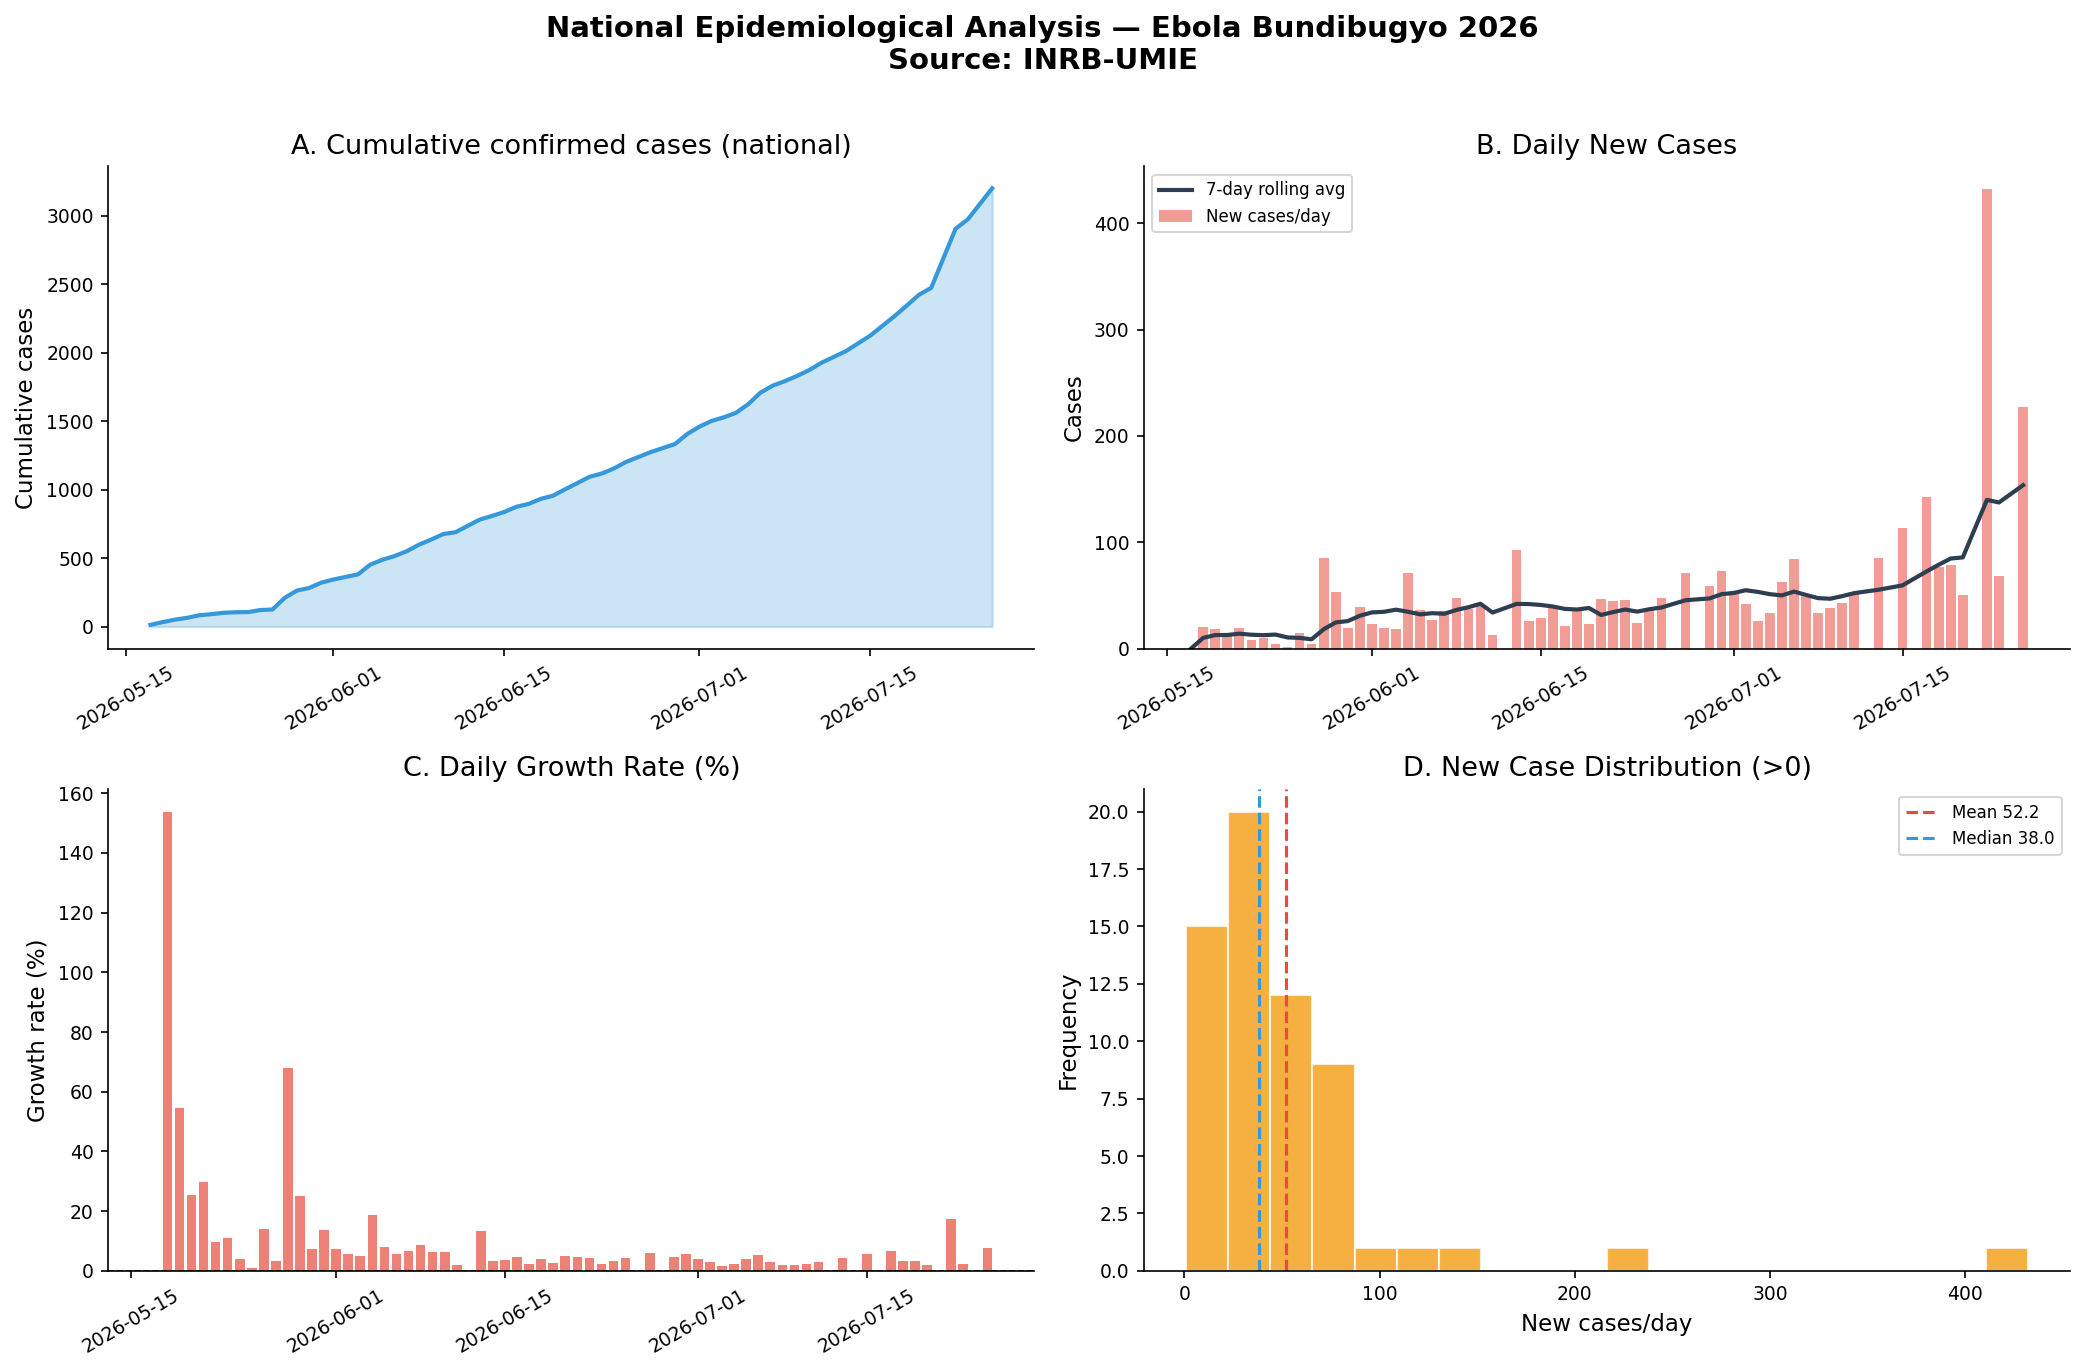

Saved figure: 01_eda_national.png


In [6]:
# ── Visualisation EDA (4 panneaux) ────────────────────────────────────
def plot_eda_national(nat: pd.DataFrame, cfg: Config) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        "National Epidemiological Analysis — Ebola Bundibugyo 2026\nSource: INRB-UMIE",
        fontsize=14, fontweight='bold', y=1.01
    )

    # A — Cumulative cases
    ax = axes[0, 0]
    ax.fill_between(nat['date'], nat['value'], alpha=0.25, color=PALETTE[2])
    ax.plot(nat['date'], nat['value'], color=PALETTE[2], lw=2)
    ax.set_title("A. Cumulative confirmed cases (national)")
    ax.set_ylabel("Cumulative cases")
    ax.tick_params(axis='x', rotation=30)

    # B — New cases + 7-day rolling average
    ax = axes[0, 1]
    ax.bar(nat['date'], nat['new_cases'], alpha=0.55, color=PALETTE[1], label="New cases/day")
    ax.plot(nat['date'], nat['rolling7'], color=PALETTE[0], lw=2, label="7-day rolling avg")
    ax.set_title("B. Daily New Cases")
    ax.set_ylabel("Cases")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

    # C — Growth rate
    ax = axes[1, 0]
    colors = [PALETTE[1] if g > 0 else PALETTE[3] for g in nat['growth_rate']]
    ax.bar(nat['date'], nat['growth_rate'], color=colors, alpha=0.7)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title("C. Daily Growth Rate (%)")
    ax.set_ylabel("Growth rate (%)")
    ax.tick_params(axis='x', rotation=30)

    # D — Distribution of new cases (non nuls)
    ax = axes[1, 1]
    nc_pos = nat['new_cases'][nat['new_cases'] > 0]
    if len(nc_pos):
        ax.hist(nc_pos, bins=min(20, len(nc_pos)), color=PALETTE[4], edgecolor='white', alpha=0.8)
        ax.axvline(nc_pos.mean(),   color=PALETTE[1], ls='--', lw=1.5, label=f"Mean {nc_pos.mean():.1f}")
        ax.axvline(nc_pos.median(), color=PALETTE[2], ls='--', lw=1.5, label=f"Median {nc_pos.median():.1f}")
        ax.legend(fontsize=8)
    ax.set_title("D. New Case Distribution (>0)")
    ax.set_xlabel("New cases/day")
    ax.set_ylabel("Frequency")

    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "01_eda_national.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print(f"Saved figure: 01_eda_national.png")


if NAT is not None:
    plot_eda_national(NAT, CFG)


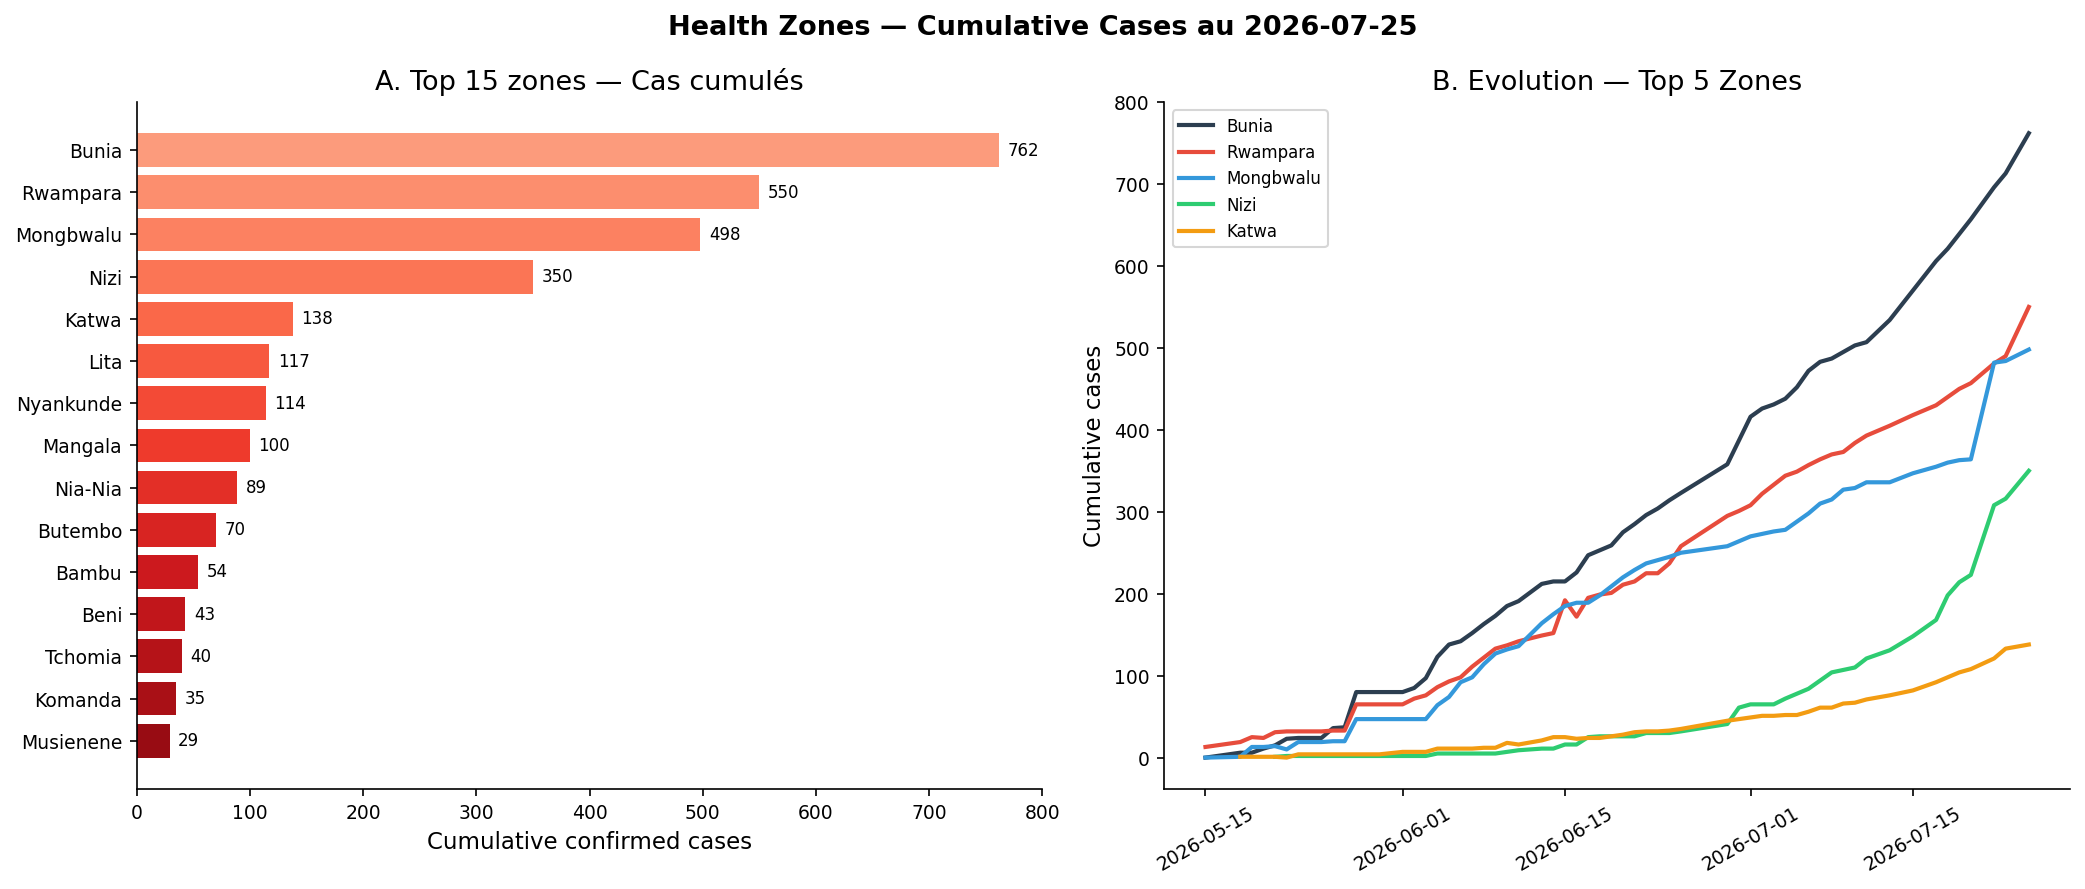

Saved: 02_top_zones.png


In [7]:
# ── Top zones de santé ────────────────────────────────────────────────
def plot_top_zones(data: Dict, cfg: Config, top_n: int = 15) -> Optional[pd.DataFrame]:
    key = 'cum_cases'
    if key not in data:
        print(f"❌ '{key}' absent")
        return None

    df       = data[key]
    last_dt  = df['date'].max()
    df_last  = (
        df[(df['date'] == last_dt) & (df['zone'] != 'DRC') & (df['value'] > 0)]
        .sort_values('value', ascending=False)
        .head(top_n)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Health Zones — Cumulative Cases au {last_dt.date()}",
                 fontsize=13, fontweight='bold')

    # Barh
    ax = axes[0]
    cmap = plt.cm.Reds(np.linspace(0.35, 0.9, len(df_last)))
    bars = ax.barh(df_last['zone'], df_last['value'], color=cmap)
    for bar, val in zip(bars, df_last['value']):
        ax.text(bar.get_width() + df_last['value'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{int(val):,}", va='center', fontsize=8)
    ax.set_xlabel("Cumulative confirmed cases")
    ax.set_title(f"A. Top {top_n} zones — Cas cumulés")
    ax.invert_yaxis()

    # Évolution des 5 premières zones
    ax   = axes[1]
    top5 = df_last['zone'].head(5).tolist()
    df_ev = df[(df['zone'].isin(top5))].copy()
    for i, z in enumerate(top5):
        zd = df_ev[df_ev['zone'] == z].sort_values('date')
        ax.plot(zd['date'], zd['value'], lw=2, label=z, color=PALETTE[i])
    ax.set_title("B. Evolution — Top 5 Zones")
    ax.set_ylabel("Cumulative cases")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "02_top_zones.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: 02_top_zones.png")
    return df_last


ZONE_RANK = plot_top_zones(DATA, CFG)


── Statistical tests ─────────────────────────────────────────────
   ADF: stat=1.1655  p=0.9957  → NON STATIONARY ⚠️
   Ljung-Box: significant lags = [2, 3, 4, 5, 6, 7, 8, 9, 10]
   Shapiro-Wilk: stat=0.5662  p=0.0000


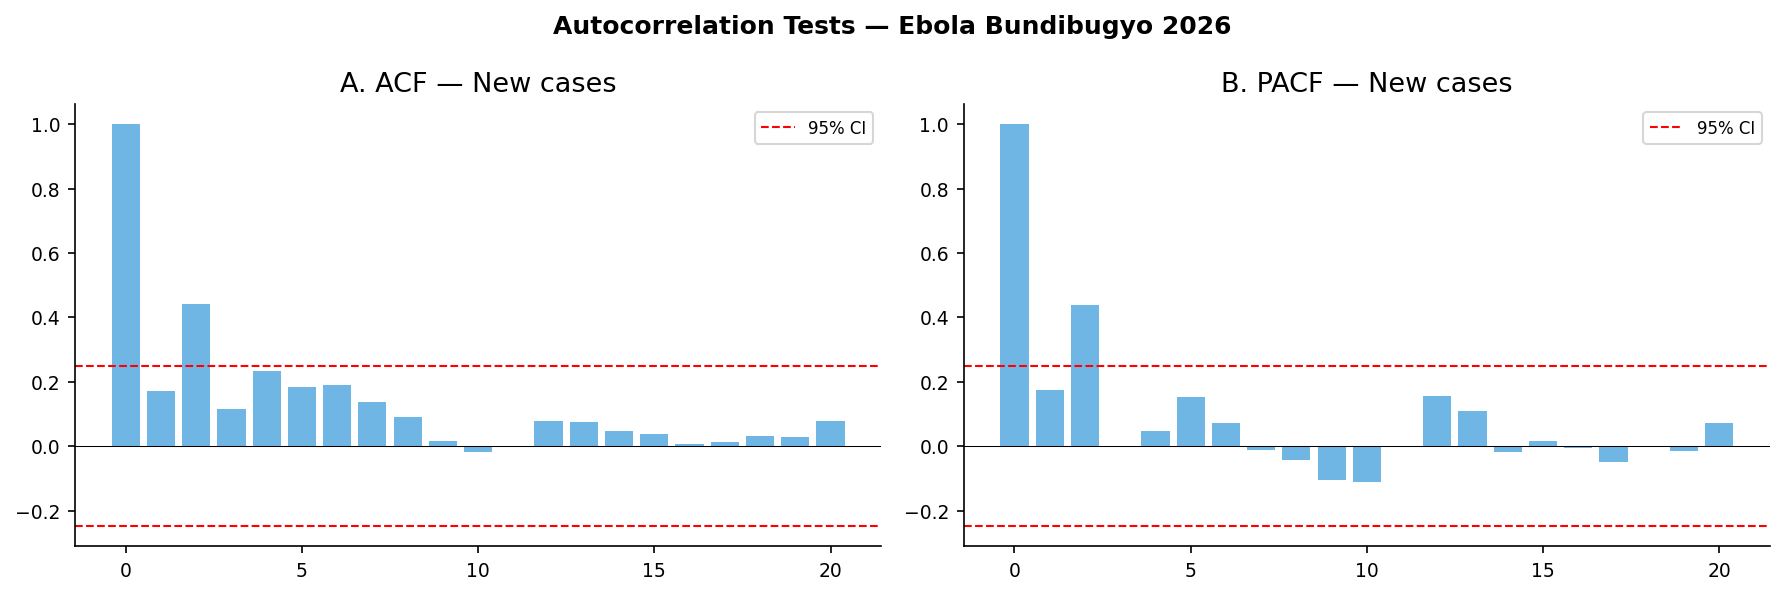

   Saved: 03_acf_pacf.png


In [8]:
# ── Statistical tests ────────────────────────────────────────────────
def run_statistical_tests(nat: pd.DataFrame, cfg: Config) -> Dict:
    """ADF, Ljung-Box, décomposition saisonnière."""
    results = {}
    series  = nat.set_index('date')['new_cases'].fillna(0)

    print("── Statistical tests ─────────────────────────────────────────────")

    if STATSMODELS_OK and len(series) > 10:
        # ADF
        adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
        results['ADF_stat'] = round(adf_stat, 4)
        results['ADF_pval'] = round(adf_p, 4)
        label = "STATIONARY ✅" if adf_p <= 0.05 else "NON STATIONARY ⚠️"
        print(f"   ADF: stat={adf_stat:.4f}  p={adf_p:.4f}  → {label}")

        # Ljung-Box
        lb = acorr_ljungbox(series, lags=10, return_df=True)
        sig_lags = lb[lb['lb_pvalue'] < 0.05].index.tolist()
        results['LjungBox_sig_lags'] = sig_lags
        print(f"   Ljung-Box: significant lags = {sig_lags}")

        # Shapiro-Wilk sur la série
        if len(series) <= 5000:
            sw_stat, sw_p = stats.shapiro(series)
            results['Shapiro_stat'] = round(sw_stat, 4)
            results['Shapiro_pval'] = round(sw_p, 4)
            print(f"   Shapiro-Wilk: stat={sw_stat:.4f}  p={sw_p:.4f}")

        # ACF / PACF plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        n_lags = min(20, len(series) - 1)
        ci     = 1.96 / np.sqrt(len(series))

        for ax, func, title in zip(
            axes,
            [acf, pacf],
            ["A. ACF — New cases", "B. PACF — New cases"]
        ):
            vals = func(series, nlags=n_lags)
            ax.bar(range(len(vals)), vals, color=PALETTE[2], alpha=0.7)
            ax.axhline( ci, color='red', ls='--', lw=1, label='95% CI')
            ax.axhline(-ci, color='red', ls='--', lw=1)
            ax.axhline(0, color='black', lw=0.5)
            ax.set_title(title)
            ax.legend(fontsize=8)

        plt.suptitle("Autocorrelation Tests — Ebola Bundibugyo 2026",
                     fontweight='bold', fontsize=12)
        plt.tight_layout()
        fig.savefig(cfg.FIG_DIR / "03_acf_pacf.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.show()
        print("   Saved: 03_acf_pacf.png")

    else:
        print("   ⚠️  statsmodels ou données insuffisantes — tests ignorés")

    return results


if NAT is not None:
    STAT_RESULTS = run_statistical_tests(NAT, CFG)


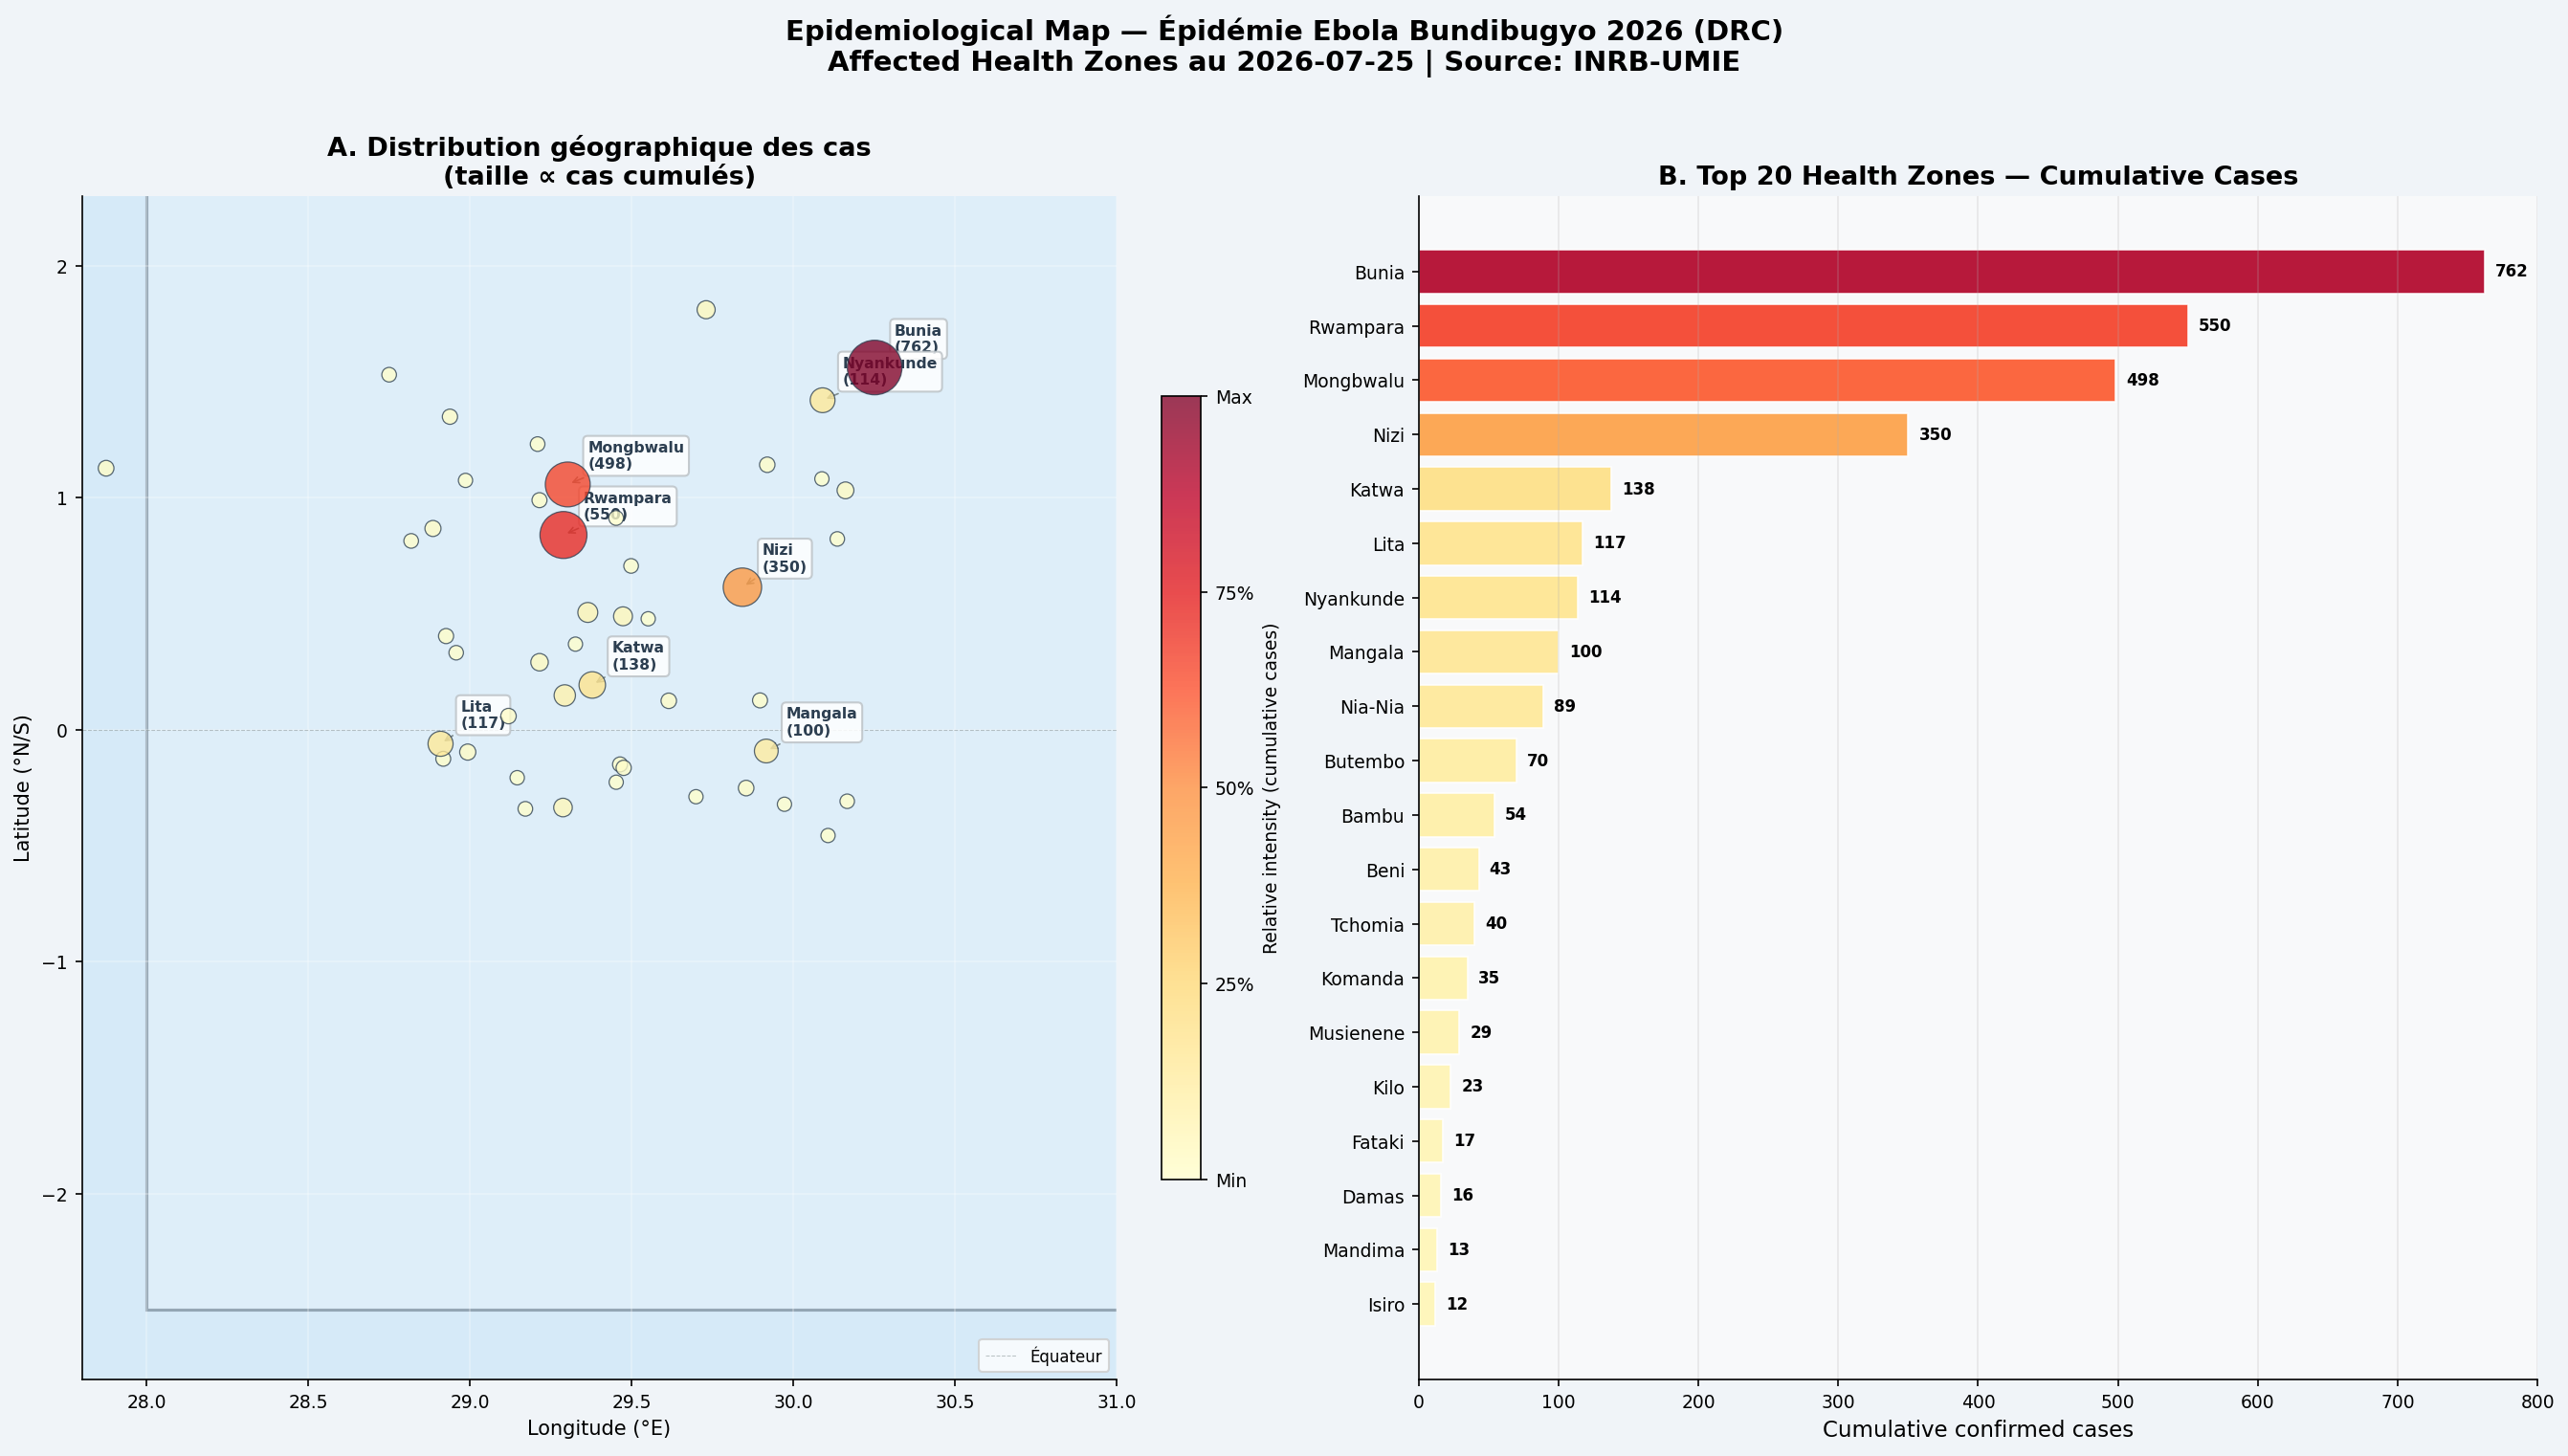

Saved: 13_map_geo_ebola.png

   Zones actives    : 48
   Total cas (zones): 3,200
   Zone la + touchée: Bunia (762 cas)


In [9]:
# ── Carte géographique DRC — Zones touchées par Ebola ────────────────
def build_geodataframe_zones(data: Dict) -> Optional[gpd.GeoDataFrame]:
    """
    Construit un GeoDataFrame des zones de santé affectées avec
    leurs coordonnées approximatives (Nord-Kivu / Ituri / DRC).
    Source coordonnées : OCHA RDC Zone Santé 2023 (centroides publiés).
    """
    # Coordonnées centroides des zones de santé DRC (lat, lon)
    ZONE_GEO = {
        # Nord-Kivu
        'Butembo':       ( 0.148,  29.293),
        'Beni':          ( 0.489,  29.473),
        'Katwa':         ( 0.193,  29.378),
        'Mabalako':      (-0.226,  29.452),
        'Musienene':     ( 0.291,  29.215),
        'Kalunguta':     ( 1.231,  29.209),
        'Vuhovi':        ( 0.369,  29.326),
        'Oicha':         ( 0.706,  29.498),
        'Biena':         ( 0.081,  29.145),
        'Alimbongo':     ( 0.850,  28.850),
        'Lubero':        ( 0.171,  29.254),
        'Kayna':         (-0.870,  28.830),
        'Rwangoma':      ( 0.127,  29.345),
        'Kyondo':        ( 0.059,  29.119),
        'Mutwanga':      ( 0.562,  29.661),
        'Kanyabayonga':  (-0.600,  28.720),
        'Nyankunde':     ( 1.420,  30.090),
        'Manguredjipa':  ( 0.495,  28.938),
        'Pinga':         (-0.880,  27.600),
        'Masisi':        (-1.410,  28.820),
        'Walikale':      (-1.416,  28.039),
        'Rutshuru':      (-1.183,  29.448),
        'Kiwanja':       (-1.046,  29.481),
        # Ituri
        'Bunia':         ( 1.561,  30.251),
        'Mandima':       ( 1.127,  27.875),
        'Mambasa':       ( 1.349,  28.938),
        'Nia-Nia':       ( 1.410,  27.590),
        'Komanda':       ( 1.810,  29.730),
        'Lolwa':         ( 1.530,  28.750),
        # Maniema
        'Lubutu':        (-0.712,  26.585),
        # Sud-Kivu
        'Uvira':         (-3.396,  29.138),
        'Fizi':          (-4.296,  29.110),
        # Équateur
        'Bikoro':        (-0.754,  18.144),
        'Mbandaka':      ( 0.047,  18.261),
    }

    key = 'cum_cases'
    if key not in data:
        return None

    df      = data[key]
    last_dt = df['date'].max()
    df_last = (
        df[(df['date'] == last_dt) & (df['zone'] != 'DRC') & (df['value'] >= 0)]
        .groupby('zone')['value'].sum()
        .reset_index()
    )

    rows = []
    for _, row in df_last.iterrows():
        zone = row['zone']
        val  = float(row['value'])
        if zone in ZONE_GEO:
            lat, lon = ZONE_GEO[zone]
        else:
            # Zones non répertoriées : placement aléatoire dans Nord-Kivu
            np.random.seed(abs(hash(zone)) % 2**31)
            lat = np.random.uniform(-0.5, 1.2)
            lon = np.random.uniform(28.8, 30.2)
        rows.append({'zone': zone, 'cases': val, 'lat': lat, 'lon': lon})

    gdf = gpd.GeoDataFrame(
        pd.DataFrame(rows),
        geometry=gpd.points_from_xy(
            [r['lon'] for r in rows],
            [r['lat'] for r in rows]
        ),
        crs='EPSG:4326'
    )
    return gdf, last_dt


def plot_geo_map(data: Dict, cfg: Config) -> None:
    """
    Carte géographique DRC avec geopandas :
    - Fond de carte DRC (polygone approximatif)
    - Points proportionnels aux cas par zone
    - Choroplèthe par intensité
    - Annotations des zones les plus touchées
    """
    if not GEO_AVAILABLE:
        print("⚠️  geopandas non disponible — carte ignorée")
        return

    result = build_geodataframe_zones(data)
    if result is None:
        print("❌ Insufficient data pour la carte")
        return
    gdf, last_dt = result

    if gdf.empty:
        print("❌ GeoDataFrame vide")
        return

    # ── Fond de carte : contour approximatif DRC ──────────────────────
    # Bounding box Nord-Kivu / Ituri (zone épidémique principale)
    from shapely.geometry import box as shapely_box
    drc_extent = shapely_box(28.0, -2.5, 31.5, 2.5)  # Nord-Kivu + Ituri

    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    fig.patch.set_facecolor('#F0F4F8')
    fig.suptitle(
        f"Epidemiological Map — Épidémie Ebola Bundibugyo 2026 (DRC)\n"
        f"Affected Health Zones au {last_dt.date()} | Source: INRB-UMIE",
        fontsize=14, fontweight='bold', y=1.01
    )

    # ── Panneau gauche : carte points proportionnels ──────────────────
    ax1 = axes[0]
    ax1.set_facecolor('#D6EAF8')

    # Contour de zone (rectangle approx)
    from matplotlib.patches import FancyBboxPatch, Rectangle
    rect = Rectangle((28.0, -2.5), 3.5, 5.0,
                     linewidth=1.5, edgecolor='#2C3E50',
                     facecolor='#EBF5FB', alpha=0.4)
    ax1.add_patch(rect)

    # Gradient de couleur selon intensité
    max_cases = gdf['cases'].max() if gdf['cases'].max() > 0 else 1
    gdf['norm'] = gdf['cases'] / max_cases

    cmap   = plt.cm.YlOrRd
    colors = [cmap(n * 0.85 + 0.05) for n in gdf['norm']]
    sizes  = [max(30, min(800, (n * 700 + 50))) for n in gdf['norm']]

    sc = ax1.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=gdf['norm'], cmap='YlOrRd', vmin=0, vmax=1,
        s=sizes, alpha=0.78, edgecolors='#2C3E50', linewidths=0.6,
        zorder=5
    )

    # Annotations top 8 zones
    top8 = gdf.nlargest(8, 'cases')
    for _, row in top8.iterrows():
        ax1.annotate(
            f"{row['zone']}\n({int(row['cases']):,})",
            xy=(row.geometry.x, row.geometry.y),
            xytext=(10, 8), textcoords='offset points',
            fontsize=7.5, fontweight='bold',
            color='#2C3E50',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#BDC3C7', alpha=0.85),
            arrowprops=dict(arrowstyle='->', color='#7F8C8D', lw=0.8)
        )

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax1, fraction=0.035, pad=0.04)
    cbar.set_label('Relative intensity (cumulative cases)', fontsize=9)
    cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(['Min', '25%', '50%', '75%', 'Max'])

    # Grille et axes
    ax1.set_xlim(27.8, 31.0)
    ax1.set_ylim(-2.8, 2.3)
    ax1.set_xlabel('Longitude (°E)', fontsize=10)
    ax1.set_ylabel('Latitude (°N/S)', fontsize=10)
    ax1.set_title('A. Distribution géographique des cas\n(taille ∝ cas cumulés)', fontweight='bold')
    ax1.grid(True, alpha=0.3, color='white', lw=0.8)

    # Lignes de référence
    ax1.axhline(0, color='#7F8C8D', lw=0.5, ls='--', alpha=0.5, label='Équateur')
    ax1.legend(fontsize=8, loc='lower right')

    # ── Panneau droit : classement zones ─────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#F8F9FA')

    top20 = gdf.nlargest(20, 'cases').sort_values('cases')
    norm_vals = top20['cases'] / (top20['cases'].max() + 1e-8)
    bar_colors = [cmap(v * 0.85 + 0.05) for v in norm_vals]

    bars = ax2.barh(top20['zone'], top20['cases'],
                    color=bar_colors, edgecolor='white', lw=0.8, alpha=0.9)

    # Valeurs sur les barres
    for bar, val in zip(bars, top20['cases']):
        ax2.text(bar.get_width() + top20['cases'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{int(val):,}", va='center', fontsize=8, fontweight='bold')

    # Risk threshold élevé
    if 'RISK_THR' in dir() and RISK_THR:
        ax2.axvline(RISK_THR, color='red', lw=1.5, ls='--', alpha=0.7,
                    label=f'High-risk threshold ({int(RISK_THR):,} cases)')
        ax2.legend(fontsize=8)

    ax2.set_title('B. Top 20 Health Zones — Cumulative Cases',
                  fontweight='bold')
    ax2.set_xlabel('Cumulative confirmed cases')
    ax2.grid(True, alpha=0.25, axis='x')

    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "13_carte_geo_ebola.png",
                dpi=600, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print("Saved: 13_map_geo_ebola.png")

    # ── Statistiques récapitulatives ──────────────────────────────────
    n_zones   = len(gdf[gdf['cases'] > 0])
    total_cas = int(gdf['cases'].sum())
    top1      = gdf.nlargest(1, 'cases').iloc[0]
    print(f"\n   Zones actives    : {n_zones}")
    print(f"   Total cas (zones): {total_cas:,}")
    print(f"   Zone la + touchée: {top1['zone']} ({int(top1['cases']):,} cas)")


plot_geo_map(DATA, CFG)


DRC HEALTH ZONE MAP — EBOLA BUNDIBUGYO OUTBREAK 2026
✅ GeoJSON loaded: 519 health zones
   Columns: ['nom', 'zscode', 'province', 'aggregated_insp_linelist', 'ccvi', 'cross_border', 'epi', 'epi_mve_inrb_app', 'fao_lccs', 'flowminder_short_trips', 'gdp_pc', 'genomic_surveillance', 'grid3_healthsites', 'healthsites_io', 'insp_sitrep', 'public_health_response', 'refugee_sites', 'testing_capacity', 'worldpop', 'geometry']
✅ Cases loaded: 48 zones | last date: 2026-07-25
   Zone name column in GeoJSON: 'nom'
✅ Merge complete: 519 zones | touched: 44 | untouched: 475


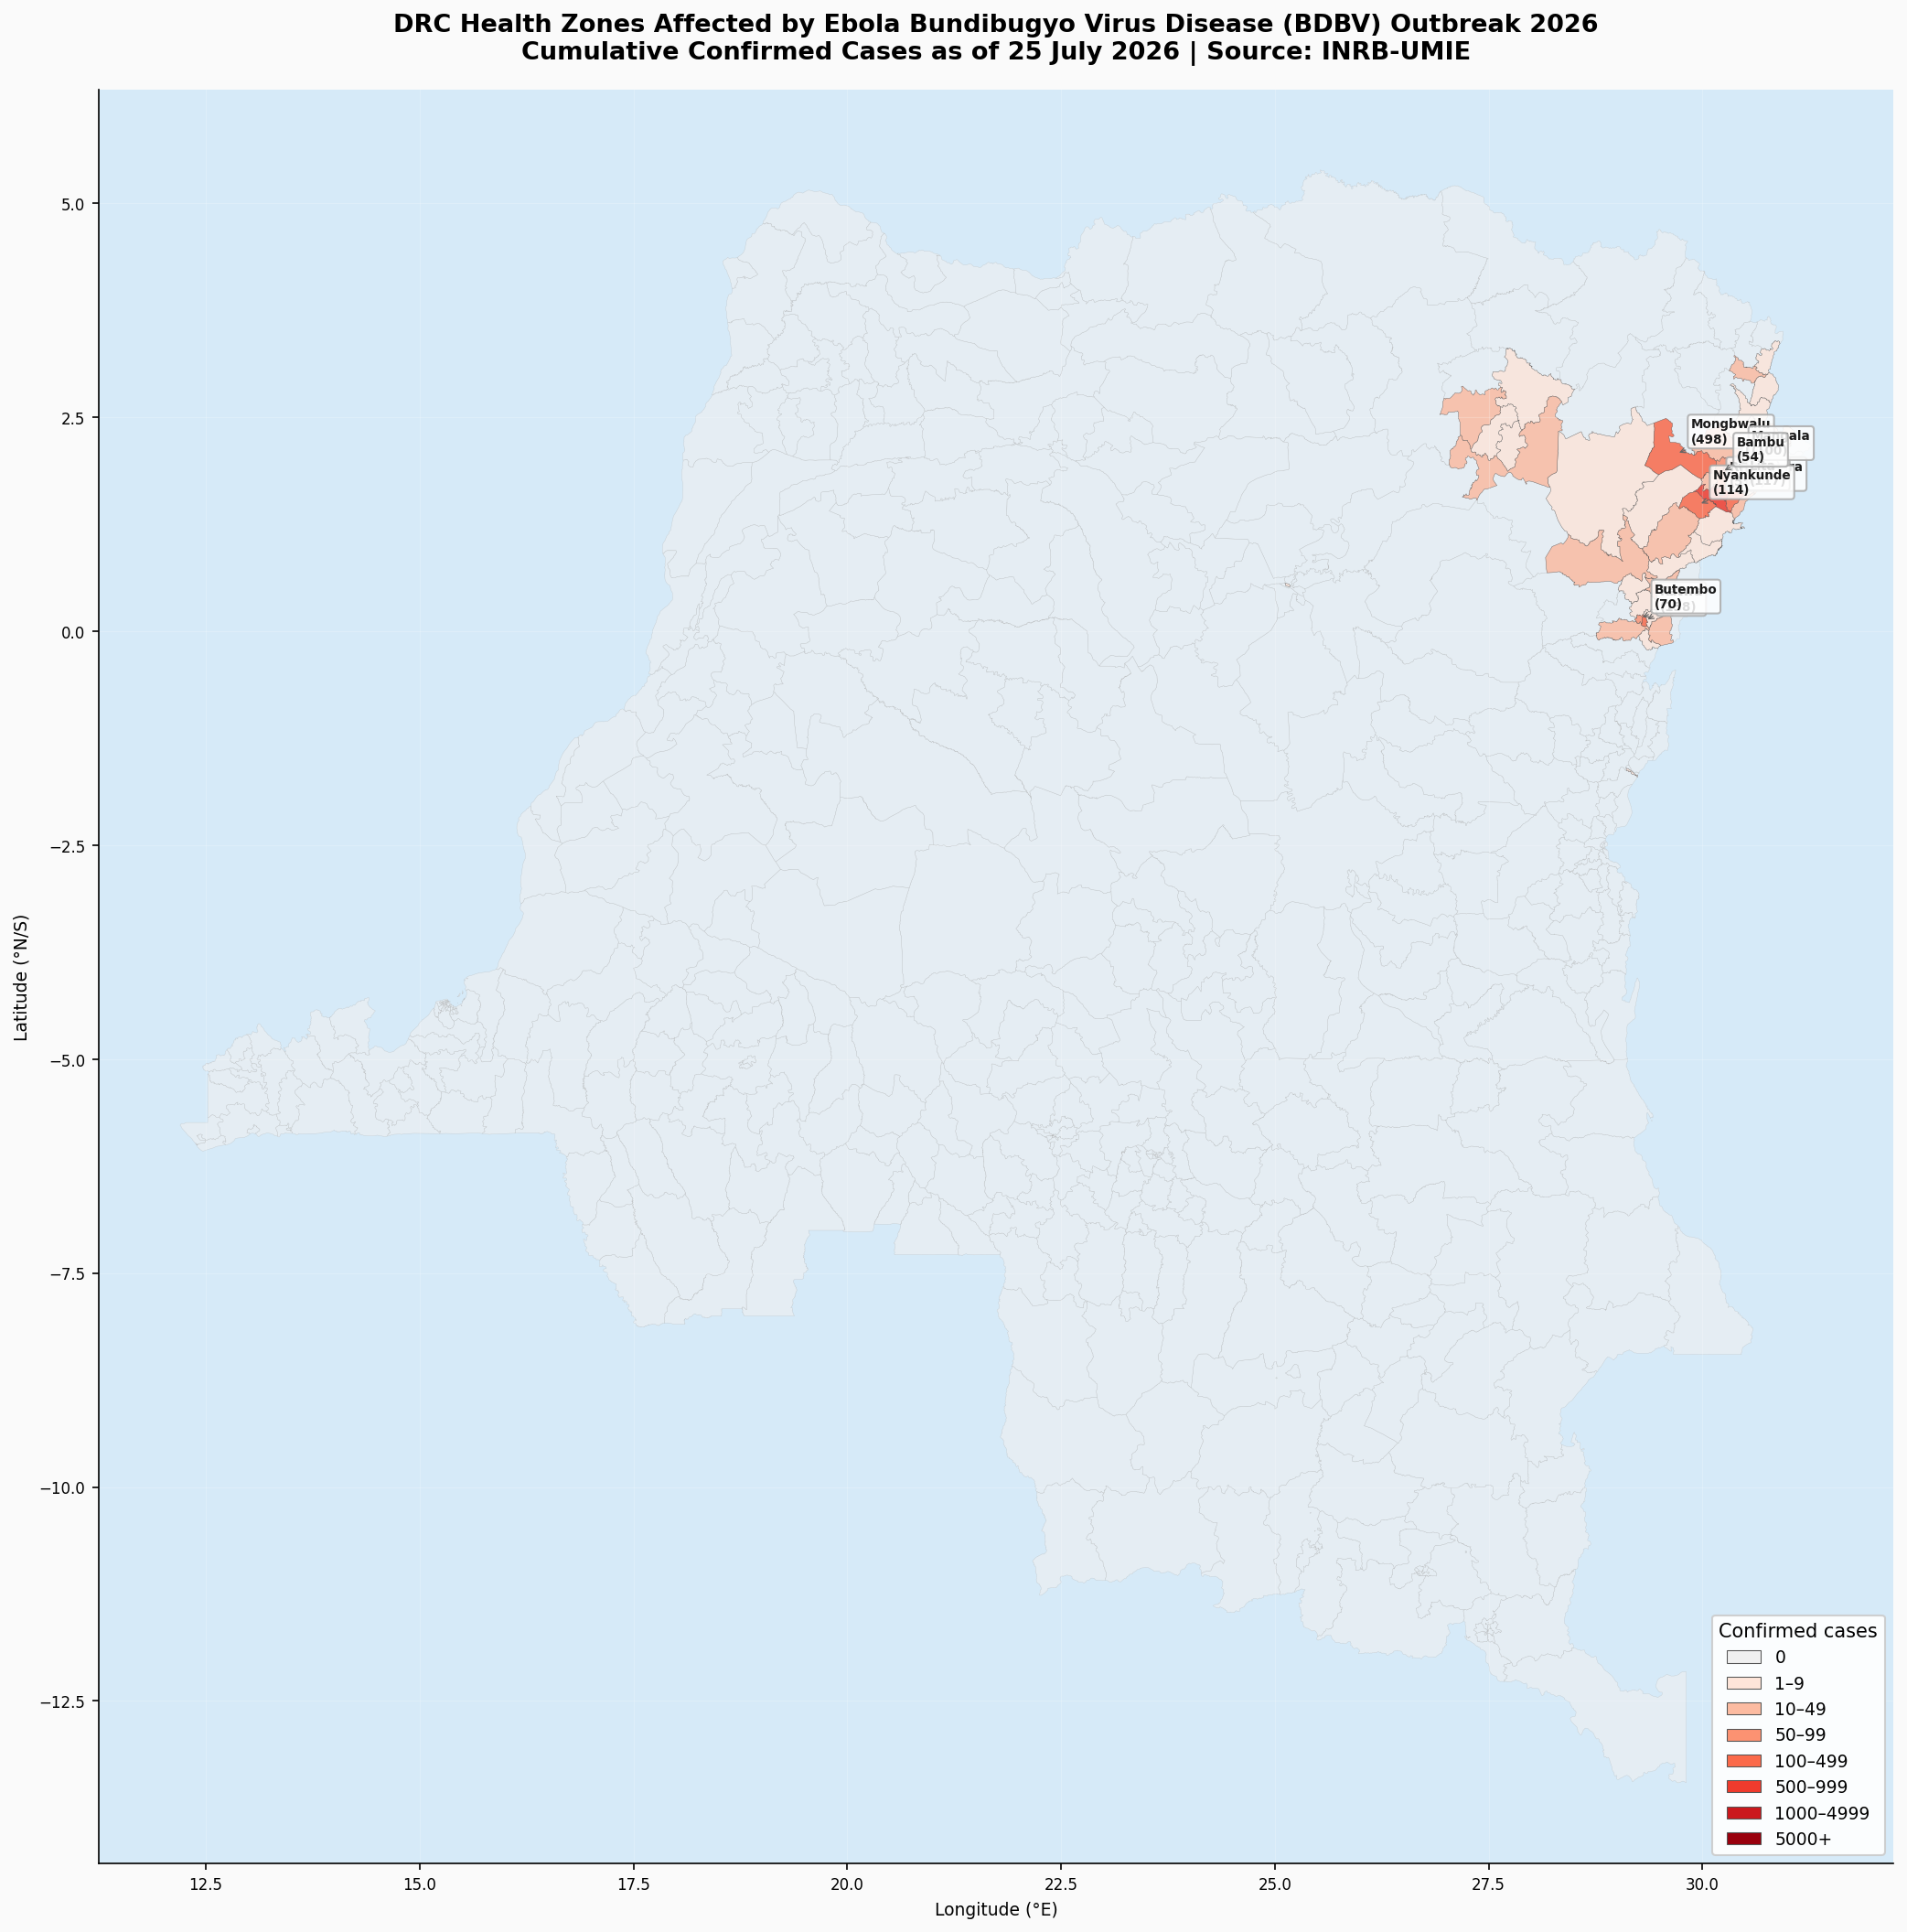

✅ Static map saved: outputs\figures\14_drc_choropleth_map.png
✅ Interactive map saved: outputs\15_drc_interactive_map.html

── Zone Statistics ─────────────────────────────────────────────────
   Total health zones  : 519
   Affected zones      : 44  (8.5%)
   Unaffected zones    : 475

   Case distribution:
            1–9  →   22 zones
          10–49  →   12 zones
          50–99  →    2 zones
        100–499  →    6 zones
        500–999  →    2 zones

   Top 10 most affected zones:
      1. Bunia                         762 cases
      2. Rwampara                      550 cases
      3. Mongbwalu                     498 cases
      4. Nizi                          350 cases
      5. Katwa                         138 cases
      6. Lita                          117 cases
      7. Nyankunde                     114 cases
      8. Mangala                       100 cases
      9. Butembo                        70 cases
     10. Bambu                          54 cases

   ✅ Statistics e

In [10]:
# ══════════════════════════════════════════════════════════════════════
# FULL GeoJSON MAP — DRC Health Zones Affected by Ebola Bundibugyo 2026
# Requires: drc_health_zones.geojson in donnees_extraites/build/
#           OR fallback to point-based map with known coordinates
# ══════════════════════════════════════════════════════════════════════

import os, json as _json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load GeoJSON shapefile ─────────────────────────────────────────
def load_shapefile(data_dir: str = "donnees_extraites/build"):
    """Load DRC health zones GeoJSON. Returns GeoDataFrame or None."""
    geojson_path = os.path.join(data_dir, "drc_health_zones.geojson")
    if not os.path.exists(geojson_path):
        print(f"⚠️  GeoJSON not found at {geojson_path} — using point fallback")
        return None
    try:
        gdf = gpd.read_file(geojson_path)
        print(f"✅ GeoJSON loaded: {len(gdf)} health zones")
        print(f"   Columns: {list(gdf.columns)}")
        return gdf
    except Exception as e:
        print(f"❌ GeoJSON load error: {e}")
        return None


# ── 2. Load cumulative cases ──────────────────────────────────────────
def load_cases_data(data_dir: str = "donnees_extraites/build"):
    """Load latest cumulative confirmed cases per zone."""
    path = os.path.join(data_dir, "long/insp_sitrep__cumulative_confirmed_cases.csv")
    if not os.path.exists(path):
        # Try from already-loaded DATA dict
        if 'cum_cases' in DATA:
            df = DATA['cum_cases'].copy()
            last_dt = df['date'].max()
            df_last = df[df['date'] == last_dt].copy()
            df_last['value'] = pd.to_numeric(df_last['value'], errors='coerce').fillna(0)
            print(f"✅ Cases from memory: {len(df_last)} zones | last date: {last_dt.date()}")
            return df_last
        print("❌ Cases file not found")
        return None
    try:
        df = pd.read_csv(path)
        if len(df.columns) == 3:
            df.columns = ['zone', 'date', 'value']
        df['date']  = pd.to_datetime(df['date'], errors='coerce')
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        df = df.dropna(subset=['date', 'value'])
        last_dt  = df['date'].max()
        df_last  = df[df['date'] == last_dt].copy()
        print(f"✅ Cases loaded: {len(df_last)} zones | last date: {last_dt.date()}")
        return df_last
    except Exception as e:
        print(f"❌ Cases load error: {e}")
        return None


# ── 3. Merge geodata + cases ──────────────────────────────────────────
def merge_geo_cases(gdf, cases_df):
    """Join GeoDataFrame with cases data on zone name."""
    name_col = next(
        (c for c in gdf.columns
         if c.lower() in ['nom', 'name', 'zone', 'zone_sante', 'sante']),
        gdf.columns[0]
    )
    print(f"   Zone name column in GeoJSON: '{name_col}'")
    gdf = gdf.copy()
    cases_df = cases_df.copy()
    gdf['zone_clean']      = gdf[name_col].astype(str).str.strip()
    cases_df['zone_clean'] = cases_df['zone'].astype(str).str.strip()
    merged = gdf.merge(cases_df[['zone_clean', 'value']], on='zone_clean', how='left')
    merged['value'] = merged['value'].fillna(0)
    touched = (merged['value'] > 0).sum()
    print(f"✅ Merge complete: {len(merged)} zones | touched: {touched} | untouched: {len(merged)-touched}")
    return merged, name_col


# ── 4. Fallback: point-based GeoDataFrame from known coordinates ──────
def build_fallback_gdf(cases_df):
    """Build a point GeoDataFrame using hardcoded zone centroids."""
    ZONE_GEO = {
        'Butembo':      ( 0.148, 29.293), 'Beni':          ( 0.489, 29.473),
        'Katwa':        ( 0.193, 29.378), 'Mabalako':      (-0.226, 29.452),
        'Musienene':    ( 0.291, 29.215), 'Kalunguta':     ( 1.231, 29.209),
        'Vuhovi':       ( 0.369, 29.326), 'Oicha':         ( 0.706, 29.498),
        'Biena':        ( 0.081, 29.145), 'Alimbongo':     ( 0.850, 28.850),
        'Lubero':       ( 0.171, 29.254), 'Kayna':         (-0.870, 28.830),
        'Rwangoma':     ( 0.127, 29.345), 'Kyondo':        ( 0.059, 29.119),
        'Mutwanga':     ( 0.562, 29.661), 'Kanyabayonga':  (-0.600, 28.720),
        'Nyankunde':    ( 1.420, 30.090), 'Manguredjipa':  ( 0.495, 28.938),
        'Pinga':        (-0.880, 27.600), 'Masisi':        (-1.410, 28.820),
        'Walikale':     (-1.416, 28.039), 'Rutshuru':      (-1.183, 29.448),
        'Bunia':        ( 1.561, 30.251), 'Mandima':       ( 1.127, 27.875),
        'Mambasa':      ( 1.349, 28.938), 'Komanda':       ( 1.810, 29.730),
        'Bikoro':       (-0.754, 18.144), 'Mbandaka':      ( 0.047, 18.261),
    }
    rows = []
    for _, row in cases_df.iterrows():
        zone = str(row['zone']).strip()
        val  = float(row['value'])
        if zone in ZONE_GEO:
            lat, lon = ZONE_GEO[zone]
        else:
            np.random.seed(abs(hash(zone)) % 2**31)
            lat = np.random.uniform(-0.5, 1.2)
            lon = np.random.uniform(28.8, 30.2)
        rows.append({'zone_clean': zone, 'value': val, 'geometry': Point(lon, lat)})
    gdf = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    return gdf


# ── 5. Color scale ────────────────────────────────────────────────────
BINS   = [0, 1, 10, 50, 100, 500, 1000, 5000, 10000]
LABELS = ['0', '1–9', '10–49', '50–99', '100–499', '500–999', '1000–4999', '5000+']
COLORS = ['#f0f0f0','#fee5d9','#fcbba1','#fc9272','#fb6a4a','#ef3b2d','#cb181d','#99000d']
COLOR_MAP = dict(zip(LABELS, COLORS))

def get_color(cases: float) -> str:
    for threshold, color in zip(BINS[1:], COLORS[1:]):
        if cases < threshold:
            return COLORS[BINS.index(threshold) - 1] if cases > 0 else COLORS[0]
    return COLORS[-1]

def assign_category(val: float) -> str:
    if val <= 0: return '0'
    for i in range(1, len(BINS)):
        if val < BINS[i]:
            return LABELS[i-1]
    return LABELS[-1]


# ── 6. Static choropleth map ──────────────────────────────────────────
def create_static_map(merged_gdf, last_date, use_polygons: bool = True,
                      cfg=None) -> None:
    """Publication-quality static choropleth map."""

    merged_gdf = merged_gdf.copy()
    merged_gdf['category'] = merged_gdf['value'].apply(assign_category)
    merged_gdf['color']    = merged_gdf['value'].apply(get_color)

    fig, ax = plt.subplots(1, 1, figsize=(14, 18))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#D6EAF8')

    if use_polygons:
        # Full choropleth on polygons
        untouched = merged_gdf[merged_gdf['value'] == 0]
        touched   = merged_gdf[merged_gdf['value']  > 0]

        untouched.plot(ax=ax, color='#f0f0f0', edgecolor='#AAAAAA',
                       linewidth=0.15, alpha=0.6)

        for label in LABELS[1:]:
            subset = touched[touched['category'] == label]
            if not subset.empty:
                subset.plot(ax=ax, color=COLOR_MAP[label],
                            edgecolor='#555555', linewidth=0.2, alpha=0.85)

        # Annotate top-10 zones via centroid
        top10 = merged_gdf[merged_gdf['value'] > 0].nlargest(10, 'value')
        for _, row in top10.iterrows():
            try:
                cx = row.geometry.centroid.x
                cy = row.geometry.centroid.y
                ax.annotate(
                    f"{row['zone_clean']}\n({int(row['value']):,})",
                    xy=(cx, cy), xytext=(8, 6), textcoords='offset points',
                    fontsize=6.5, fontweight='bold', color='#1A1A1A',
                    bbox=dict(boxstyle='round,pad=0.25', fc='white',
                              ec='#AAAAAA', alpha=0.85),
                    arrowprops=dict(arrowstyle='->', color='#666666', lw=0.6)
                )
            except Exception:
                pass
    else:
        # Point-based fallback
        untouched = merged_gdf[merged_gdf['value'] == 0]
        touched   = merged_gdf[merged_gdf['value']  > 0]
        max_val   = merged_gdf['value'].max() or 1

        untouched.plot(ax=ax, color='#f0f0f0', markersize=8,
                       edgecolor='#AAAAAA', linewidth=0.4, alpha=0.5)

        sc = ax.scatter(
            touched.geometry.x, touched.geometry.y,
            c=touched['value'], cmap='YlOrRd',
            s=[max(40, min(700, v / max_val * 600 + 40)) for v in touched['value']],
            alpha=0.8, edgecolors='#333333', linewidths=0.5, zorder=5
        )
        plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02,
                     label='Cumulative confirmed cases')

        for _, row in touched.nlargest(8, 'value').iterrows():
            ax.annotate(
                f"{row['zone_clean']}\n({int(row['value']):,})",
                xy=(row.geometry.x, row.geometry.y),
                xytext=(10, 8), textcoords='offset points',
                fontsize=7, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#AAAAAA', alpha=0.88),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=0.7)
            )

    # ── Legend ─────────────────────────────────────────────────────
    if use_polygons:
        from matplotlib.patches import Patch as MPatch
        legend_elements = [
            MPatch(facecolor=COLOR_MAP[lbl], edgecolor='#555555',
                   linewidth=0.5, label=lbl)
            for lbl in LABELS
        ]
        ax.legend(
            handles=legend_elements,
            title='Confirmed cases', title_fontsize=10,
            fontsize=9, loc='lower right',
            frameon=True, framealpha=0.92, edgecolor='#CCCCCC'
        )

    # ── Title & axes ───────────────────────────────────────────────
    ax.set_title(
        f"DRC Health Zones Affected by Ebola Bundibugyo Virus Disease (BDBV) Outbreak 2026\n"
        f"Cumulative Confirmed Cases as of {last_date.strftime('%d %B %Y')} | Source: INRB-UMIE",
        fontsize=13, fontweight='bold', pad=16
    )
    ax.set_xlabel('Longitude (°E)', fontsize=9)
    ax.set_ylabel('Latitude (°N/S)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2, color='white', lw=0.6)

    plt.tight_layout()
    out_path = (cfg.FIG_DIR / "14_drc_choropleth_map.png") if cfg else "14_drc_choropleth_map.png"
    fig.savefig(out_path, dpi=600, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅ Static map saved: {out_path}")


# ── 7. Interactive Folium map ─────────────────────────────────────────
def create_interactive_map(merged_gdf, last_date, use_polygons: bool = True,
                            cfg=None) -> None:
    """Interactive choropleth map with Folium."""
    try:
        import folium
        from folium.plugins import HeatMap
    except ImportError:
        print("⚠️  folium not installed — skipping interactive map (pip install folium)")
        return

    map_center = [-2.5, 23.5] if not use_polygons else [0.0, 29.0]
    zoom       = 6 if not use_polygons else 7
    m = folium.Map(location=map_center, zoom_start=zoom, tiles='CartoDB positron')

    # Title
    title_html = f"""
    <div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
                background:white;padding:10px 20px;border-radius:8px;
                box-shadow:2px 2px 6px rgba(0,0,0,.3);z-index:1000;
                font-family:Arial;font-size:13px;font-weight:bold;text-align:center;">
        🦠 DRC — Ebola Bundibugyo 2026<br>
        <span style="font-size:10px;font-weight:normal;">
        Cumulative confirmed cases per health zone — {last_date.strftime('%d %B %Y')}</span>
    </div>"""
    m.get_root().html.add_child(folium.Element(title_html))

    if use_polygons:
        for _, row in merged_gdf.iterrows():
            if row.geometry is None:
                continue
            cases = float(row['value'])
            color = get_color(cases)
            popup_html = (
                f"<b>Health Zone:</b> {row['zone_clean']}<br>"
                f"<b>Cumul. cases:</b> {int(cases):,}<br>"
                f"<b>Status:</b> {'🔴 Affected' if cases > 0 else '⚪ Not affected'}"
            )
            folium.GeoJson(
                row.geometry.__geo_interface__,
                style_function=lambda x, c=color, cs=cases: {
                    'fillColor': c, 'color': '#333333', 'weight': 0.5,
                    'fillOpacity': 0.82 if cs > 0 else 0.25
                },
                tooltip=folium.Tooltip(f"{row['zone_clean']}: {int(cases):,} cases"),
                popup=folium.Popup(popup_html, max_width=260)
            ).add_to(m)
    else:
        # Point markers
        max_val = merged_gdf['value'].max() or 1
        for _, row in merged_gdf[merged_gdf['value'] > 0].iterrows():
            cases = float(row['value'])
            folium.CircleMarker(
                location=[row.geometry.y, row.geometry.x],
                radius=max(5, min(22, cases / max_val * 20 + 4)),
                color=get_color(cases), fill=True,
                fill_color=get_color(cases), fill_opacity=0.75,
                tooltip=folium.Tooltip(f"{row['zone_clean']}: {int(cases):,} cases"),
                popup=folium.Popup(
                    f"<b>{row['zone_clean']}</b><br>Cases: {int(cases):,}", max_width=200
                )
            ).add_to(m)

    # Legend HTML
    legend_items = "".join(
        f'<p><span style="background:{c};padding:2px 10px;">&nbsp;&nbsp;</span> {lbl}</p>'
        for lbl, c in COLOR_MAP.items()
    )
    m.get_root().html.add_child(folium.Element(
        f'''<div style="position:fixed;bottom:40px;right:40px;border:1.5px solid #888;
                        z-index:9999;background:white;padding:12px;border-radius:6px;
                        font-size:11px;font-family:Arial;">
        <p style="margin:0 0 6px;font-weight:bold;">Confirmed cases</p>
        {legend_items}</div>'''
    ))

    folium.LayerControl().add_to(m)

    out_path = (cfg.OUTPUT_DIR / "15_drc_interactive_map.html") if cfg else "15_drc_interactive_map.html"
    m.save(str(out_path))
    print(f"✅ Interactive map saved: {out_path}")


# ── 8. Zone statistics ────────────────────────────────────────────────
def generate_zone_statistics(merged_gdf, last_date, cfg=None) -> dict:
    """Compute and export zone-level statistics."""
    touched     = merged_gdf[merged_gdf['value'] > 0]
    not_touched = merged_gdf[merged_gdf['value'] == 0]

    print("\n── Zone Statistics ─────────────────────────────────────────────────")
    print(f"   Total health zones  : {len(merged_gdf)}")
    print(f"   Affected zones      : {len(touched)}  ({len(touched)/max(len(merged_gdf),1)*100:.1f}%)")
    print(f"   Unaffected zones    : {len(not_touched)}")

    print("\n   Case distribution:")
    for i in range(1, len(BINS)):
        lo, hi  = BINS[i-1], BINS[i]
        subset  = touched[(touched['value'] >= lo) & (touched['value'] < hi)]
        if len(subset):
            print(f"     {LABELS[i-1]:>10}  →  {len(subset):3d} zones")

    print("\n   Top 10 most affected zones:")
    top10 = touched.nlargest(10, 'value')
    for rank, (_, row) in enumerate(top10.iterrows(), 1):
        print(f"     {rank:2d}. {row['zone_clean']:<25}  {int(row['value']):>6,} cases")

    stats = {
        'total_zones':         int(len(merged_gdf)),
        'affected_zones':      int(len(touched)),
        'unaffected_zones':    int(len(not_touched)),
        'pct_affected':        round(len(touched) / max(len(merged_gdf), 1) * 100, 2),
        'last_update':         last_date.strftime('%Y-%m-%d'),
        'top10_zones': [
            {'rank': i+1, 'zone': row['zone_clean'], 'cases': int(row['value'])}
            for i, (_, row) in enumerate(top10.iterrows())
        ]
    }

    out_path = (cfg.REPORT_DIR / "zone_statistics.json") if cfg else "zone_statistics.json"
    with open(out_path, 'w', encoding='utf-8') as f:
        _json.dump(stats, f, indent=2, ensure_ascii=False)
    print(f"\n   ✅ Statistics exported: {out_path}")
    return stats


# ── 9. Run pipeline ───────────────────────────────────────────────────
print("=" * 68)
print("DRC HEALTH ZONE MAP — EBOLA BUNDIBUGYO OUTBREAK 2026")
print("=" * 68)

_gdf      = load_shapefile()
_cases_df = load_cases_data()

if _cases_df is None:
    print("❌ No case data available — map aborted")
else:
    _last_date = _cases_df['date'].max() if 'date' in _cases_df.columns else pd.Timestamp.now()

    if _gdf is not None:
        # Full choropleth mode
        _merged, _ = merge_geo_cases(_gdf, _cases_df)
        _use_poly  = True
    else:
        # Fallback point mode
        _merged   = build_fallback_gdf(_cases_df)
        _use_poly = False
        print("   Running in point-marker mode (no GeoJSON polygon data)")

    create_static_map(_merged, _last_date, use_polygons=_use_poly, cfg=CFG)
    create_interactive_map(_merged, _last_date, use_polygons=_use_poly, cfg=CFG)
    _stats = generate_zone_statistics(_merged, _last_date, cfg=CFG)

    print("\n" + "=" * 68)
    print("✅ MAPPING COMPLETE")
    print("=" * 68)
    print(f"   Static map  → {CFG.FIG_DIR}/14_drc_choropleth_map.png")
    print(f"   Interactive → {CFG.OUTPUT_DIR}/15_drc_interactive_map.html")
    print(f"   Statistics  → {CFG.REPORT_DIR}/zone_statistics.json")


## MODULE 3 · Transfer Learning from Historical Outbreaks

── Historical outbreak simulations ─────────────────────────────────
   WestAfrica_2014                 R₀=1.71  durée=104w  total=28,616
   DRC_2018_Nord_Kivu              R₀=1.59  durée=94w  total=3,481
   DRC_2021_Nord_Kivu              R₀=1.20  durée=8w  total=12
   Uganda_2022                     R₀=1.40  durée=16w  total=164


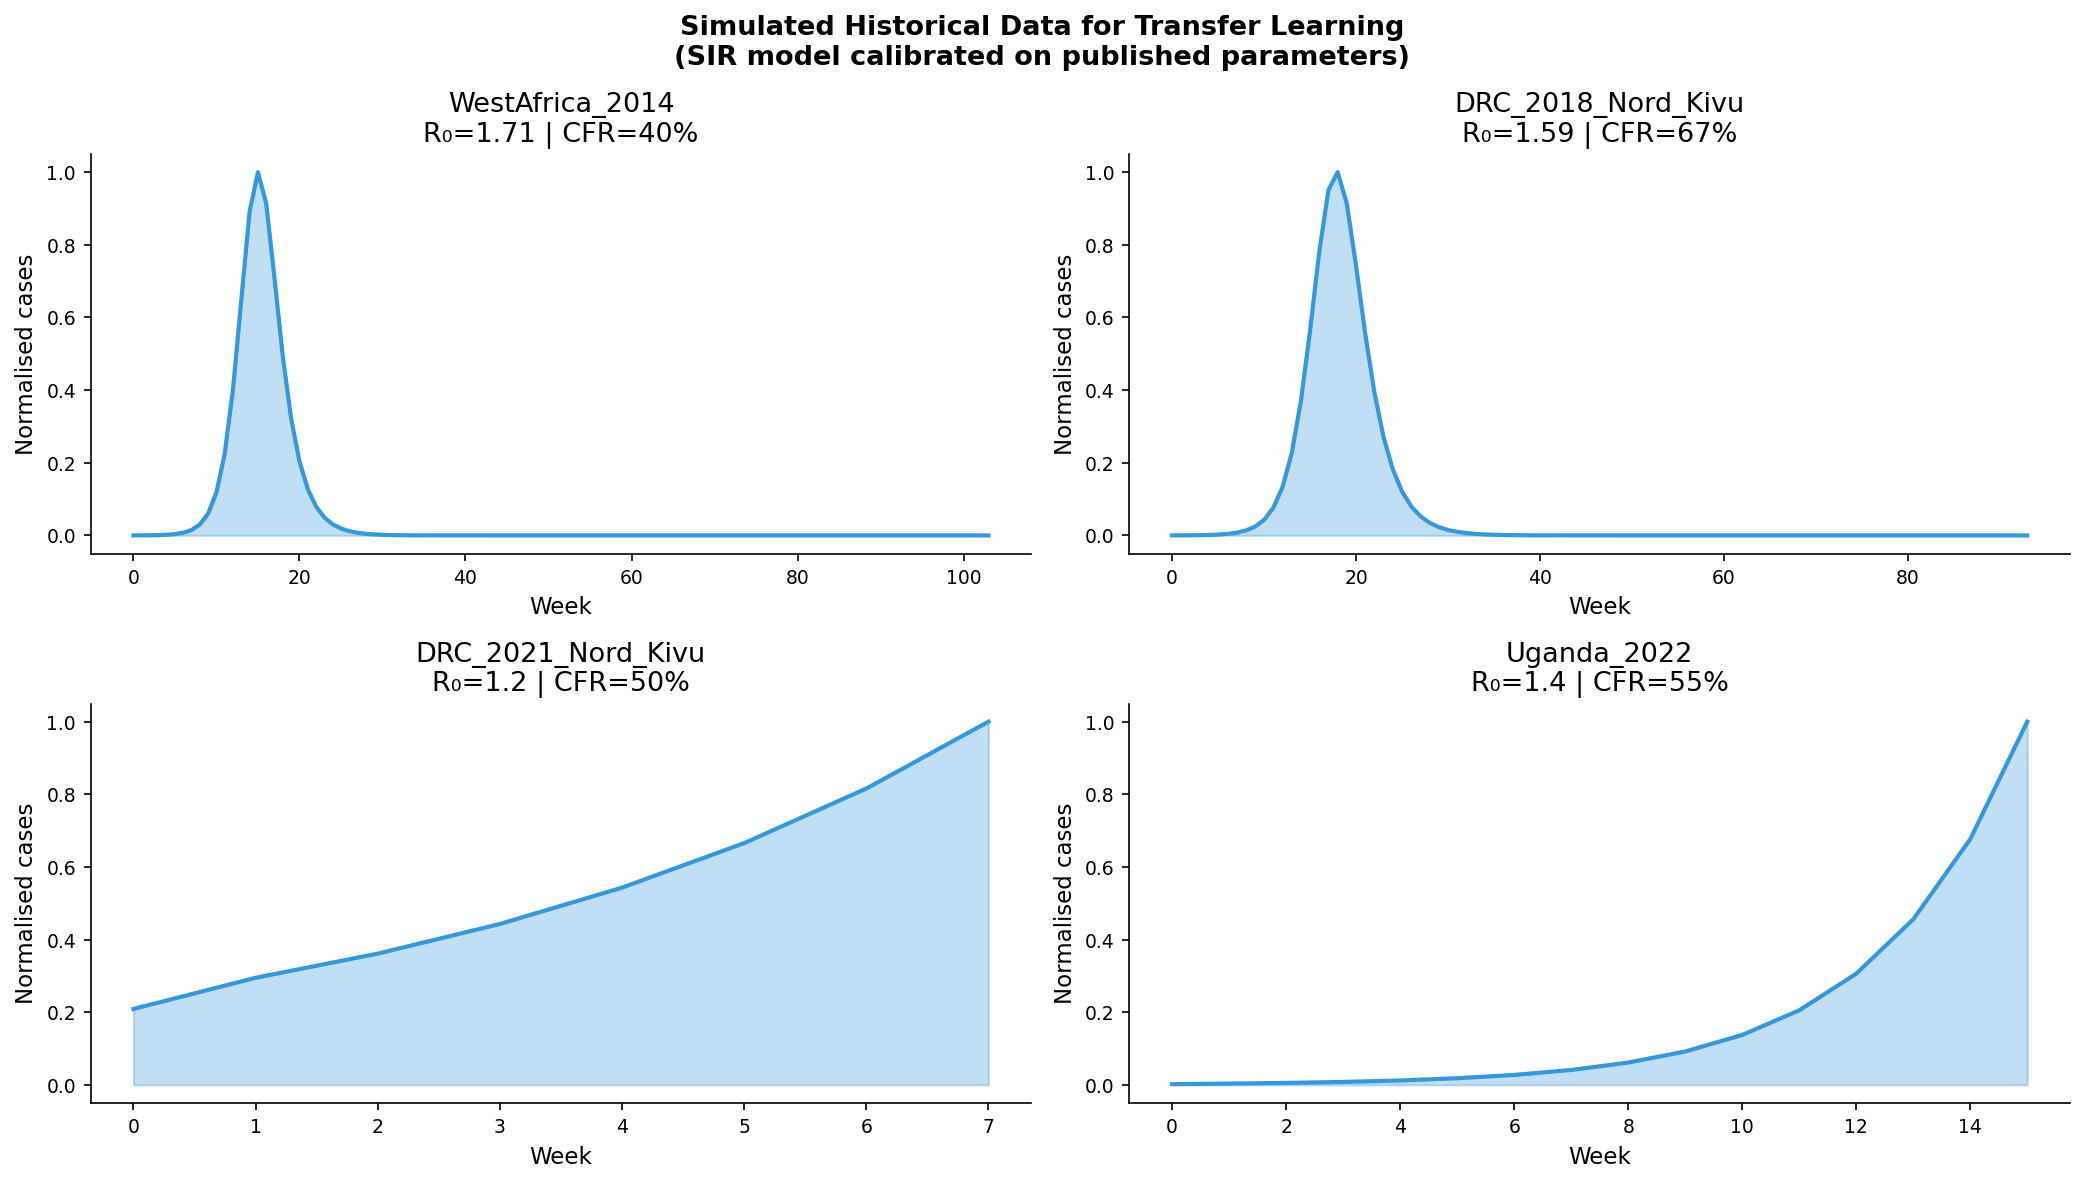

Saved: 04_historical_outbreaks.png


In [11]:
# ── Simulation de séries historiques ─────────────────────────────────
def simulate_sir_epidemic(
    R0: float, gamma: float = 1/7.0,
    N: int = 1_000_000, I0: int = 5,
    duration_weeks: int = 52, seed: int = 42
) -> np.ndarray:
    """Simule une épidémie SIR et retourne les nouveaux cas hebdomadaires."""
    np.random.seed(seed)
    beta = R0 * gamma

    def sir(y, t, beta, gamma, N):
        S, I, R = y
        dS = -beta * S * I / N
        dI =  beta * S * I / N - gamma * I
        dR =  gamma * I
        return [dS, dI, dR]

    t   = np.linspace(0, duration_weeks * 7, duration_weeks * 7)
    sol = odeint(sir, [N - I0, I0, 0], t, args=(beta, gamma, N))
    # Nouveaux cas quotidiens = différence S
    new_daily = -np.diff(sol[:, 0], prepend=sol[0, 0])
    new_daily = np.maximum(new_daily, 0)
    # Agrégation hebdomadaire
    weeks = len(new_daily) // 7
    weekly = np.array([new_daily[w*7:(w+1)*7].sum() for w in range(weeks)])
    # Normalisation [0, 1]
    weekly = weekly / (weekly.max() + 1e-8)
    return weekly[:duration_weeks]


def build_historical_features(cfg: Config) -> Dict[str, np.ndarray]:
    """Construit les features pour chaque épidémie historique."""
    hist_series = {}
    for name, meta in cfg.HISTORICAL_OUTBREAKS.items():
        series = simulate_sir_epidemic(
            R0=meta['R0'],
            duration_weeks=meta['duration_weeks'],
            seed=hash(name) % 2**31
        )
        # Features dérivées
        features = {
            'series':         series,
            'R0':             meta['R0'],
            'cfr':            meta['cfr'],
            'peak_week':      meta['peak_week'],
            'total_cases_norm': meta['total_cases'] / 30000,
            'strain_zaire':   1 if meta['strain'] == 'Zaire' else 0,
        }
        hist_series[name] = features
        print(f"   {name:30s}  R₀={meta['R0']:.2f}  durée={meta['duration_weeks']}w  "
              f"total={meta['total_cases']:,}")

    return hist_series


print("── Historical outbreak simulations ─────────────────────────────────")
HIST_DATA = build_historical_features(CFG)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Simulated Historical Data for Transfer Learning\n"
             "(SIR model calibrated on published parameters)",
             fontsize=13, fontweight='bold')

for ax, (name, feat) in zip(axes.flatten(), HIST_DATA.items()):
    ax.fill_between(range(len(feat['series'])), feat['series'], alpha=0.3, color=PALETTE[2])
    ax.plot(feat['series'], color=PALETTE[2], lw=2)
    ax.set_title(f"{name}\nR₀={feat['R0']} | CFR={feat['cfr']:.0%}")
    ax.set_xlabel("Week")
    ax.set_ylabel("Normalised cases")

plt.tight_layout()
fig.savefig(CFG.FIG_DIR / "04_historical_outbreaks.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: 04_historical_outbreaks.png")


Pre-training complete | Final loss: 0.000763


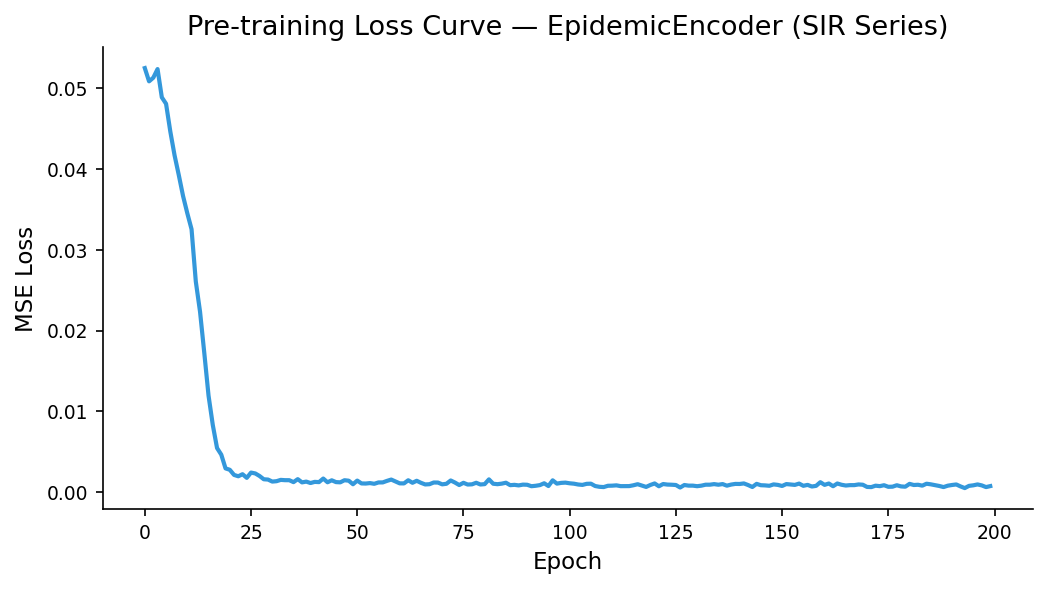

Encoder ready on device: cpu


In [12]:
# ── Pre-trained Epidemic Encoder (historical SIR data) ───────────────
class EpidemicEncoder(nn.Module):
    """
    Flexible LSTM encoder.
    Pre-training : input_dim=1  (normalised SIR series)
    Fine-tuning  : input_dim=N_features (real epidemiological features)
    Both use cases are handled by separate instances.
    """
    def __init__(self, input_dim: int = 1, hidden: int = 64,
                 n_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.input_dim = input_dim
        self.hidden    = hidden
        self.encoder   = nn.LSTM(
            input_dim, hidden, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.projector = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.encoder(x)
        return self.projector(out[:, -1, :]).squeeze(-1)

    def encode(self, x):
        _, (h, _) = self.encoder(x)
        return h[-1]


def pretrain_encoder(hist_data: Dict, cfg: Config,
                     seq_len: int = 10) -> EpidemicEncoder:
    """Pre-train encoder on 1-D normalised SIR historical series."""
    all_X, all_y = [], []
    for name, feat in hist_data.items():
        series = feat['series']
        for i in range(seq_len, len(series)):
            all_X.append(series[i-seq_len:i])
            all_y.append(series[i])

    if not all_X:
        print("Warning: insufficient historical data — returning untrained encoder")
        return EpidemicEncoder(input_dim=1).to(DEVICE)

    X = torch.tensor(np.array(all_X), dtype=torch.float32).unsqueeze(-1).to(DEVICE)
    y = torch.tensor(np.array(all_y), dtype=torch.float32).to(DEVICE)

    model   = EpidemicEncoder(input_dim=1).to(DEVICE)
    optim   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit    = nn.MSELoss()
    dataset = TensorDataset(X, y)
    loader  = DataLoader(dataset, batch_size=32, shuffle=True)

    model.train()
    losses = []
    for epoch in range(200):
        ep_loss = 0.0
        for xb, yb in loader:
            optim.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            ep_loss += loss.item()
        losses.append(ep_loss / len(loader))

    print(f"Pre-training complete | Final loss: {losses[-1]:.6f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(losses, color=PALETTE[2], lw=2)
    ax.set_title("Pre-training Loss Curve — EpidemicEncoder (SIR Series)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    fig.savefig(CFG.FIG_DIR / "05_pretrain_loss.png", dpi=600,
                bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    return model


# Pre-train on historical outbreaks (input_dim=1, no X_TRAIN needed)
PRETRAINED_ENCODER = pretrain_encoder(HIST_DATA, CFG, seq_len=10)
print(f"Encoder ready on device: {next(PRETRAINED_ENCODER.parameters()).device}")


In [13]:
# ── Transfer Learning fine-tuning helpers ────────────────────────────
def build_tl_encoder(n_features: int, pretrained_1d: EpidemicEncoder,
                     cfg: Config) -> EpidemicEncoder:
    """
    Build EpidemicEncoder(input_dim=n_features) and transfer compatible
    LSTM weights from the 1-D pre-trained model.
    Input→hidden weights are re-initialised (dimension mismatch);
    hidden→hidden weights are transferred.
    """
    model  = EpidemicEncoder(input_dim=n_features,
                             hidden=pretrained_1d.hidden).to(DEVICE)
    src_sd = pretrained_1d.state_dict()
    tgt_sd = model.state_dict()
    transferred = [k for k in src_sd
                   if k in tgt_sd and src_sd[k].shape == tgt_sd[k].shape]
    for k in transferred:
        tgt_sd[k] = src_sd[k].clone()
    model.load_state_dict(tgt_sd)
    print(f"   Weights transferred: {len(transferred)}/{len(tgt_sd)} layers")
    return model


def make_seq_arrays(X: np.ndarray, y: np.ndarray,
                    sl: int) -> Tuple[np.ndarray, np.ndarray]:
    """Sliding-window sequences: (N-sl, sl, F) → (N-sl,)."""
    Xs, ys = [], []
    for i in range(sl, len(X)):
        Xs.append(X[i-sl:i])
        ys.append(y[i])
    if not Xs:
        return np.empty((0, sl, X.shape[1]), dtype=np.float32), np.empty(0, dtype=np.float32)
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


def finetune_encoder(
    pretrained_1d: EpidemicEncoder,
    X_train: np.ndarray, y_train: np.ndarray,
    X_test:  np.ndarray, y_test:  np.ndarray,
    cfg: Config,
    seq_len: int = 7,
) -> Tuple:
    """
    Fine-tune a new EpidemicEncoder(input_dim=N_features) on real
    epidemiological feature sequences.
    - Encoder frozen, only projector head trained.
    - Adaptive seq_len: min(seq_len, len(X_train)//4).
    - Returns (model, y_true_test, y_pred_test).
    """
    n_features = X_train.shape[1]
    sl = min(seq_len, max(2, len(X_train) // 4))
    print(f"   TL-LSTM | seq_len={sl}  n_features={n_features}  "
          f"train={len(X_train)}  test={len(X_test)}")

    Xtr, ytr = make_seq_arrays(X_train, y_train, sl)
    Xte, yte = make_seq_arrays(X_test,  y_test,  sl)

    if len(Xtr) == 0:
        print("   Warning: no training sequences produced — TL-LSTM skipped")
        return None, np.array([]), np.array([])

    Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
    Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)

    Xtr_t = torch.tensor(Xtr, dtype=torch.float32).to(DEVICE)
    ytr_t = torch.tensor(ytr, dtype=torch.float32).to(DEVICE)
    Xte_t = torch.tensor(Xte, dtype=torch.float32).to(DEVICE) if len(Xte) else None

    model = build_tl_encoder(n_features, pretrained_1d, cfg)

    for p in model.encoder.parameters():
        p.requires_grad = False
    optim = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-4, weight_decay=1e-4
    )
    crit   = nn.HuberLoss()
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t),
                        batch_size=cfg.DL_BATCH, shuffle=True)

    best, patience = float('inf'), 0
    model.train()
    for epoch in range(cfg.DL_EPOCHS):
        ep = sum(
            (lambda xb, yb: (optim.zero_grad(),
                             (loss := crit(model(xb), yb)),
                             loss.backward(),
                             nn.utils.clip_grad_norm_(model.parameters(), 1.0),
                             optim.step(),
                             loss.item())[-1])(xb, yb)
            for xb, yb in loader
        ) / max(len(loader), 1)
        if ep < best - 1e-6:
            best, patience = ep, 0
        else:
            patience += 1
        if patience >= cfg.DL_PATIENCE:
            break

    for p in model.parameters():
        p.requires_grad = True

    model.eval()
    y_pred = np.array([])
    if Xte_t is not None and len(Xte_t):
        with torch.no_grad():
            y_pred = model(Xte_t).cpu().numpy()

    mn = min(len(y_pred), len(yte))
    if mn > 1:
        from sklearn.metrics import mean_squared_error as _mse, r2_score as _r2
        rmse = np.sqrt(_mse(yte[:mn], y_pred[:mn]))
        r2v  = _r2(yte[:mn], y_pred[:mn])
        print(f"   TL-LSTM trained | {epoch+1} epochs | RMSE={rmse:.4f}  R²={r2v:.4f}")
    else:
        print("   Warning: test set too small to compute metrics")

    return model, yte, y_pred


print("Transfer Learning helpers defined (finetune_encoder, build_tl_encoder).")
print("Fine-tuning will run after X_TRAIN / X_TEST are built in Module 4.")


Transfer Learning helpers defined (finetune_encoder, build_tl_encoder).
Fine-tuning will run after X_TRAIN / X_TEST are built in Module 4.


## MODULE 4 · Feature Engineering & Pipeline Preparation

In [14]:
# ── Construction des features ─────────────────────────────────────────
def build_features(data: Dict, cfg: Config) -> Tuple[pd.DataFrame, List[str], str]:
    """
    Construit un DataFrame de features à partir des données par zone.
    Retourne : (df_features, feature_cols, target_col)
    """
    key = 'cum_cases'
    if key not in data:
        print(f"❌ '{key}' absent — features non construites")
        return pd.DataFrame(), [], 'value'

    df = data[key].copy()

    # ── Temporal features
    df['dow']  = df['date'].dt.dayofweek
    df['month']= df['date'].dt.month
    df['doy']  = df['date'].dt.dayofyear
    df['week'] = df['date'].dt.isocalendar().week.astype(int)

    # ── Lag features (par zone)
    for lag in [1, 3, 7, 14, 21, 30]:
        df[f'lag_{lag}'] = df.groupby('zone')['value'].shift(lag).fillna(0)

    # ── Rolling statistics
    for w in [3, 7, 14]:
        df[f'roll_mean_{w}'] = df.groupby('zone')['value'].transform(
            lambda x: x.rolling(w, min_periods=1).mean().fillna(0)
        )
        df[f'roll_std_{w}'] = df.groupby('zone')['value'].transform(
            lambda x: x.rolling(w, min_periods=1).std().fillna(0)
        )

    # ── Growth rate
    df['growth_rate'] = df.groupby('zone')['value'].pct_change().fillna(0)

    # ── Zone cumulative total
    df['zone_cumul'] = df.groupby('zone')['value'].cumsum()

    # ── Zone encoding
    le = LabelEncoder()
    df['zone_enc'] = le.fit_transform(df['zone'].astype(str))

    feature_cols = [
        'dow', 'month', 'doy', 'week', 'zone_enc',
        'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_30',
        'roll_mean_3', 'roll_mean_7', 'roll_mean_14',
        'roll_std_3', 'roll_std_7', 'roll_std_14',
        'growth_rate', 'zone_cumul'
    ]
    target_col = 'value'

    # Supprimer les rows à valeur cible nulle (peu informatives)
    df = df.dropna(subset=feature_cols + [target_col])

    print(f"Features built: {len(feature_cols)} features | {len(df)} rows")
    return df, feature_cols, target_col


DF_FEAT, FEATURE_COLS, TARGET_COL = build_features(DATA, CFG)


Features built: 19 features | 1821 rows


In [15]:
# ── Split few-shot ────────────────────────────────────────────────────
import numpy as np
from sklearn.preprocessing import RobustScaler

def few_shot_split(
    df: pd.DataFrame, feature_cols: List[str], target_col: str,
    cfg: Config
) -> Tuple:
    """Crée le split temporel few-shot (N premières semaines = train)."""

    df_sorted = df.sort_values(['zone', 'date']).reset_index(drop=True)

    # Date boundaries
    all_dates = df_sorted['date'].sort_values().unique()
    n_total   = len(all_dates)
    n_train   = min(cfg.N_SHOTS, int(n_total * (1 - cfg.TEST_RATIO)))

    if n_train >= len(all_dates):
        n_train = max(1, len(all_dates) - 2)

    cutoff = all_dates[n_train]
    train  = df_sorted[df_sorted['date'] < cutoff]
    test   = df_sorted[df_sorted['date'] >= cutoff]

    X_train = train[feature_cols].values.astype(np.float64)
    y_train = train[target_col].values.astype(np.float64)
    X_test  = test[feature_cols].values.astype(np.float64)
    y_test  = test[target_col].values.astype(np.float64)

    # ── Nettoyage inf / nan ───────────────────────────────────────────
    def clean_X(arr: np.ndarray) -> np.ndarray:
        arr = np.where(np.isnan(arr), 0.0, arr)
        arr = np.where(np.isinf(arr), 0.0, arr)
        # Clamp valeurs extrêmes (outliers numériques)
        for col in range(arr.shape[1]):
            q99 = np.nanpercentile(arr[:, col], 99)
            q01 = np.nanpercentile(arr[:, col],  1)
            arr[:, col] = np.clip(arr[:, col], q01, q99)
        return arr

    X_train = clean_X(X_train)
    X_test  = clean_X(X_test)
    y_train = np.where(np.isnan(y_train) | np.isinf(y_train), 0.0, y_train)
    y_test  = np.where(np.isnan(y_test)  | np.isinf(y_test),  0.0, y_test)

    # Risk threshold (75e percentile des cas positifs)
    pos = y_train[y_train > 0]
    RISK_THR = float(np.percentile(pos, cfg.RISK_PCTILE)) if len(pos) else 1.0

    print(f"Split few-shot:")
    print(f"  Train : {len(train):5d} obs | {train['date'].min().date()} → {train['date'].max().date()}")
    print(f"  Test  : {len(test):5d} obs | {test['date'].min().date()} → {test['date'].max().date()}")
    print(f"  Seuil de risque élevé (75e perc.) : {RISK_THR:.1f} cas")

    # RobustScaler scaling (insensible aux outliers)
    scaler     = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Final check
    assert np.all(np.isfinite(X_train_sc)), "❌ X_train_sc contient encore des inf/nan"
    assert np.all(np.isfinite(X_test_sc)),  "❌ X_test_sc contient encore des inf/nan"
    print("  Data cleaned — no inf/nan found")

    return X_train_sc, y_train, X_test_sc, y_test, scaler, RISK_THR, train, test


if not DF_FEAT.empty:
    X_TRAIN, Y_TRAIN, X_TEST, Y_TEST, SCALER, RISK_THR, TRAIN_DF, TEST_DF = \
        few_shot_split(DF_FEAT, FEATURE_COLS, TARGET_COL, CFG)
    print(f"\n  X_TRAIN: {X_TRAIN.shape} | X_TEST: {X_TEST.shape}")


Split few-shot:
  Train :   202 obs | 2026-05-15 → 2026-05-30
  Test  :  1619 obs | 2026-06-01 → 2026-07-25
  Seuil de risque élevé (75e perc.) : 9.0 cas
  Data cleaned — no inf/nan found

  X_TRAIN: (202, 19) | X_TEST: (1619, 19)


In [16]:
# ── TL-LSTM: fine-tune on Bundibugyo 2026 (runs after X_TRAIN ready) ─
if ('X_TRAIN' in dir() and 'PRETRAINED_ENCODER' in dir()
        and X_TRAIN is not None and PRETRAINED_ENCODER is not None
        and len(X_TRAIN) > 4):
    FINETUNED_ENCODER, TL_Y_TRUE, TL_Y_PRED = finetune_encoder(
        PRETRAINED_ENCODER, X_TRAIN, Y_TRAIN, X_TEST, Y_TEST,
        CFG, seq_len=CFG.SEQ_LEN
    )
else:
    missing = []
    if 'X_TRAIN' not in dir() or X_TRAIN is None:
        missing.append('X_TRAIN')
    if 'PRETRAINED_ENCODER' not in dir() or PRETRAINED_ENCODER is None:
        missing.append('PRETRAINED_ENCODER')
    print(f"Warning: TL-LSTM skipped — missing: {missing}")
    FINETUNED_ENCODER = None
    TL_Y_TRUE = TL_Y_PRED = np.array([])


   TL-LSTM | seq_len=7  n_features=19  train=202  test=1619
   Weights transferred: 11/12 layers
   TL-LSTM trained | 300 epochs | RMSE=95.3117  R²=-0.0338


## MODULE 5 · Unified Metrics

In [17]:
# ── Métriques publication-ready ──────────────────────────────────────
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    name: str, risk_thr: float) -> Dict:
    """
    Calcule toutes les métriques regression + classification.
    """
    yp = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    yt = np.asarray(y_true, dtype=float)
    mn = min(len(yp), len(yt))
    yp, yt = yp[:mn], yt[:mn]

    if mn == 0:
        return {'Model': name}

    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp))

    mask = yt > 0
    mape = float(np.mean(np.abs((yt[mask] - yp[mask]) / (yt[mask] + 1e-8))) * 100) if mask.sum() else np.nan
    smape = float(np.mean(2 * np.abs(yt - yp) / (np.abs(yt) + np.abs(yp) + 1e-8)) * 100)
    rmsle = float(np.sqrt(np.mean((np.log1p(np.clip(yt, 0, None)) - np.log1p(np.clip(yp, 0, None)))**2)))
    corr  = float(np.corrcoef(yt, yp)[0, 1]) if mn > 1 else np.nan

    # Theil's U
    naive_err = np.diff(yt)
    theil_u   = (np.sqrt(np.mean((yt[1:] - yp[1:])**2)) /
                 (np.sqrt(np.mean(naive_err**2)) + 1e-8)) if mn > 1 else np.nan

    # Classification — détection zones à risque élevé
    yt_bin = (yt > risk_thr).astype(int)
    yp_bin = (yp > risk_thr).astype(int)
    acc    = float(accuracy_score(yt_bin, yp_bin))
    prec   = float(precision_score(yt_bin, yp_bin, zero_division=0))
    rec    = float(recall_score(yt_bin, yp_bin, zero_division=0))
    f1     = float(f1_score(yt_bin, yp_bin, zero_division=0))
    auc    = float(roc_auc_score(yt_bin, yp)) if len(np.unique(yt_bin)) > 1 else np.nan

    return {
        'Model':      name,
        'RMSE':       round(rmse, 4),
        'MAE':        round(mae, 4),
        'MAPE':       round(mape, 2) if not np.isnan(mape) else np.nan,
        'SMAPE':      round(smape, 2),
        'RMSLE':      round(rmsle, 4),
        'R2':         round(r2, 4),
        'Corr':       round(corr, 4) if not np.isnan(corr) else np.nan,
        'Theil_U':    round(theil_u, 4) if not np.isnan(theil_u) else np.nan,
        'Accuracy':   round(acc, 4),
        'Precision':  round(prec, 4),
        'Recall':     round(rec, 4),
        'F1':         round(f1, 4),
        'AUC':        round(auc, 4) if not np.isnan(auc) else np.nan,
    }

print("compute_metrics function defined")
print(f"   Seuil de risque: {RISK_THR:.1f} cas")


compute_metrics function defined
   Seuil de risque: 9.0 cas


## MODULE 6 · Baseline Models (Few-Shot ML)

In [18]:
# ── Baseline model training ─────────────────────────────────────────────
ALL_RESULTS = []
ALL_PREDS   = {}
ALL_MODELS  = {}

BASELINE_MODELS = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'RandomForest':     RandomForestRegressor(
        n_estimators=200, max_depth=12,
        min_samples_leaf=2, random_state=CFG.SEED, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=CFG.SEED, verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.03,
        num_leaves=15, subsample=0.8, colsample_bytree=0.8,
        random_state=CFG.SEED, verbose=-1
    ),
}

print("── Baseline model training ──────────────────────────────────")
print(f"   Train: {X_TRAIN.shape}  Test: {X_TEST.shape}")
print()

for name, model in BASELINE_MODELS.items():
    try:
        # LightGBM avec early stopping
        if name == 'LightGBM' and len(X_TRAIN) > 4:
            n_val = max(2, len(X_TRAIN) // 5)
            model.fit(
                X_TRAIN[:-n_val], Y_TRAIN[:-n_val],
                eval_set=[(X_TRAIN[-n_val:], Y_TRAIN[-n_val:])],
                callbacks=[lgb.early_stopping(30, verbose=False)]
            )
        else:
            model.fit(X_TRAIN, Y_TRAIN)

        preds = np.clip(model.predict(X_TEST), 0, None)
        res   = compute_metrics(Y_TEST, preds, name, RISK_THR)
        ALL_RESULTS.append(res)
        ALL_PREDS[name]  = preds
        ALL_MODELS[name] = model
        print(f"   {name:20s}  RMSE={res['RMSE']:.4f}  R²={res['R2']:.4f}  F1={res['F1']:.4f}")

    except Exception as e:
        print(f"   ❌ {name}: {e}")

print(f"\n→ {len(ALL_MODELS)} modèles entraînés")


── Baseline model training ──────────────────────────────────
   Train: (202, 19)  Test: (1619, 19)

   LinearRegression      RMSE=62.9938  R²=0.5467  F1=0.8670
   Ridge                 RMSE=62.8868  R²=0.5482  F1=0.8472
   RandomForest          RMSE=79.9764  R²=0.2693  F1=0.9116
   XGBoost               RMSE=79.4776  R²=0.2784  F1=0.9514
   LightGBM              RMSE=88.5699  R²=0.1038  F1=0.8546

→ 5 modèles entraînés


## MODULE 7 · LSTM & Transformer (PyTorch)

In [19]:
# ── Préparation séquences ─────────────────────────────────────────────
def make_sequences(X: np.ndarray, y: np.ndarray,
                   seq_len: int) -> Tuple[np.ndarray, np.ndarray]:
    """Crée des séquences glissantes (T, F) → y."""
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


SEQ_LEN = min(CFG.SEQ_LEN, max(3, len(X_TRAIN) // 3))
print(f"Longueur de séquence : {SEQ_LEN}")

X_all_seq  = np.vstack([X_TRAIN, X_TEST])
y_all_seq  = np.concatenate([Y_TRAIN, Y_TEST])
Xs_all, ys_all = make_sequences(X_all_seq, y_all_seq, SEQ_LEN)

n_few_seq = max(0, len(X_TRAIN) - SEQ_LEN)
DL_READY  = len(Xs_all) > n_few_seq + 2

if DL_READY:
    Xs_tr = torch.tensor(Xs_all[:n_few_seq], dtype=torch.float32).to(DEVICE)
    ys_tr = torch.tensor(ys_all[:n_few_seq], dtype=torch.float32).to(DEVICE)
    Xs_te = torch.tensor(Xs_all[n_few_seq:], dtype=torch.float32).to(DEVICE)
    ys_te = ys_all[n_few_seq:]
    print(f"Séquences train: {Xs_tr.shape}  test: {Xs_te.shape}")
else:
    print("⚠️  Insufficient data pour les modèles DL (ignorés)")


Longueur de séquence : 7
Séquences train: torch.Size([195, 7, 19])  test: torch.Size([1619, 7, 19])


In [20]:
# ── LSTM ──────────────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, in_dim: int, hidden: int = 64,
                 n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            in_dim, hidden, n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def train_dl_model(model: nn.Module, Xs_tr, ys_tr, cfg: Config,
                   name: str) -> Tuple[nn.Module, List[float]]:
    """Entraîne un modèle DL avec early stopping."""
    model = model.to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=cfg.DL_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.DL_EPOCHS)
    crit  = nn.HuberLoss()

    loader    = DataLoader(TensorDataset(Xs_tr, ys_tr),
                           batch_size=cfg.DL_BATCH, shuffle=True)
    best_loss = float('inf')
    patience  = 0
    losses    = []

    for epoch in range(cfg.DL_EPOCHS):
        model.train()
        ep = 0.0
        for xb, yb in loader:
            optim.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            ep += loss.item()
        sched.step()
        ep /= len(loader)
        losses.append(ep)
        if ep < best_loss - 1e-6:
            best_loss = ep
            patience  = 0
        else:
            patience += 1
        if patience >= cfg.DL_PATIENCE:
            break

    print(f"   {name:20s}  {epoch+1} époques  loss finale: {losses[-1]:.6f}")
    return model, losses


if DL_READY:
    lstm_model, lstm_losses = train_dl_model(
        LSTMForecaster(X_TRAIN.shape[1]), Xs_tr, ys_tr, CFG, 'LSTM'
    )
    lstm_model.eval()
    with torch.no_grad():
        lstm_preds = lstm_model(Xs_te).cpu().numpy()
    mn = min(len(lstm_preds), len(ys_te))
    lstm_res = compute_metrics(ys_te[:mn], lstm_preds[:mn], 'LSTM', RISK_THR)
    ALL_RESULTS.append(lstm_res)
    ALL_PREDS['LSTM'] = lstm_preds[:mn]
    ALL_MODELS['LSTM'] = lstm_model
    print(f"   LSTM  RMSE={lstm_res['RMSE']:.4f}  R²={lstm_res['R2']:.4f}  F1={lstm_res['F1']:.4f}")


   LSTM                  249 époques  loss finale: 1.150094
   LSTM  RMSE=94.8797  R²=-0.0284  F1=0.7440


In [21]:
# ── Transformer TFT-lite ──────────────────────────────────────────────
class TemporalTransformer(nn.Module):
    def __init__(self, in_dim: int, d_model: int = 32, nhead: int = 4,
                 n_layers: int = 2, dim_ff: int = 64, dropout: float = 0.2,
                 seq_len: int = 7):
        super().__init__()
        self.proj    = nn.Linear(in_dim, d_model)
        self.pos_enc = nn.Embedding(seq_len + 16, d_model)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head    = nn.Sequential(
            nn.Linear(d_model, 16), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(16, 1)
        )

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        x   = self.proj(x) + self.pos_enc(pos)
        x   = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(-1)


if DL_READY:
    tft_model, tft_losses = train_dl_model(
        TemporalTransformer(X_TRAIN.shape[1], seq_len=SEQ_LEN),
        Xs_tr, ys_tr, CFG, 'Transformer'
    )
    tft_model.eval()
    with torch.no_grad():
        tft_preds = tft_model(Xs_te).cpu().numpy()
    mn = min(len(tft_preds), len(ys_te))
    tft_res = compute_metrics(ys_te[:mn], tft_preds[:mn], 'Transformer', RISK_THR)
    ALL_RESULTS.append(tft_res)
    ALL_PREDS['Transformer'] = tft_preds[:mn]
    ALL_MODELS['Transformer'] = tft_model
    print(f"   Transformer  RMSE={tft_res['RMSE']:.4f}  R²={tft_res['R2']:.4f}  F1={tft_res['F1']:.4f}")


   Transformer           190 époques  loss finale: 1.225063
   Transformer  RMSE=100.2921  R²=-0.1491  F1=0.0647


In [22]:
# ── TL-LSTM inference results ────────────────────────────────────────
if (FINETUNED_ENCODER is not None
        and TL_Y_PRED is not None and len(TL_Y_PRED) > 0
        and TL_Y_TRUE is not None and len(TL_Y_TRUE) > 0):
    mn     = min(len(TL_Y_TRUE), len(TL_Y_PRED))
    tl_res = compute_metrics(TL_Y_TRUE[:mn], TL_Y_PRED[:mn], 'TL-LSTM', RISK_THR)
    ALL_RESULTS.append(tl_res)
    ALL_PREDS['TL-LSTM']  = TL_Y_PRED[:mn]
    ALL_MODELS['TL-LSTM'] = FINETUNED_ENCODER
    print(f"   TL-LSTM  RMSE={tl_res['RMSE']:.4f}  "
          f"R²={tl_res['R2']:.4f}  F1={tl_res['F1']:.4f}")
else:
    print("   TL-LSTM: no predictions available — excluded from ranking")


   TL-LSTM  RMSE=95.2843  R²=-0.0332  F1=0.7273


## MODULE 8 · Spatio-Temporal Graph Neural Network

In [23]:
# ── Build health-zone graph ──────────────────────────────────────────
def clean_node_features(arr: np.ndarray) -> np.ndarray:
    """Sanitise node feature matrix: nan→0, inf→0, clip to ±10σ."""
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    for col in range(arr.shape[1]):
        col_std  = arr[:, col].std()
        col_mean = arr[:, col].mean()
        if col_std > 0:
            arr[:, col] = np.clip(arr[:, col],
                                  col_mean - 10 * col_std,
                                  col_mean + 10 * col_std)
    return arr.astype(np.float32)


def build_zone_graph(data: Dict, cfg: Config):
    """
    Build a spatio-temporal graph of DRC health zones.
    Edges: temporal correlation between zones (|ρ| ≥ 0.5).
    Node features: last_cases, max_cases, mean_cases,
                   mean_growth (clipped), weeks_active.
    """
    key = 'cum_cases'
    if key not in data:
        print("❌ 'cum_cases' absent — graph not built")
        return None, []

    df    = data[key].copy()
    zones = [z for z in df['zone'].unique() if z != 'DRC']
    if not zones:
        print("No sub-national zones found")
        return None, []

    n_zones  = len(zones)
    zone_idx = {z: i for i, z in enumerate(zones)}
    last_dt  = df['date'].max()

    print(f"   Building graph: {n_zones} nodes")

    # ── Node features ─────────────────────────────────────────────
    node_feats = []
    for z in zones:
        zd = df[df['zone'] == z].sort_values('date')
        vals = pd.to_numeric(zd['value'], errors='coerce').fillna(0).values

        last_val     = float(vals[-1]) if len(vals) else 0.0
        max_val      = float(np.max(vals)) if len(vals) else 0.0
        mean_val     = float(np.mean(vals)) if len(vals) else 0.0
        # Growth: median of pct_change, clipped to [-5, 5]
        if len(vals) > 1:
            pct = np.diff(vals) / (np.abs(vals[:-1]) + 1e-6)
            growth = float(np.clip(np.nanmedian(pct), -5.0, 5.0))
        else:
            growth = 0.0
        weeks_active = float(np.sum(vals > 0))

        node_feats.append([last_val, max_val, mean_val, growth, weeks_active])

    raw_feats = np.array(node_feats, dtype=np.float64)
    raw_feats = clean_node_features(raw_feats)

    # StandardScaler after cleaning
    from sklearn.preprocessing import StandardScaler as _SS
    scaler_gnn = _SS()
    scaled_feats = scaler_gnn.fit_transform(raw_feats).astype(np.float32)
    scaled_feats = clean_node_features(scaled_feats)   # second pass after scaling

    # Verify
    assert np.all(np.isfinite(scaled_feats)), "Node features still contain inf/nan!"
    print(f"   Node features: {scaled_feats.shape}  finite={np.all(np.isfinite(scaled_feats))}")

    X_nodes = torch.tensor(scaled_feats, dtype=torch.float32)

    # ── Target : last cumulative cases per zone ────────────────────
    y_vals = []
    for z in zones:
        v = df[(df['zone'] == z) & (df['date'] == last_dt)]['value']
        y_vals.append(float(v.sum()) if len(v) else 0.0)
    y_nodes = torch.tensor(
        np.clip(y_vals, 0, None).astype(np.float32), dtype=torch.float32
    )

    # ── Edges : temporal correlation (|ρ| ≥ 0.5) ─────────────────
    pivot = df[df['zone'].isin(zones)].pivot_table(
        index='zone', columns='date', values='value', fill_value=0
    )
    # Reindex to match zones order
    pivot = pivot.reindex(zones).fillna(0)
    mat   = pivot.values.astype(np.float64)
    # Replace inf/nan rows with zeros
    mat   = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)

    edge_src, edge_dst = [], []
    THRESHOLD = 0.5
    if mat.shape[1] > 1:
        # Normalise rows to avoid constant-vector issues
        norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-8
        mat_n = mat / norms
        corr_mat = mat_n @ mat_n.T   # cosine similarity (proxy for correlation)
        for i in range(n_zones):
            for j in range(i + 1, n_zones):
                if corr_mat[i, j] >= THRESHOLD:
                    edge_src += [i, j]
                    edge_dst += [j, i]

    # Fallback: fully connect if no edges found
    if not edge_src:
        print("   ⚠️  No edges above threshold — using full connectivity")
        for i in range(n_zones):
            for j in range(i + 1, n_zones):
                edge_src += [i, j]
                edge_dst += [j, i]

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)

    graph = GeoData(x=X_nodes, edge_index=edge_index, y=y_nodes)
    print(f"   Nodes: {graph.num_nodes}  "
          f"Edges: {graph.num_edges // 2}  "
          f"Features: {graph.num_node_features}")
    return graph, zones


try:
    GNN_GRAPH, GNN_ZONES = build_zone_graph(DATA, CFG)
    GNN_AVAILABLE = GNN_GRAPH is not None
except Exception as e:
    print(f"⚠️  GNN graph not built: {e}")
    GNN_AVAILABLE = False
    GNN_GRAPH, GNN_ZONES = None, []


   Building graph: 57 nodes
   Node features: (57, 5)  finite=True
   Nodes: 57  Edges: 1090  Features: 5


In [24]:
# ── Modèle GNN (GraphSAGE) ───────────────────────────────────────────
class EbolaGNN(nn.Module):
    """
    GraphSAGE pour la prédiction du risque par zone de santé.
    Architecture : 2 couches SAGE + attention résiduelle + tête de régression.
    """
    def __init__(self, in_dim: int, hidden: int = 64,
                 n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(n_layers - 1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs, self.bns):
            h = conv(x, edge_index)
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            # Connexion résiduelle si dimensions identiques
            if x.size(-1) == h.size(-1):
                x = x + h
            else:
                x = h
        return self.head(x).squeeze(-1)


def train_gnn(graph: GeoData, cfg: Config) -> Tuple[EbolaGNN, List[float]]:
    """Entraîne le GNN sur le graphe de zones de santé."""
    model = EbolaGNN(
        in_dim  = graph.num_node_features,
        hidden  = cfg.GNN_HIDDEN,
        n_layers= cfg.GNN_LAYERS,
        dropout = cfg.GNN_DROPOUT
    ).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=cfg.GNN_LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=cfg.GNN_EPOCHS)
    crit  = nn.HuberLoss()

    x  = graph.x.to(DEVICE)
    ei = graph.edge_index.to(DEVICE)
    y  = graph.y.to(DEVICE)

    # Masques train/test (70/30 sur les nœuds)
    n = graph.num_nodes
    perm = torch.randperm(n)
    n_tr = int(n * 0.7)
    tr_mask = torch.zeros(n, dtype=torch.bool)
    te_mask = torch.zeros(n, dtype=torch.bool)
    tr_mask[perm[:n_tr]] = True
    te_mask[perm[n_tr:]] = True

    losses = []
    best = float('inf')
    pat  = 0

    for epoch in range(cfg.GNN_EPOCHS):
        model.train()
        optim.zero_grad()
        out  = model(x, ei)
        loss = crit(out[tr_mask], y[tr_mask])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        sched.step()
        losses.append(loss.item())

        if loss.item() < best - 1e-6:
            best = loss.item()
            pat  = 0
        else:
            pat += 1
        if pat >= 50:
            break

    model.eval()
    with torch.no_grad():
        pred_all = model(x, ei).cpu().numpy()
    y_te_np   = y[te_mask].cpu().numpy()
    pred_te   = pred_all[te_mask.numpy()]

    mn   = min(len(pred_te), len(y_te_np))
    rmse = np.sqrt(mean_squared_error(y_te_np[:mn], pred_te[:mn]))
    r2   = r2_score(y_te_np[:mn], pred_te[:mn])
    print(f"   GNN-GraphSAGE  {epoch+1} époques  RMSE={rmse:.4f}  R²={r2:.4f}")

    return model, losses


if GNN_AVAILABLE:
    GNN_MODEL, GNN_LOSSES = train_gnn(GNN_GRAPH, CFG)

    # Prédictions finales GNN
    GNN_MODEL.eval()
    with torch.no_grad():
        gnn_preds_all = GNN_MODEL(
            GNN_GRAPH.x.to(DEVICE),
            GNN_GRAPH.edge_index.to(DEVICE)
        ).cpu().numpy()

    gnn_res = compute_metrics(
        GNN_GRAPH.y.numpy(), gnn_preds_all, 'GNN-GraphSAGE', RISK_THR
    )
    ALL_RESULTS.append(gnn_res)
    ALL_PREDS['GNN-GraphSAGE']  = gnn_preds_all
    ALL_MODELS['GNN-GraphSAGE'] = GNN_MODEL
    print(f"   GNN-GraphSAGE  RMSE={gnn_res['RMSE']:.4f}  R²={gnn_res['R2']:.4f}")


   GNN-GraphSAGE  300 époques  RMSE=11.0088  R²=0.4789
   GNN-GraphSAGE  RMSE=102.1485  R²=0.4843


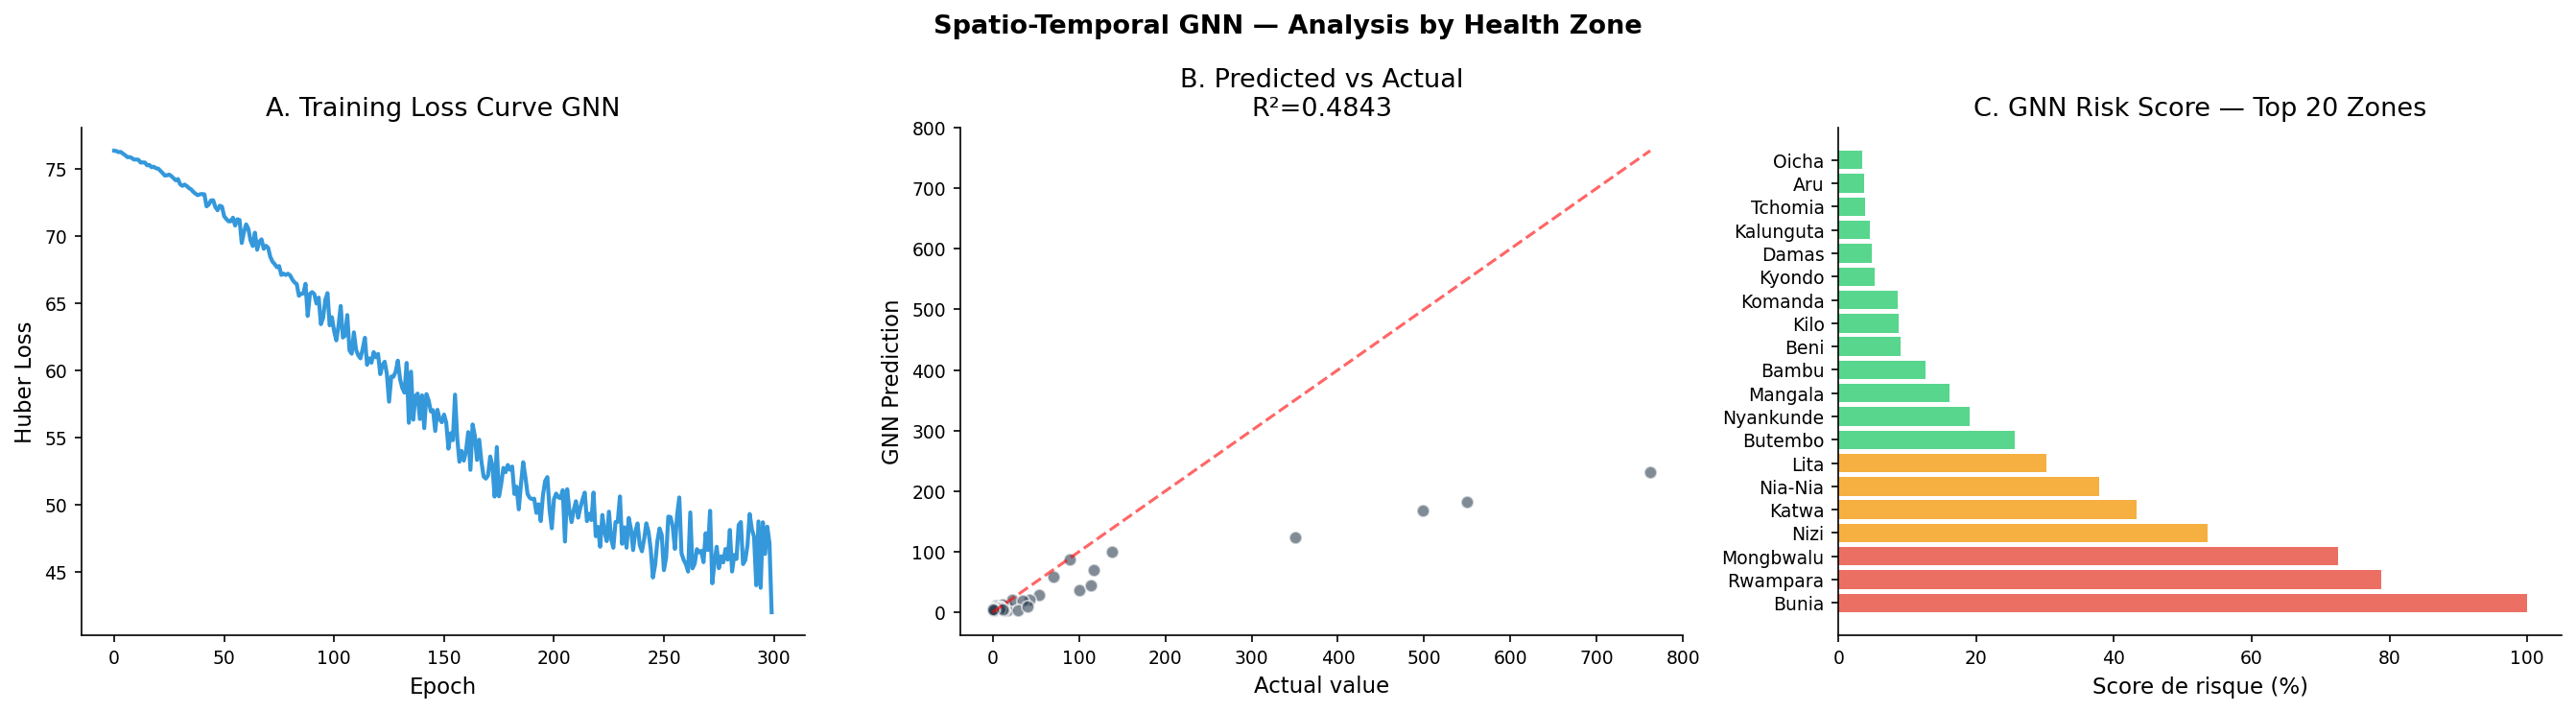

Saved: 06_gnn_results.png


In [25]:
# ── Visualisation graphe GNN ──────────────────────────────────────────
def plot_gnn_results(graph: GeoData, gnn_preds: np.ndarray,
                     zones: List[str], gnn_losses: List[float],
                     cfg: Config) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Spatio-Temporal GNN — Analysis by Health Zone",
                 fontsize=13, fontweight='bold')

    # A — Courbe de perte
    ax = axes[0]
    ax.plot(gnn_losses, color=PALETTE[2], lw=2)
    ax.set_title("A. Training Loss Curve GNN")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Huber Loss")

    # B — Prédit vs Réel
    ax = axes[1]
    yt = graph.y.numpy()
    ax.scatter(yt, gnn_preds, alpha=0.6, color=PALETTE[0], edgecolors='white', s=40)
    lim = max(yt.max(), gnn_preds.max())
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, alpha=0.6)
    ax.set_title(f"B. Predicted vs Actual\nR²={r2_score(yt, gnn_preds):.4f}")
    ax.set_xlabel("Actual value"); ax.set_ylabel("GNN Prediction")

    # C — Score de risque par zone (top 20)
    ax = axes[2]
    risk_scores = gnn_preds / (gnn_preds.max() + 1e-8) * 100
    top_idx     = np.argsort(risk_scores)[-20:][::-1]
    top_zones   = [zones[i] for i in top_idx]
    top_scores  = risk_scores[top_idx]
    colors_z    = [PALETTE[1] if s > 60 else PALETTE[4] if s > 30 else PALETTE[3]
                   for s in top_scores]
    ax.barh(top_zones, top_scores, color=colors_z, alpha=0.8)
    ax.set_title("C. GNN Risk Score — Top 20 Zones")
    ax.set_xlabel("Score de risque (%)")

    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "06_gnn_results.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: 06_gnn_results.png")


if GNN_AVAILABLE:
    plot_gnn_results(GNN_GRAPH, gnn_preds_all, GNN_ZONES, GNN_LOSSES, CFG)


## MODULE 9 · XAI — SHAP & LIME (Publication-Ready)

   TreeExplainer failed for RandomForest: Unsupported masker type: <class 'shap.utils._legacy.DenseData'>!
   RandomForest: KernelExplainer (kmeans bg, k=50)
   TreeExplainer failed for XGBoost: Unsupported masker type: <class 'shap.utils._legacy.DenseData'>!
   XGBoost: KernelExplainer (kmeans bg, k=50)
   TreeExplainer failed for LightGBM: Unsupported masker type: <class 'shap.utils._legacy.DenseData'>!
   LightGBM: KernelExplainer (kmeans bg, k=50)


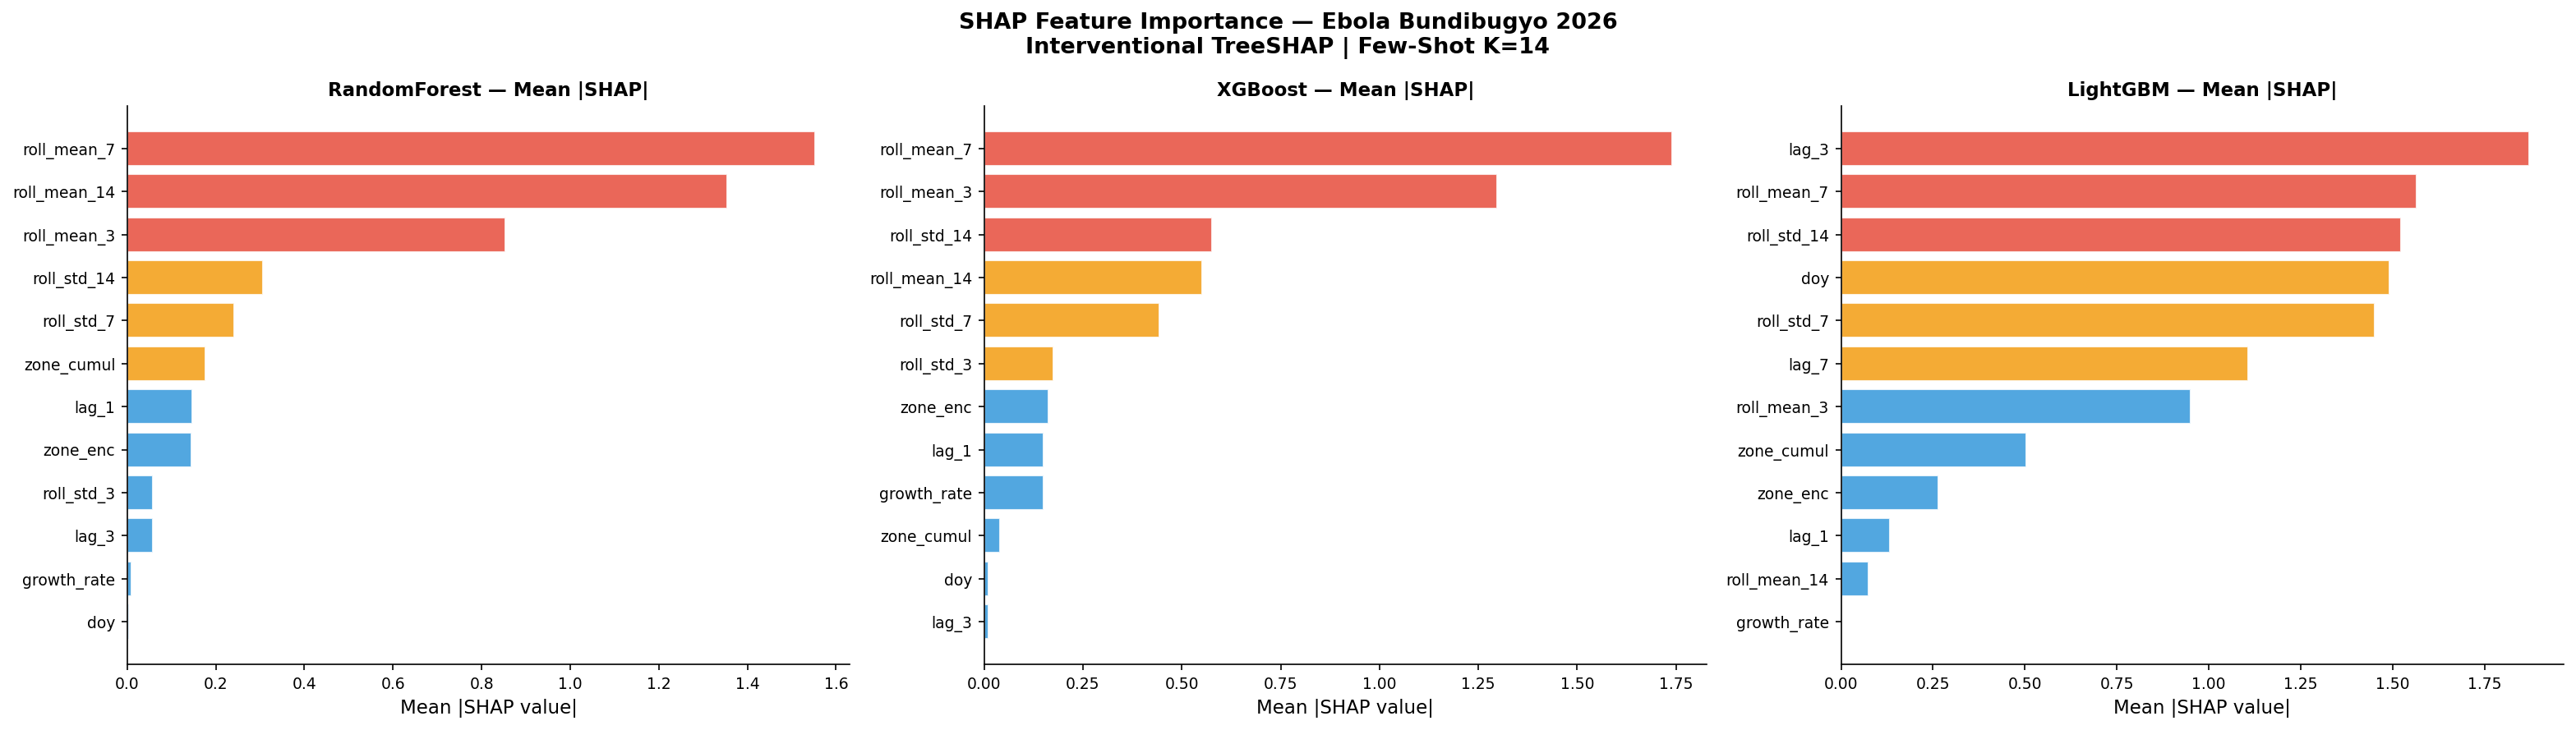

Saved: 07_shap_comparison.png (600 DPI)
   Spearman (RandomForest vs XGBoost): r=0.8531  p=0.0004
   Spearman (RandomForest vs LightGBM): r=0.1182  p=0.7293
   Spearman (XGBoost vs LightGBM): r=0.0455  p=0.8944


In [26]:
# ── SHAP Analysis ────────────────────────────────────────────────────
def run_shap_analysis(models: Dict, X_train: np.ndarray,
                      X_test: np.ndarray, feature_names: List[str],
                      cfg: Config) -> Dict:
    """
    Compute SHAP values for tree-based models.
    Strategy (in order of preference):
      1. shap.TreeExplainer(model, data=X_train) — exact, fast, no warnings.
      2. shap.KernelExplainer with shap.kmeans summary — avoids subsampling
         warning and is robust across model types.
    Publication-ready figure at 600 DPI.
    Cross-model Spearman rank correlation of feature importances.
    """
    shap_results = {}
    tree_models  = {k: v for k, v in models.items()
                    if k in ('RandomForest', 'XGBoost', 'LightGBM')}

    if not tree_models:
        print("Warning: no tree-based models available for SHAP")
        return shap_results

    n_cols = len(tree_models)
    fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, tree_models.items()):
        sv = None
        method_used = ""

        # ── Attempt 1: TreeExplainer with background data (positional) ──
        try:
            # Use a compact background (kmeans of train set) to keep memory low
            n_bg  = min(len(X_train), 100)
            bg    = shap.kmeans(X_train, n_bg)
            exp   = shap.TreeExplainer(model, bg)
            sv    = exp.shap_values(X_test)
            if isinstance(sv, list):
                sv = sv[0]
            method_used = f"TreeExplainer (kmeans bg, k={n_bg})"
        except Exception as e1:
            print(f"   TreeExplainer failed for {name}: {e1}")

        # ── Attempt 2: KernelExplainer with kmeans summary ───────────────
        if sv is None:
            try:
                n_bg  = min(len(X_train), 50)
                bg_km = shap.kmeans(X_train, n_bg)
                # Wrap predict to avoid LightGBM feature_names_in_ issue
                def _predict(x, m=model):
                    import numpy as _np
                    return m.predict(_np.array(x))
                exp2  = shap.KernelExplainer(_predict, bg_km)
                sv    = exp2.shap_values(X_test[:min(30, len(X_test))],
                                         silent=True)
                if isinstance(sv, list):
                    sv = sv[0]
                method_used = f"KernelExplainer (kmeans bg, k={n_bg})"
            except Exception as e2:
                msg = f"SHAP unavailable: {str(e2)[:60]}"
                ax.text(0.5, 0.5, msg, ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='gray')
                print(f"   ERROR SHAP {name}: {e2}")
                continue

        # ── Plot ─────────────────────────────────────────────────────────
        ms  = np.abs(sv).mean(axis=0)
        sdf = pd.DataFrame({'feature': feature_names[:len(ms)], 'mean_shap': ms})
        sdf = sdf.sort_values('mean_shap', ascending=True).tail(12)

        q75 = sdf['mean_shap'].quantile(0.75)
        q50 = sdf['mean_shap'].quantile(0.50)
        bar_colors = [
            PALETTE[1] if v > q75 else
            PALETTE[4] if v > q50 else PALETTE[2]
            for v in sdf['mean_shap']
        ]
        ax.barh(sdf['feature'], sdf['mean_shap'],
                color=bar_colors, alpha=0.85, edgecolor='white')
        ax.set_title(f"{name} — Mean |SHAP|", fontweight='bold', fontsize=11)
        ax.set_xlabel("Mean |SHAP value|")
        shap_results[name] = sdf
        print(f"   {name}: {method_used}")

    plt.suptitle(
        "SHAP Feature Importance — Ebola Bundibugyo 2026\n"
        "Interventional TreeSHAP | Few-Shot K=14",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "07_shap_comparison.png",
                dpi=600, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: 07_shap_comparison.png (600 DPI)")

    # Cross-model Spearman rank correlation
    names = list(shap_results.keys())
    if len(names) >= 2:
        for i in range(len(names) - 1):
            for j in range(i + 1, len(names)):
                n1, n2  = names[i], names[j]
                common  = set(shap_results[n1]['feature']) & set(shap_results[n2]['feature'])
                if len(common) >= 3:
                    v1 = shap_results[n1].set_index('feature').loc[list(common), 'mean_shap'].values
                    v2 = shap_results[n2].set_index('feature').loc[list(common), 'mean_shap'].values
                    r, p = stats.spearmanr(v1, v2)
                    print(f"   Spearman ({n1} vs {n2}): r={r:.4f}  p={p:.4f}")

    return shap_results


SHAP_RESULTS = run_shap_analysis(
    ALL_MODELS, X_TRAIN, X_TEST, FEATURE_COLS, CFG
)


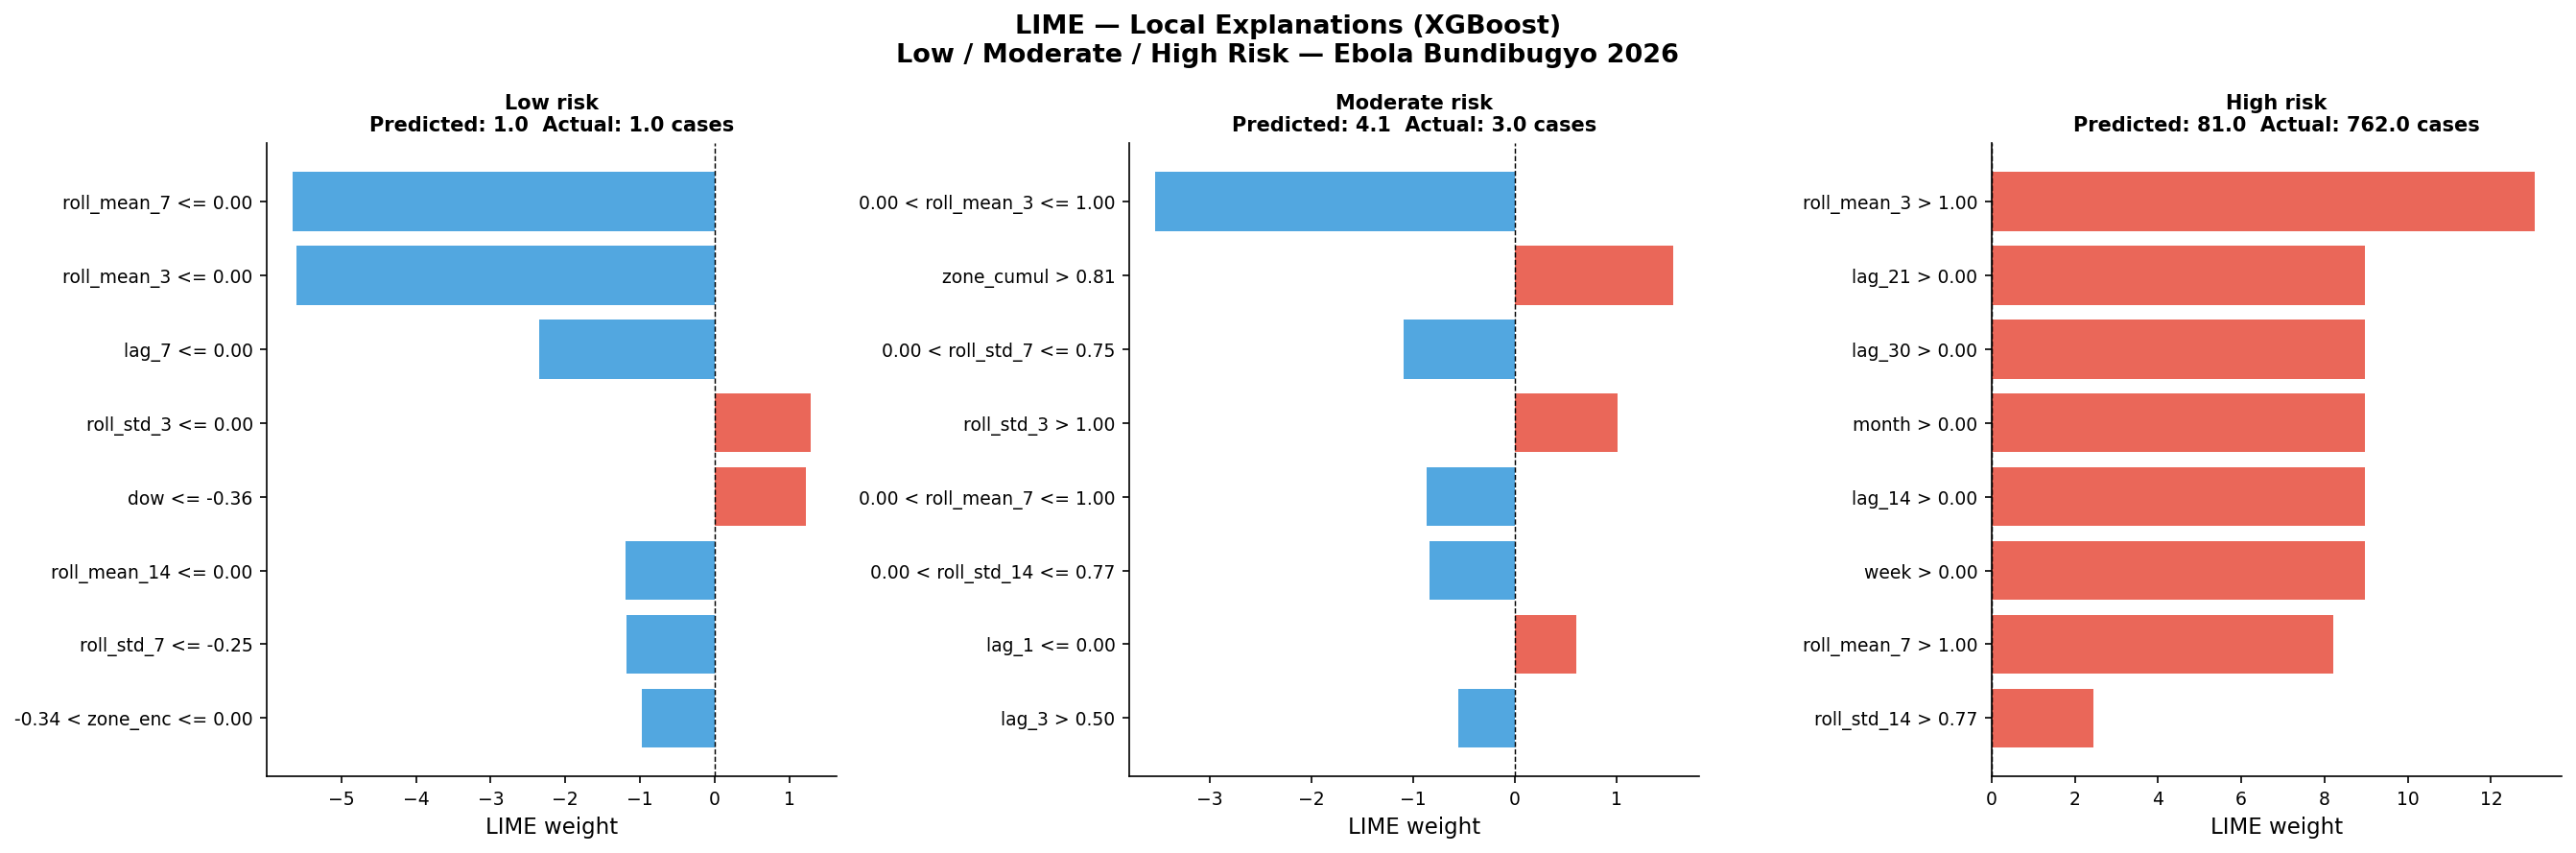

Saved: 08_lime_explanations.png

Top 5 features LIME (globale):
   roll_mean_3 > 1.00            : 13.0425
   lag_21 > 0.00                 : 8.9718
   lag_30 > 0.00                 : 8.9718
   lag_14 > 0.00                 : 8.9718
   month > 0.00                  : 8.9718


In [27]:
# ── LIME ─────────────────────────────────────────────────────────────
def run_lime_analysis(model, X_train: np.ndarray, X_test: np.ndarray,
                      y_test: np.ndarray, feature_names: List[str],
                      risk_thr: float, cfg: Config, model_name: str = 'XGBoost') -> None:
    """
    LIME sur 3 instances : bas / moyen / haut risque.
    """
    try:
        exp_lime = lime.lime_tabular.LimeTabularExplainer(
            training_data       = X_train,
            feature_names       = feature_names,
            mode                = 'regression',
            random_state        = cfg.SEED,
            discretize_continuous = True,
        )

        # Sélection des instances
        preds = np.clip(model.predict(X_test), 0, None)
        order = np.argsort(preds)
        n     = len(order)

        instances = {
            'Low risk':    order[0],
            'Moderate risk':  order[n // 2],
            'High risk':   order[-1],
        }

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"LIME — Local Explanations ({model_name})\n"
                     "Low / Moderate / High Risk — Ebola Bundibugyo 2026",
                     fontsize=13, fontweight='bold')

        lime_records = []
        for ax, (label, idx) in zip(axes, instances.items()):
            exp = exp_lime.explain_instance(
                X_test[idx], model.predict,
                num_features=8, num_samples=300
            )
            feat_imp = exp.as_list()
            feats    = [f[0][:28] + ('…' if len(f[0]) > 28 else '') for f in feat_imp]
            weights  = [f[1] for f in feat_imp]
            colors_l = [PALETTE[1] if w > 0 else PALETTE[2] for w in weights]

            bars = ax.barh(feats[::-1], weights[::-1], color=colors_l[::-1], alpha=0.85)
            ax.axvline(0, color='black', lw=0.7, ls='--')
            ax.set_title(
                f"{label}\n"
                f"Predicted: {preds[idx]:.1f}  Actual: {y_test[idx]:.1f} cases",
                fontweight='bold', fontsize=10
            )
            ax.set_xlabel("LIME weight")

            for f, w in feat_imp:
                lime_records.append({'label': label, 'feature': f[:25], 'weight': w, 'abs': abs(w)})

        plt.tight_layout()
        fig.savefig(cfg.FIG_DIR / "08_lime_explanations.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.show()
        print("Saved: 08_lime_explanations.png")

        # Tableau SHAP vs LIME
        lime_df = pd.DataFrame(lime_records)
        global_lime = lime_df.groupby('feature')['abs'].mean().sort_values(ascending=False)
        print("\nTop 5 features LIME (globale):")
        for feat, w in global_lime.head(5).items():
            print(f"   {feat:<30}: {w:.4f}")

        lime_df.to_csv(cfg.REPORT_DIR / "lime_explanations.csv", index=False)

    except Exception as e:
        print(f"❌ LIME: {e}")


best_tree = next((m for m in ['XGBoost', 'RandomForest', 'LightGBM'] if m in ALL_MODELS), None)
if best_tree:
    run_lime_analysis(
        ALL_MODELS[best_tree], X_TRAIN, X_TEST, Y_TEST,
        FEATURE_COLS, RISK_THR, CFG, model_name=best_tree
    )


## MODULE 10 · Final Evaluation & Dashboard Publication-Ready

In [28]:
# ── Results table ──────────────────────────────────────────────
RESULTS_DF = pd.DataFrame(ALL_RESULTS).dropna(subset=['R2'])
RESULTS_DF = RESULTS_DF.sort_values('R2', ascending=False).reset_index(drop=True)

print("=" * 90)
print("COMPLETE MODEL COMPARISON — Ebola Bundibugyo 2026")
print(f"Few-Shot K={CFG.N_SHOTS} weeks | Risk threshold: {RISK_THR:.1f} cases")
print("=" * 90)
display_cols = ['Model','RMSE','MAE','MAPE','R2','Accuracy','Precision','Recall','F1','AUC']
display_cols = [c for c in display_cols if c in RESULTS_DF.columns]
print(RESULTS_DF[display_cols].to_string(index=False))

if len(RESULTS_DF):
    best = RESULTS_DF.iloc[0]
    print(f"\n🏆 Best model: {best['Model']}  R²={best['R2']:.4f}  RMSE={best['RMSE']:.4f}")


COMPLETE MODEL COMPARISON — Ebola Bundibugyo 2026
Few-Shot K=14 weeks | Risk threshold: 9.0 cases
           Model     RMSE     MAE   MAPE      R2  Accuracy  Precision  Recall     F1    AUC
           Ridge  62.8868 20.0600  75.35  0.5482    0.8802     0.7350  1.0000 0.8472 0.9953
LinearRegression  62.9938 19.7307  61.39  0.5467    0.8981     0.7653  1.0000 0.8670 0.9956
   GNN-GraphSAGE 102.1485 34.4370 106.85  0.4843    0.8596     0.9412  0.6957 0.8000 0.8223
         XGBoost  79.4776 21.7065  15.79  0.2784    0.9666     0.9216  0.9833 0.9514 0.9984
    RandomForest  79.9764 22.2172  18.68  0.2693    0.9364     0.8469  0.9870 0.9116 0.9968
        LightGBM  88.5699 28.1232  64.27  0.1038    0.8882     0.7525  0.9888 0.8546 0.9949
            LSTM  94.8797 32.7356  73.88 -0.0284    0.8623     0.9730  0.6022 0.7440 0.9628
         TL-LSTM  95.2843 33.4122  92.12 -0.0332    0.8548     0.9600  0.5854 0.7273 0.9498
     Transformer 100.2921 36.5349  83.90 -0.1491    0.6788     1.0000  0.0

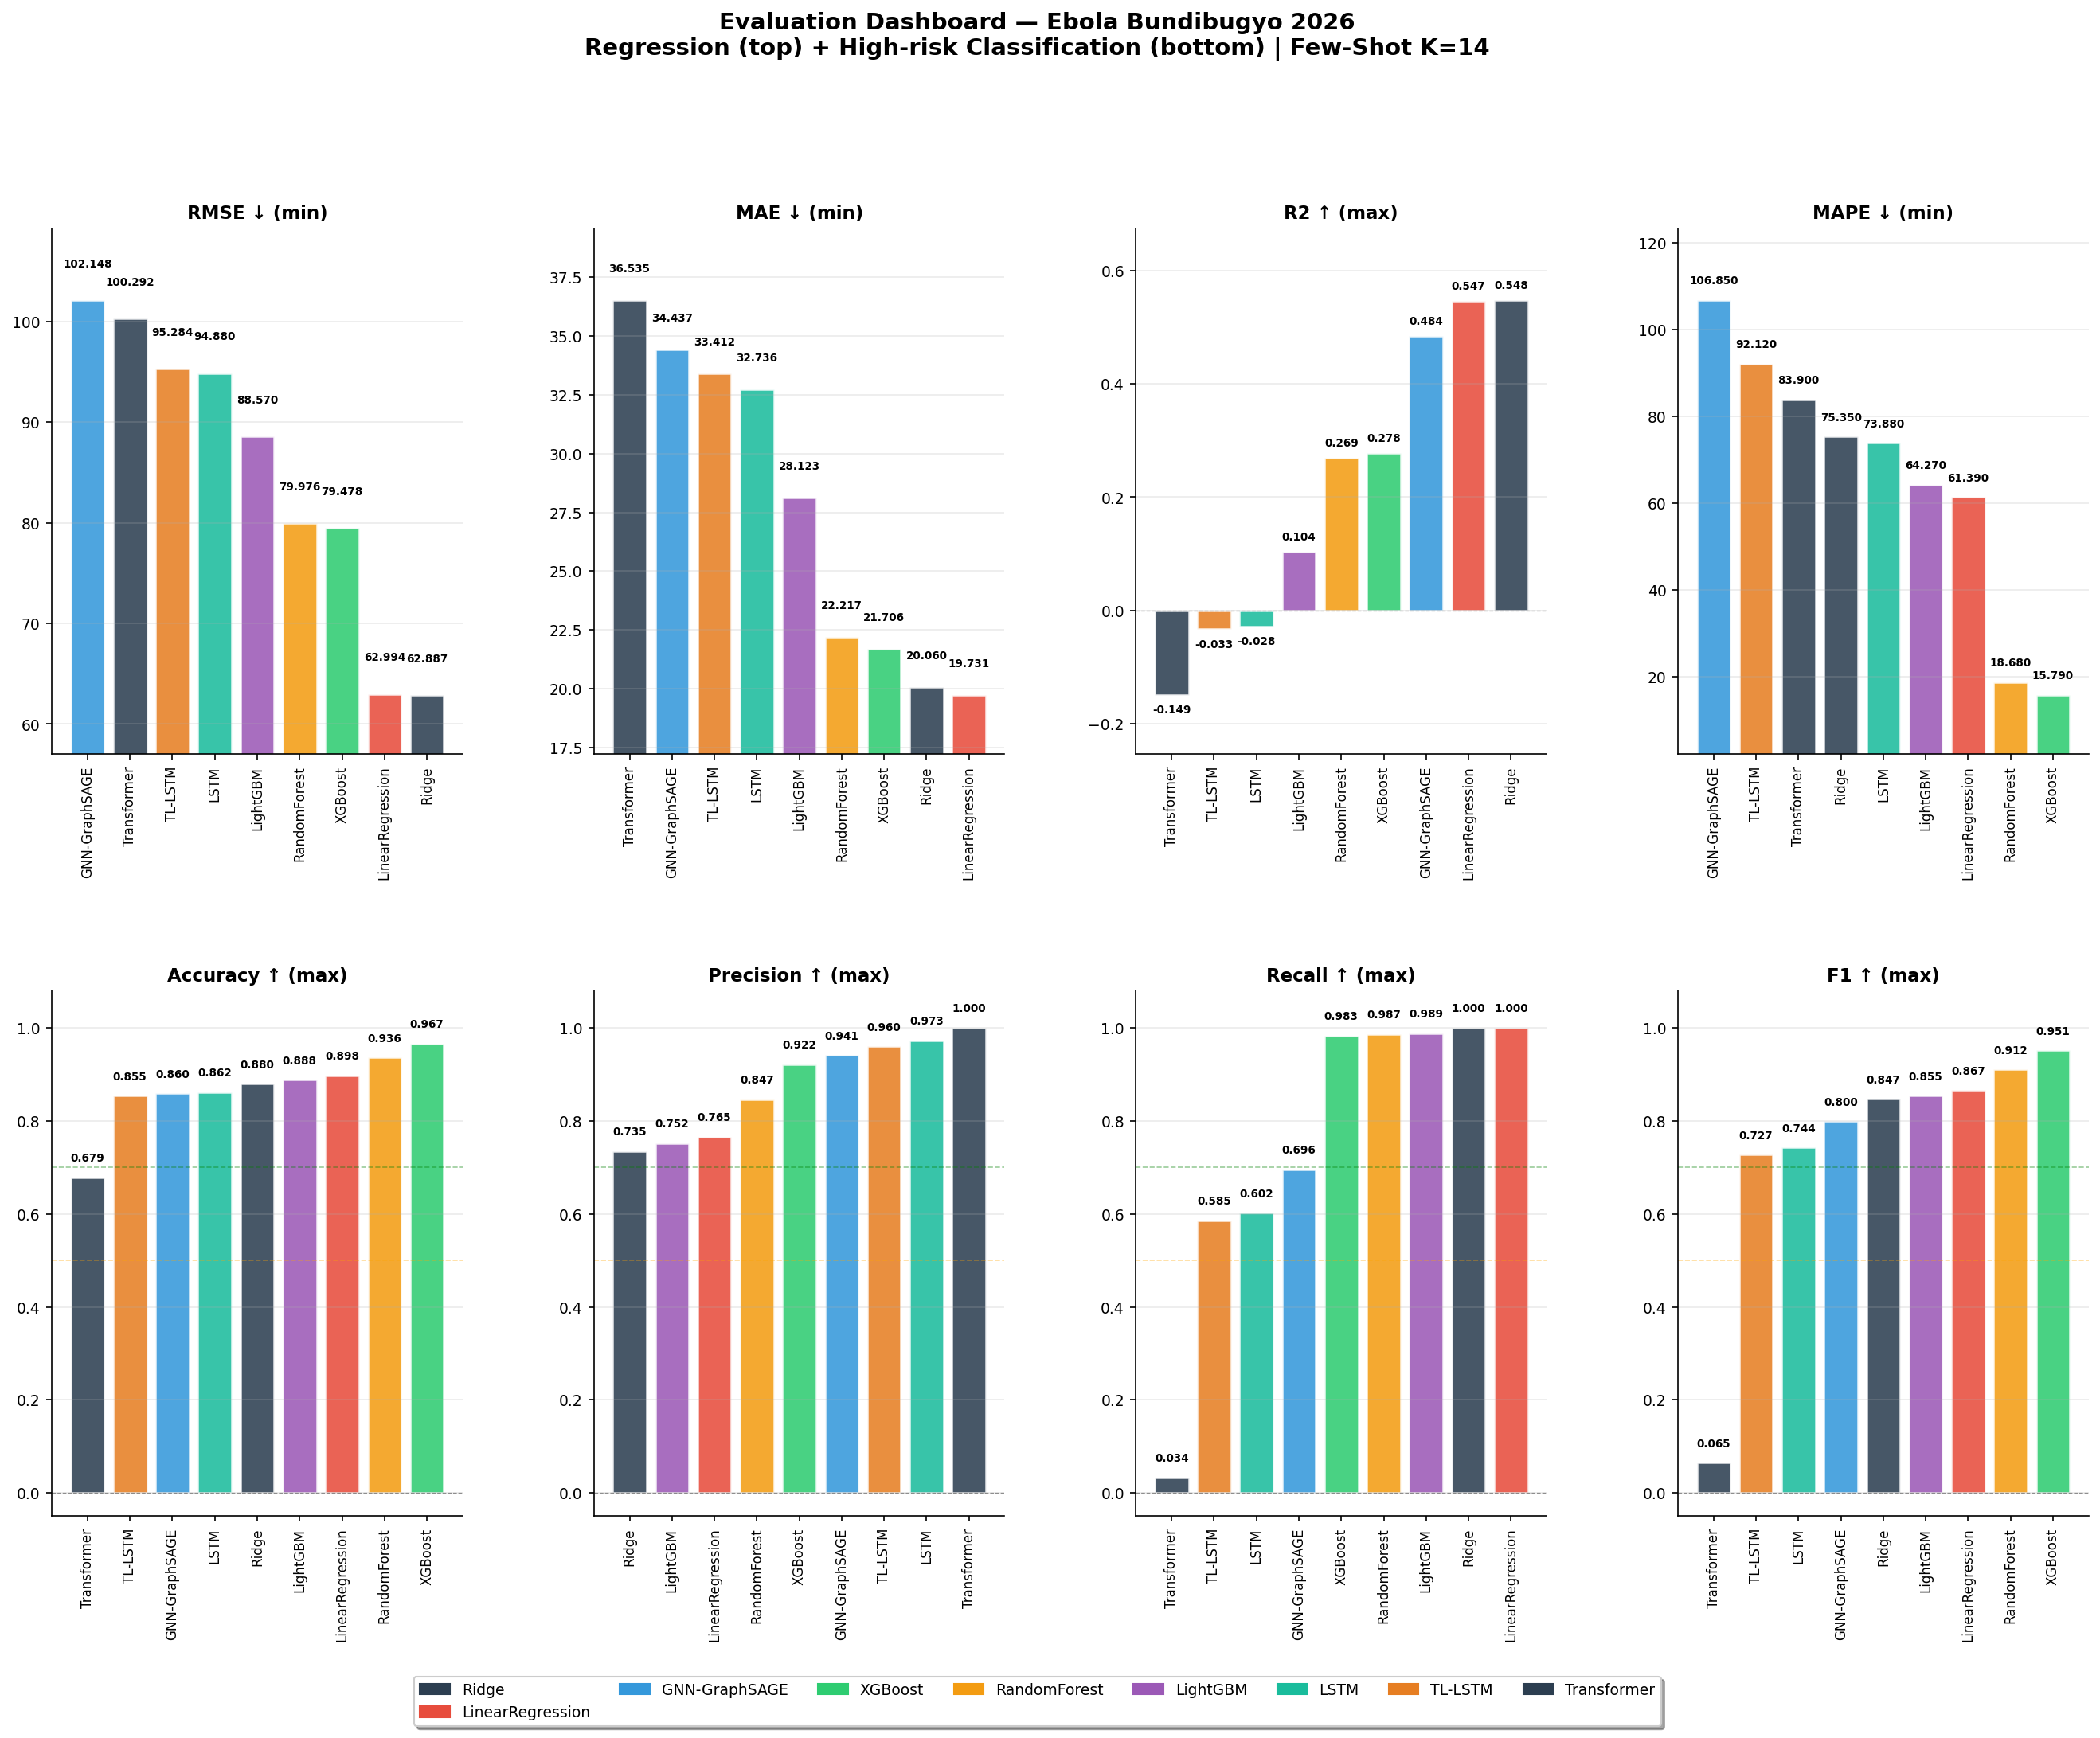

Saved: 09_complete_dashboard.png


In [29]:
# ── 8-panel dashboard ──────────────────────────────────────────────
def plot_complete_dashboard(results_df: pd.DataFrame,
                             all_preds: Dict, y_test: np.ndarray,
                             cfg: Config) -> None:
    """Dashboard publication-ready 2×4 panneaux."""
    MODEL_COLORS_MAP = {
        name: PALETTE[i % len(PALETTE)]
        for i, name in enumerate(results_df['Model'])
    }

    fig = plt.figure(figsize=(22, 14))
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.32)

    METRICS_TOP = ['RMSE', 'MAE', 'R2', 'MAPE']
    METRICS_BOT = ['Accuracy', 'Precision', 'Recall', 'F1']
    LOWER_BETTER = {'RMSE', 'MAE', 'MAPE', 'SMAPE', 'RMSLE'}

    def _plot_metric(ax, metric, row):
        sub = results_df.dropna(subset=[metric]).copy()
        if sub.empty:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metric, fontweight='bold')
            return
        asc = metric in LOWER_BETTER
        sub = sub.sort_values(metric, ascending=not asc)
        colors_b = [MODEL_COLORS_MAP.get(m, '#95A5A6') for m in sub['Model']]
        bars = ax.bar(range(len(sub)), sub[metric], color=colors_b, edgecolor='white', lw=1.2, alpha=0.87)
        ax.set_xticks(range(len(sub)))
        #ax.set_xticklabels([m.replace(' ', '\n')[:14] for m in sub['Model']],
                           #fontsize=7.5, rotation=0, ha='center')
        ax.set_xticklabels([m for m in sub['Model']],fontsize=8,
                            rotation=90,      # Texte vertical
                            ha='center',
                            va='top')
        ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.4)
        mx = sub[metric].abs().max()
        for bar, v in zip(bars, sub[metric]):
            sign = 1 if bar.get_height() >= 0 else -1
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + sign * mx * 0.03,
                    f'{v:.3f}', ha='center', va='bottom' if sign > 0 else 'top',
                    fontsize=6.5, fontweight='bold')
        suffix = '↓ (min)' if asc else '↑ (max)'
        ax.set_title(f"{metric} {suffix}", fontweight='bold', fontsize=11)
        ax.grid(True, alpha=0.25, axis='y')
        if not sub.empty:
            span = sub[metric].max() - sub[metric].min()
            ax.set_ylim(sub[metric].min() - span * 0.15, sub[metric].max() + span * 0.18)

    for col, m in enumerate(METRICS_TOP):
        _plot_metric(fig.add_subplot(gs[0, col]), m, 0)
    for col, m in enumerate(METRICS_BOT):
        ax = fig.add_subplot(gs[1, col])
        _plot_metric(ax, m, 1)
        ax.axhline(0.5, color='orange', lw=0.8, ls='--', alpha=0.4)
        ax.axhline(0.7, color='green',  lw=0.8, ls='--', alpha=0.4)
        ax.set_ylim(-0.05, 1.08)

    # Legend globale
    patches = [Patch(color=c, label=m) for m, c in MODEL_COLORS_MAP.items()]
    fig.legend(handles=patches, loc='lower center', ncol=min(8, len(patches)),
               fontsize=9, bbox_to_anchor=(0.5, -0.02),
               frameon=True, fancybox=True, shadow=True)

    fig.suptitle("Evaluation Dashboard — Ebola Bundibugyo 2026\n"
                 "Regression (top) + High-risk Classification (bottom) | Few-Shot K=14",
                 fontweight='bold', fontsize=14, y=1.01)

    fig.savefig(cfg.FIG_DIR / "09_complete_dashboard.png",
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: 09_complete_dashboard.png")


if len(RESULTS_DF):
    plot_complete_dashboard(RESULTS_DF, ALL_PREDS, Y_TEST, CFG)


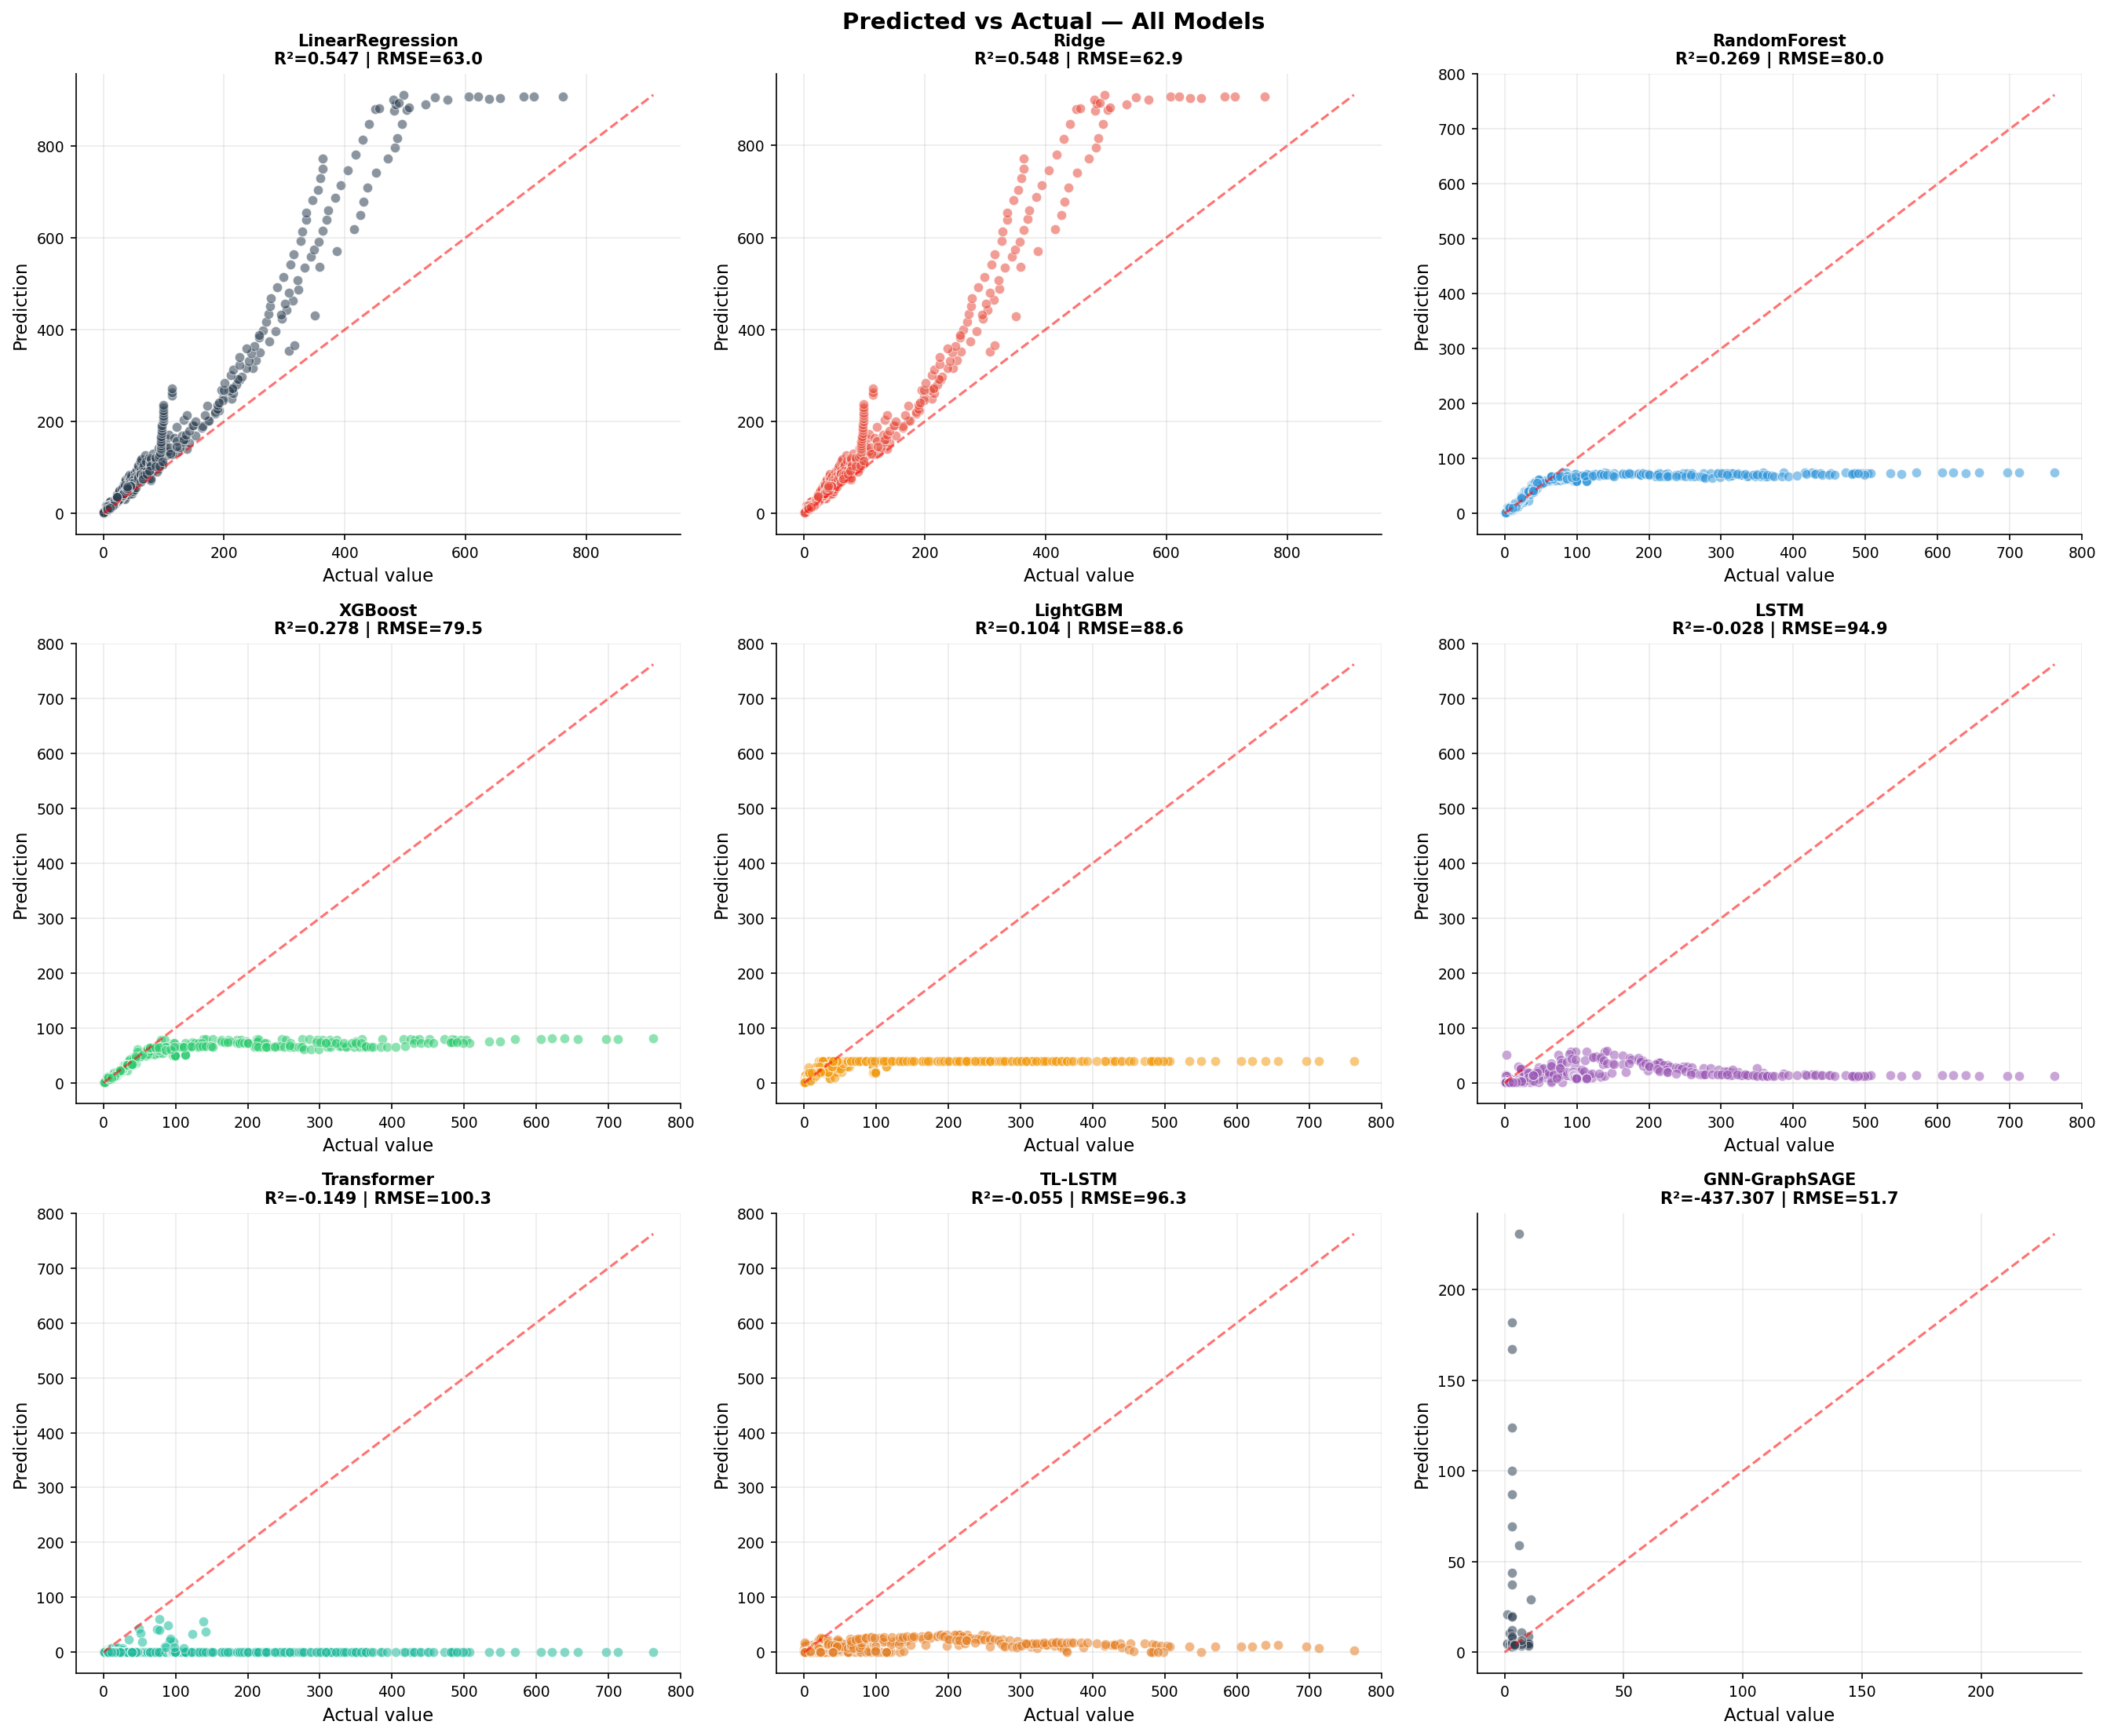

Saved: 10_pred_vs_actual.png


In [30]:
# ── Prédit vs Réel — tous modèles ────────────────────────────────────
def plot_pred_vs_actual(all_preds: Dict, y_test: np.ndarray,
                        cfg: Config) -> None:
    n  = len(all_preds)
    nc = min(3, n)
    nr = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(6 * nc, 5 * nr))
    axes = np.array(axes).flatten() if n > 1 else [axes]

    for ax, (name, preds) in zip(axes, all_preds.items()):
        mn  = min(len(preds), len(y_test))
        yt  = y_test[:mn]
        yp  = np.clip(preds[:mn], 0, None)
        r2v = r2_score(yt, yp)
        rmse= np.sqrt(mean_squared_error(yt, yp))
        ax.scatter(yt, yp, alpha=0.55, s=35,
                   color=PALETTE[list(all_preds.keys()).index(name) % len(PALETTE)],
                   edgecolors='white', lw=0.5)
        lim = max(yt.max(), yp.max()) if len(yt) else 1
        ax.plot([0, lim], [0, lim], 'r--', lw=1.5, alpha=0.55)
        ax.set_title(f"{name}\nR²={r2v:.3f} | RMSE={rmse:.1f}",
                     fontweight='bold', fontsize=10)
        ax.set_xlabel("Actual value"); ax.set_ylabel("Prediction")
        ax.grid(True, alpha=0.25)

    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle("Predicted vs Actual — All Models",
                 fontweight='bold', fontsize=14)
    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "10_pred_vs_actual.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: 10_pred_vs_actual.png")


plot_pred_vs_actual(ALL_PREDS, Y_TEST, CFG)


In [31]:
# ── Time-series cross-validation ───────────────────────────────────────
def run_timeseries_cv(models_dict: Dict, X: np.ndarray, y: np.ndarray,
                      cfg: Config, risk_thr: float) -> pd.DataFrame:
    """TimeSeriesSplit sur les modèles classiques."""
    tscv     = TimeSeriesSplit(n_splits=cfg.N_CV_FOLDS)
    cv_recs  = []
    tree_models = {k: v for k, v in models_dict.items()
                   if k not in ('LSTM', 'Transformer', 'TL-LSTM', 'GNN-GraphSAGE')}

    print("── Time-series cross-validation ─────────────────────────────────────")
    for name, model in tree_models.items():
        fold_rmse, fold_r2 = [], []
        for fold, (tr, te) in enumerate(tscv.split(X)):
            try:
                model.fit(X[tr], y[tr])
                p = np.clip(model.predict(X[te]), 0, None)
                fold_rmse.append(np.sqrt(mean_squared_error(y[te], p)))
                fold_r2.append(r2_score(y[te], p))
            except Exception:
                pass
        if fold_rmse:
            cv_recs.append({
                'Model':       name,
                'RMSE_mean':   round(np.mean(fold_rmse), 4),
                'RMSE_std':    round(np.std(fold_rmse), 4),
                'R2_mean':     round(np.mean(fold_r2), 4),
                'R2_std':      round(np.std(fold_r2), 4),
            })
            print(f"   {name:20s}  RMSE={np.mean(fold_rmse):.4f}±{np.std(fold_rmse):.4f}  "
                  f"R²={np.mean(fold_r2):.4f}±{np.std(fold_r2):.4f}")

    return pd.DataFrame(cv_recs)


if not DF_FEAT.empty:
    CV_RESULTS = run_timeseries_cv(ALL_MODELS, X_TRAIN, Y_TRAIN, CFG, RISK_THR)


── Time-series cross-validation ─────────────────────────────────────
   LinearRegression      RMSE=1.6947±1.5206  R²=0.9087±0.0832
   Ridge                 RMSE=1.5722±1.3584  R²=0.9344±0.0473
   RandomForest          RMSE=2.0765±1.6814  R²=0.9102±0.0328
   XGBoost               RMSE=2.0631±1.6908  R²=0.9284±0.0237
   LightGBM              RMSE=8.7871±2.7051  R²=-21.1343±31.0070


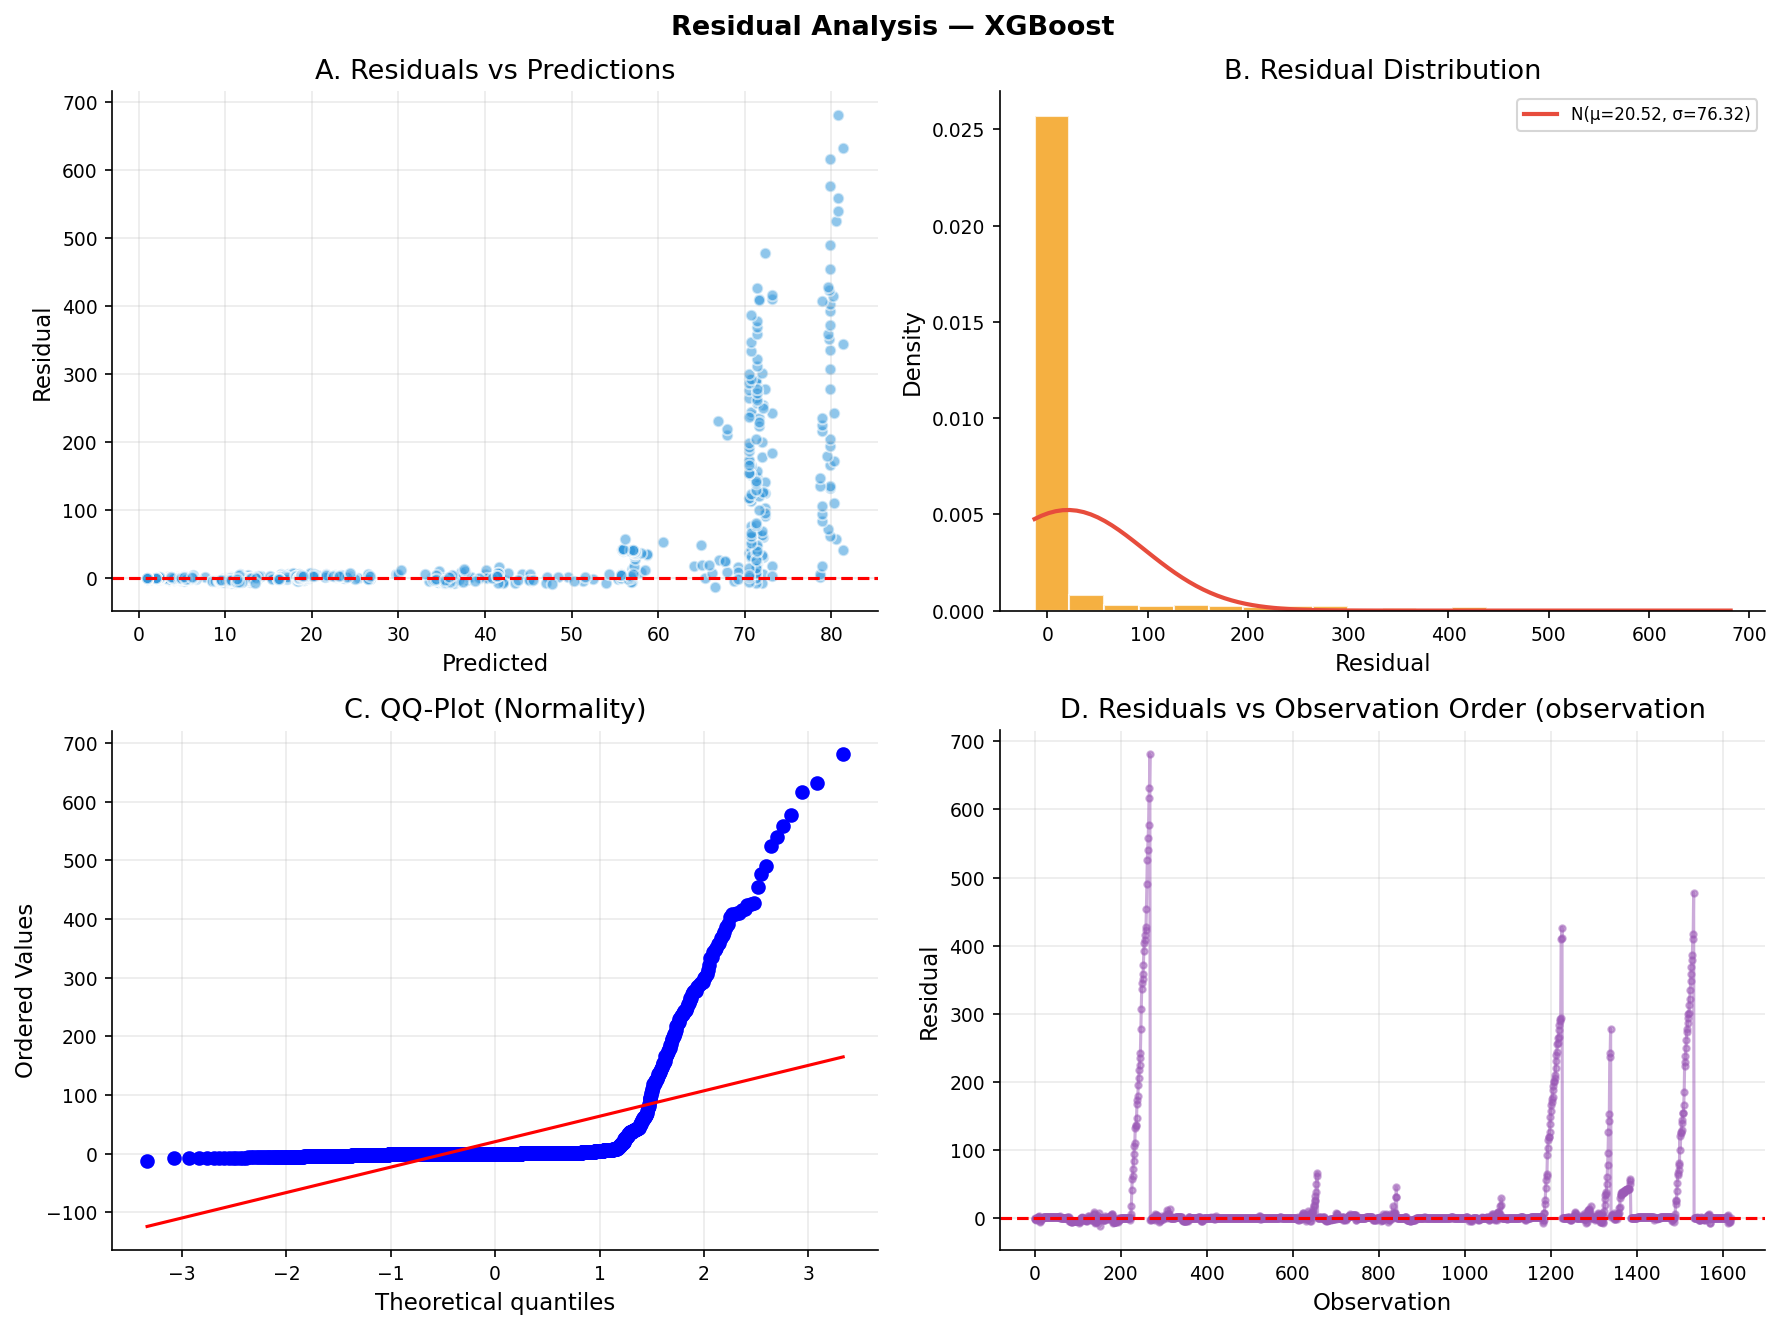

   Shapiro-Wilk: stat=0.3228  p=0.0000  (Non-normal)
   Biais moyen: 20.5167  MAE: 21.7195


In [32]:
# ── Residual Analysis ───────────────────────────────────────────────
def plot_residual_analysis(model, X_test: np.ndarray, y_test: np.ndarray,
                           name: str, cfg: Config) -> None:
    preds     = np.clip(model.predict(X_test), 0, None)
    mn        = min(len(preds), len(y_test))
    residuals = y_test[:mn] - preds[:mn]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Residual Analysis — {name}", fontweight='bold', fontsize=13)

    # A — Résidus vs Prédit
    ax = axes[0, 0]
    ax.scatter(preds[:mn], residuals, alpha=0.55, color=PALETTE[2], edgecolors='white', s=30)
    ax.axhline(0, color='red', ls='--', lw=1.5)
    ax.set_title("A. Residuals vs Predictions"); ax.set_xlabel("Predicted"); ax.set_ylabel("Residual")
    ax.grid(True, alpha=0.25)

    # B — Histogramme résidus
    ax = axes[0, 1]
    mu, std = residuals.mean(), residuals.std()
    ax.hist(residuals, bins=min(20, mn), color=PALETTE[4], edgecolor='white', alpha=0.8, density=True)
    xs = np.linspace(residuals.min(), residuals.max(), 100)
    ax.plot(xs, stats.norm.pdf(xs, mu, std), color=PALETTE[1], lw=2,
            label=f"N(μ={mu:.2f}, σ={std:.2f})")
    ax.set_title("B. Residual Distribution"); ax.set_xlabel("Residual"); ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # C — QQ-plot
    ax = axes[1, 0]
    stats.probplot(residuals, dist='norm', plot=ax)
    ax.set_title("C. QQ-Plot (Normality)")
    ax.grid(True, alpha=0.25)

    # D — Résidus vs Ordre
    ax = axes[1, 1]
    ax.plot(residuals, 'o-', color=PALETTE[5], alpha=0.5, markersize=3)
    ax.axhline(0, color='red', ls='--', lw=1.5)
    ax.set_title("D. Residuals vs Observation Order (observation")
    ax.set_xlabel("Observation"); ax.set_ylabel("Residual")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    fig.savefig(
    cfg.FIG_DIR / f"11_residuals_{name.replace(' ', '_')}.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none",
    )
    #fig.savefig(cfg.FIG_DIR / f"11_residuals_{name.replace(' ', '_', facecolor='white', edgecolor='none')}.png",
                #dpi=600, bbox_inches='tight')
    plt.show()

    # Statistical tests
    sw_stat, sw_p = stats.shapiro(residuals)
    bias = residuals.mean()
    print(f"   Shapiro-Wilk: stat={sw_stat:.4f}  p={sw_p:.4f}  "
          f"({'Normal' if sw_p > 0.05 else 'Non-normal'})")
    print(f"   Biais moyen: {bias:.4f}  MAE: {np.abs(residuals).mean():.4f}")


if best_tree and best_tree in ALL_MODELS:
    plot_residual_analysis(ALL_MODELS[best_tree], X_TEST, Y_TEST, best_tree, CFG)



── Probabilistic Forecast — XGBoost ──────────────────────────────
   Moyenne    : 11.5 cas/sem
   Médiane    : 11.4 cas/sem
   IC 95%     : [9.5, 14.8]


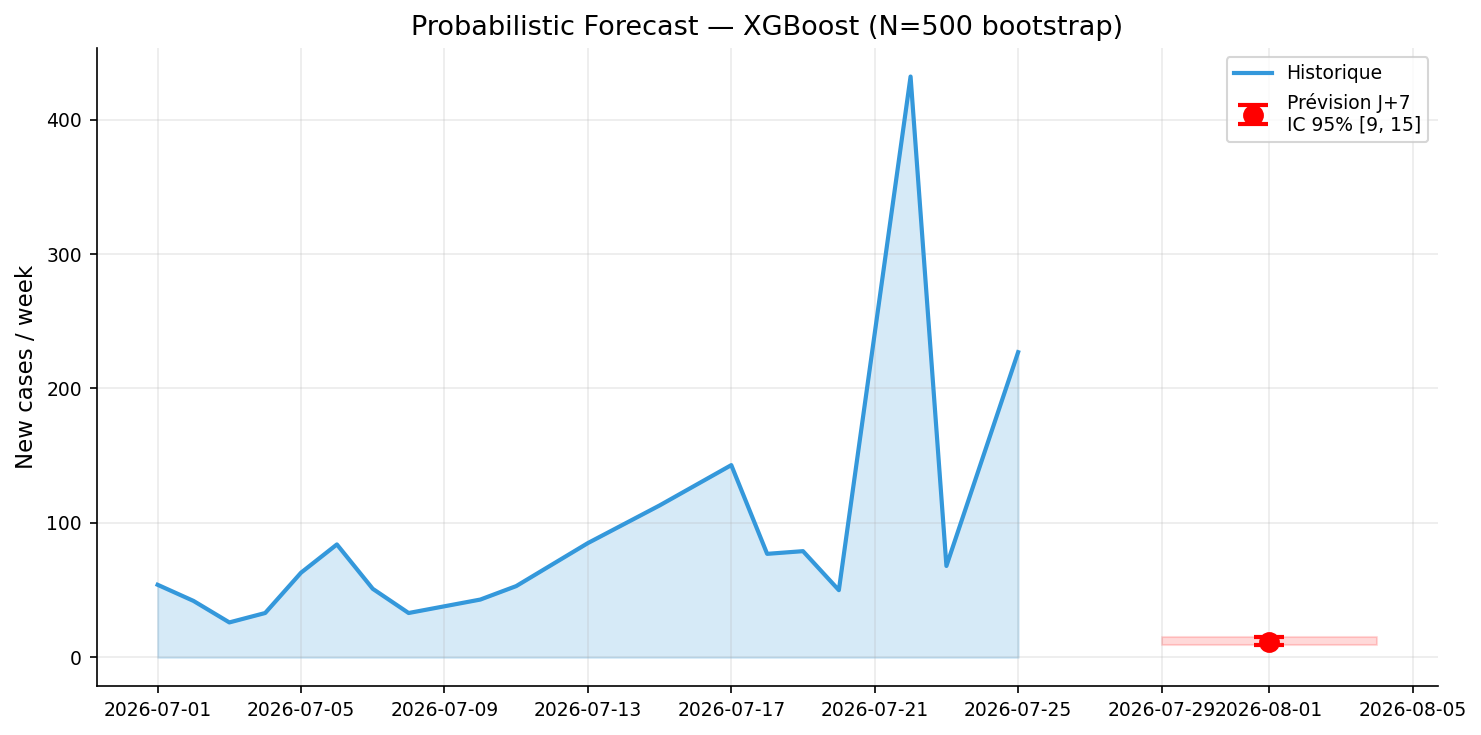

✅ Figure 12_probabilistic_forecast.png


In [33]:
# ── Probabilistic Forecast (bootstrap) ───────────────────────────────
def probabilistic_forecast(
    model, X_train: np.ndarray, y_train: np.ndarray,
    X_test: np.ndarray, y_test: np.ndarray,
    nat_df: Optional[pd.DataFrame], name: str,
    cfg: Config
) -> Dict:
    """Prévision avec IC 95% par bootstrap résiduel."""

    residuals = y_train - np.clip(model.predict(X_train), 0, None)
    boot_preds = []
    for _ in range(cfg.N_BOOTSTRAP):
        boot_res  = np.random.choice(residuals, replace=True)
        boot_pred = float(np.clip(model.predict(X_test[-1:])[0] + boot_res, 0, None))
        boot_preds.append(boot_pred)

    boot_arr  = np.array(boot_preds)
    fc_mean   = boot_arr.mean()
    fc_median = np.median(boot_arr)
    fc_lower  = np.percentile(boot_arr, 2.5)
    fc_upper  = np.percentile(boot_arr, 97.5)

    print(f"\n── Probabilistic Forecast — {name} ──────────────────────────────")
    print(f"   Moyenne    : {fc_mean:.1f} cas/sem")
    print(f"   Médiane    : {fc_median:.1f} cas/sem")
    print(f"   IC 95%     : [{fc_lower:.1f}, {fc_upper:.1f}]")

    # Visualisation
    fig, ax = plt.subplots(figsize=(10, 5))
    if nat_df is not None and len(nat_df):
        tail = nat_df.tail(min(20, len(nat_df)))
        ax.fill_between(tail['date'], 0, tail['new_cases'], alpha=0.2, color=PALETTE[2])
        ax.plot(tail['date'], tail['new_cases'], color=PALETTE[2], lw=2, label="Historique")
        fc_date = nat_df['date'].max() + timedelta(days=7)
    else:
        fc_date = datetime.now() + timedelta(days=7)

    ax.errorbar(fc_date, fc_mean,
                yerr=[[fc_mean - fc_lower], [fc_upper - fc_mean]],
                fmt='ro', markersize=9, capsize=7, capthick=2,
                label=f'Prévision J+7\nIC 95% [{fc_lower:.0f}, {fc_upper:.0f}]')
    ax.fill_between([fc_date - timedelta(days=3), fc_date + timedelta(days=3)],
                    fc_lower, fc_upper, color='red', alpha=0.15)
    ax.set_title(f"Probabilistic Forecast — {name} (N={cfg.N_BOOTSTRAP} bootstrap)")
    ax.set_ylabel("New cases / week")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    fig.savefig(cfg.FIG_DIR / "12_probabilistic_forecast.png", dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()
    print("✅ Figure 12_probabilistic_forecast.png")

    return {'mean': fc_mean, 'median': fc_median, 'lower': fc_lower, 'upper': fc_upper}


if best_tree and best_tree in ALL_MODELS:
    FORECAST = probabilistic_forecast(
        ALL_MODELS[best_tree], X_TRAIN, Y_TRAIN,
        X_TEST, Y_TEST, NAT, best_tree, CFG
    )


## MODULE 11 · Export Report & Résultats Publication-Ready

In [34]:
# ── LaTeX table ───────────────────────────────────────────────────────
def export_latex_table(results_df: pd.DataFrame, cfg: Config) -> str:
    """Génère une table LaTeX booktabs."""
    cols = ['RMSE', 'MAE', 'R2', 'Accuracy', 'F1', 'AUC']
    cols = [c for c in cols if c in results_df.columns]

    lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\caption{Model Comparison — Outbreak Forecasting — Épidémie Ebola Bundibugyo 2026}",
        r"\label{tab:model_comparison}",
        r"\begin{tabular}{l" + "r" * len(cols) + "}",
        r"\toprule",
        "\\textbf{Modèle} & " + " & ".join(f"\\textbf{{{c}}}" for c in cols) + " \\\\",
        r"\midrule",
    ]
    best_row = results_df.iloc[0] if len(results_df) else None
    for _, row in results_df.iterrows():
        vals = []
        for c in cols:
            v = row.get(c, None)
            if pd.isna(v):
                vals.append("—")
            else:
                fmtv = f"{v:.4f}"
                if best_row is not None and c in ('R2', 'Accuracy', 'F1', 'AUC'):
                    if v == results_df[c].max():
                        fmtv = f"\\textbf{{{fmtv}}}"
                elif best_row is not None and c in ('RMSE', 'MAE', 'MAPE'):
                    if v == results_df[c].min():
                        fmtv = f"\\textbf{{{fmtv}}}"
                vals.append(fmtv)
        lines.append(row['Model'] + " & " + " & ".join(vals) + " \\\\")

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    latex = "\n".join(lines)

    out_path = cfg.REPORT_DIR / "table_results.tex"
    out_path.write_text(latex, encoding='utf-8')
    print(f"LaTeX table saved: {out_path}")
    return latex


LATEX_TABLE = export_latex_table(RESULTS_DF, CFG)
print(LATEX_TABLE)


LaTeX table saved: outputs\reports\table_results.tex
\begin{table}[htbp]
\centering
\caption{Model Comparison — Outbreak Forecasting — Épidémie Ebola Bundibugyo 2026}
\label{tab:model_comparison}
\begin{tabular}{lrrrrrr}
\toprule
\textbf{Modèle} & \textbf{RMSE} & \textbf{MAE} & \textbf{R2} & \textbf{Accuracy} & \textbf{F1} & \textbf{AUC} \\
\midrule
Ridge & \textbf{62.8868} & 20.0600 & \textbf{0.5482} & 0.8802 & 0.8472 & 0.9953 \\
LinearRegression & 62.9938 & \textbf{19.7307} & 0.5467 & 0.8981 & 0.8670 & 0.9956 \\
GNN-GraphSAGE & 102.1485 & 34.4370 & 0.4843 & 0.8596 & 0.8000 & 0.8223 \\
XGBoost & 79.4776 & 21.7065 & 0.2784 & \textbf{0.9666} & \textbf{0.9514} & \textbf{0.9984} \\
RandomForest & 79.9764 & 22.2172 & 0.2693 & 0.9364 & 0.9116 & 0.9968 \\
LightGBM & 88.5699 & 28.1232 & 0.1038 & 0.8882 & 0.8546 & 0.9949 \\
LSTM & 94.8797 & 32.7356 & -0.0284 & 0.8623 & 0.7440 & 0.9628 \\
TL-LSTM & 95.2843 & 33.4122 & -0.0332 & 0.8548 & 0.7273 & 0.9498 \\
Transformer & 100.2921 & 36.5349 & -0.1

In [35]:
# ── Report JSON complet ──────────────────────────────────────────────
def export_full_report(
    results_df: pd.DataFrame, cfg: Config,
    cv_results: Optional[pd.DataFrame] = None,
    forecast: Optional[Dict] = None,
    stat_results: Optional[Dict] = None,
) -> Dict:
    """Exporte un rapport JSON structuré."""

    best = results_df.iloc[0].to_dict() if len(results_df) else {}

    report = {
        "title":    "Transfer & Few-Shot Learning — Ebola Bundibugyo Outbreak 2026",
        "date":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "version":  "2.0-retravaill",
        "source":   "INRB-UMIE BDBV2026-Data",
        "config": {
            "n_shots":     cfg.N_SHOTS,
            "test_ratio":  cfg.TEST_RATIO,
            "risk_pctile": cfg.RISK_PCTILE,
            "risk_thr":    round(RISK_THR, 2),
            "seq_len":     cfg.SEQ_LEN,
        },
        "best_model": {
            "name":  best.get('Model', 'N/A'),
            "RMSE":  best.get('RMSE', None),
            "MAE":   best.get('MAE', None),
            "R2":    best.get('R2', None),
            "F1":    best.get('F1', None),
            "AUC":   best.get('AUC', None),
        },
        "model_ranking": [
            {k: (None if isinstance(v, float) and np.isnan(v) else v)
             for k, v in row.items()}
            for row in results_df.to_dict('records')
        ],
        "statistical_tests": stat_results or {},
        "cv_results":  cv_results.to_dict('records') if cv_results is not None and len(cv_results) else [],
        "forecast":    forecast or {},
        "figures":     [f.name for f in CFG.FIG_DIR.glob("*.png")],
        "historical_outbreaks": list(cfg.HISTORICAL_OUTBREAKS.keys()),
        "gnn_available":       GNN_AVAILABLE,
    }

    # Save output
    rpath = cfg.REPORT_DIR / "complete_report.json"
    with rpath.open('w', encoding='utf-8') as f:
        json.dump(report, f, indent=2, ensure_ascii=False, default=str)

    print(f"✅ Report JSON: {rpath}")
    return report


REPORT = export_full_report(
    RESULTS_DF, CFG,
    cv_results   = CV_RESULTS if 'CV_RESULTS' in dir() else None,
    forecast     = FORECAST   if 'FORECAST'   in dir() else None,
    stat_results = STAT_RESULTS if 'STAT_RESULTS' in dir() else None,
)


✅ Report JSON: outputs\reports\complete_report.json


In [36]:
# ── Final summary ───────────────────────────────────────────────
print("=" * 68)
print("✅ COMPLETE PIPELINE — REWRITTEN — EBOLA BUNDIBUGYO 2026")
print("=" * 68)

best_row = RESULTS_DF.iloc[0] if len(RESULTS_DF) else {}

print(f"""
📅 Date           : {datetime.now().strftime('%Y-%m-%d %H:%M')}
📊 Source         : INRB-UMIE BDBV2026 | Few-Shot K={CFG.N_SHOTS} sem
🤖 Models evaluated: {len(RESULTS_DF)}
🏆 Best model: {best_row.get('Model', 'N/A')}
     R²    = {best_row.get('R2', 'N/A')}
     RMSE  = {best_row.get('RMSE', 'N/A')}
     F1    = {best_row.get('F1', 'N/A')}

📁 Figures ({len(list(CFG.FIG_DIR.glob('*.png')))}) → {CFG.FIG_DIR}
📋 Report → {CFG.REPORT_DIR / 'complete_report.json'}
📄 LaTeX   → {CFG.REPORT_DIR / 'table_results.tex'}
""")

print("Full ranking:")
for i, row in RESULTS_DF.iterrows():
    medal = ["🥇","🥈","🥉"][i] if i < 3 else f"{i+1}."
    print(f"  {medal} {row['Model']:<22} R²={row['R2']:.4f}  RMSE={row['RMSE']:.4f}  F1={row['F1']:.4f}")


✅ COMPLETE PIPELINE — REWRITTEN — EBOLA BUNDIBUGYO 2026

📅 Date           : 2026-07-28 11:33
📊 Source         : INRB-UMIE BDBV2026 | Few-Shot K=14 sem
🤖 Models evaluated: 9
🏆 Best model: Ridge
     R²    = 0.5482
     RMSE  = 62.8868
     F1    = 0.8472

📁 Figures (14) → outputs\figures
📋 Report → outputs\reports\complete_report.json
📄 LaTeX   → outputs\reports\table_results.tex

Full ranking:
  🥇 Ridge                  R²=0.5482  RMSE=62.8868  F1=0.8472
  🥈 LinearRegression       R²=0.5467  RMSE=62.9938  F1=0.8670
  🥉 GNN-GraphSAGE          R²=0.4843  RMSE=102.1485  F1=0.8000
  4. XGBoost                R²=0.2784  RMSE=79.4776  F1=0.9514
  5. RandomForest           R²=0.2693  RMSE=79.9764  F1=0.9116
  6. LightGBM               R²=0.1038  RMSE=88.5699  F1=0.8546
  7. LSTM                   R²=-0.0284  RMSE=94.8797  F1=0.7440
  8. TL-LSTM                R²=-0.0332  RMSE=95.2843  F1=0.7273
  9. Transformer            R²=-0.1491  RMSE=100.2921  F1=0.0647


## Save Model

In [37]:
MODEL_DIR = Path("saved_models")
MODEL_DIR.mkdir(exist_ok=True)

# Classical models
for name, model in ALL_MODELS.items():
    if name not in ('LSTM', 'Transformer', 'TL-LSTM', 'GNN-GraphSAGE'):
        with open(MODEL_DIR / f"{name}.pkl", 'wb') as f:
            pickle.dump(model, f)

# Deep models
if FINETUNED_ENCODER:
    torch.save(FINETUNED_ENCODER.state_dict(), MODEL_DIR / "tl_lstm.pt")
if GNN_AVAILABLE:
    torch.save(GNN_MODEL.state_dict(), MODEL_DIR / "gnn_model.pt")

# Scaler
with open(MODEL_DIR / "scaler.pkl", 'wb') as f:
    pickle.dump(SCALER, f)

print("Models exported to saved_models/")

Models exported to saved_models/
